WS files: 72 | E05: 36 | E06: 36
WD files: 72 | E05: 36 | E06: 36


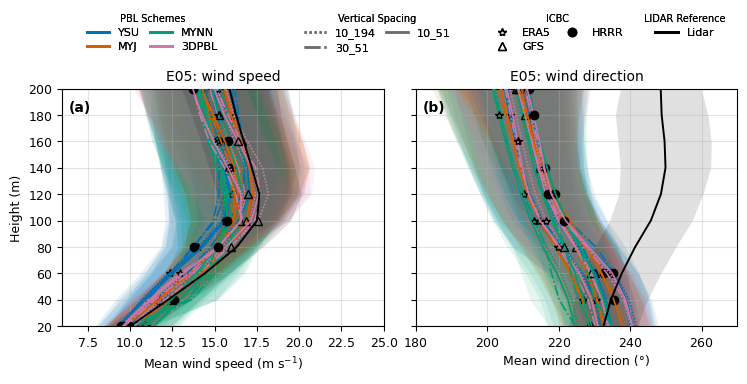

Saved: mean_ws_wd_profiles_E05.pdf


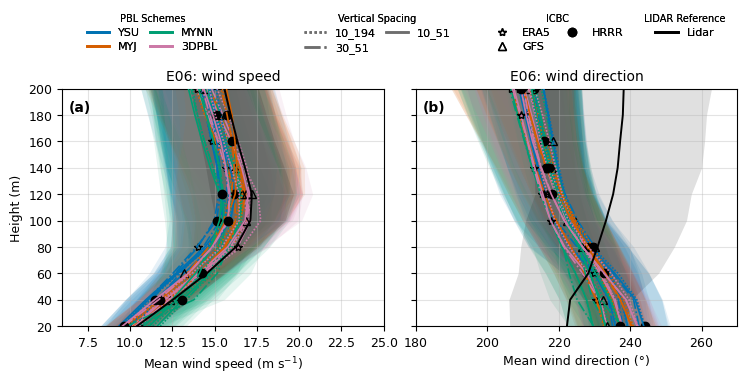

Saved: mean_ws_wd_profiles_E06.pdf


In [44]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------ inputs ------------------
WS_D02_ROOT      = "/glade/work/mhafsah/Analysis_Proj_1/WS_d02"
WS_ALLRUNS_ROOT  = "/glade/work/mhafsah/Analysis_Proj_1/WS_all_runs"   # only 3dpbl runs

WD_D02_ROOT      = "/glade/work/mhafsah/Analysis_Proj_1/WD_d02"
WD_ALLRUNS_ROOT  = "/glade/work/mhafsah/Analysis_Proj_1/WD_all_runs"   # only 3dpbl runs

CWD = os.getcwd()

# Heights
z_WRF = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
z_OBS = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# ------------------ load OBS ------------------
WS_E05_OBS = np.load(os.path.join(CWD, "WS_E05_OBS.npy"))
WS_E06_OBS = np.load(os.path.join(CWD, "WS_E06_OBS.npy"))

WD_E05_OBS = np.load(os.path.join(CWD, "WD_E05_OBS.npy"))
WD_E06_OBS = np.load(os.path.join(CWD, "WD_E06_OBS.npy"))

# ------------------ Copernicus styling ------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (7.5, 3.6)

def panel_label(ax, txt):
    ax.text(
        0.02, 0.95, txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10, fontweight="bold"
    )

# ------------------ style mappings ------------------
vert_linestyle_mapping = {
    "vert54": (0, (1, 1)),  # 10_194
    "vert80": "-.",         # 30_51
    "vert93": "-",          # 10_51
}

vert_label_mapping = {
    "vert54": "10_194",
    "vert80": "30_51",
    "vert93": "10_51",
}

pbl_color_mapping = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

icbc_marker_mapping = {
    "era5": "*",
    "gfs":  "^",
    "hrrr": "o",
}

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {54: 0, 80: 1, 93: 2}

# ------------------ helpers ------------------
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def parse_parts(path, buoy="E05"):
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        raise ValueError(f"Run directory name not matched by pattern: {run_dir} (from {path})")
    g = m.groupdict()
    return g["icbc"], g["pbl"], int(g["vert"])

def collect_model_files(var_root_d02, var_root_allruns, var_prefix):
    out = []

    def scan(root, allow_pbl=None, skip_pbl=None):
        for buoy in ("E05", "E06"):
            patt = os.path.join(root, "**", f"{var_prefix}_{buoy}.npy")
            for f in glob.glob(patt, recursive=True):
                try:
                    icbc, pbl, lvl = parse_parts(f, buoy)
                except Exception:
                    continue

                if allow_pbl is not None and pbl not in allow_pbl:
                    continue
                if skip_pbl is not None and pbl in skip_pbl:
                    continue

                out.append(f)

    scan(var_root_allruns, allow_pbl={"3dpbl"})
    scan(var_root_d02,     skip_pbl={"3dpbl"})
    return out

def circular_mean_deg(a, axis=0):
    ang = np.deg2rad(a)
    s = np.nanmean(np.sin(ang), axis=axis)
    c = np.nanmean(np.cos(ang), axis=axis)
    return np.rad2deg(np.arctan2(s, c)) % 360.0

def circular_std_deg(a, axis=0):
    ang = np.deg2rad(a)
    s = np.nanmean(np.sin(ang), axis=axis)
    c = np.nanmean(np.cos(ang), axis=axis)
    R = np.sqrt(s**2 + c**2)
    R = np.clip(R, 1e-12, 1.0)
    return np.rad2deg(np.sqrt(-2.0 * np.log(R)))

def get_mean_std(arr, varname):
    if varname == "WS":
        return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)
    elif varname == "WD":
        return circular_mean_deg(arr, axis=0), circular_std_deg(arr, axis=0)
    else:
        raise ValueError(f"Unknown varname: {varname}")

def compute_ws_xlim(obs_arr, model_arrs, pad=0.5):
    vals = []
    vals.extend(obs_arr.ravel())
    for a in model_arrs:
        vals.extend(a.ravel())
    vals = np.asarray(vals, dtype=float)
    xmin = np.floor(np.nanmin(vals) - pad)
    xmax = np.ceil(np.nanmax(vals) + pad)
    return xmin, xmax

def stable_mark_index(icbc_val, pbl_val, level, buoy, varname, nlev):
    key = f"{icbc_val}_{pbl_val}_{level}_{buoy}_{varname}"
    return sum(ord(ch) for ch in key) % nlev

# ------------------ gather files ------------------
ws_model_files = collect_model_files(WS_D02_ROOT, WS_ALLRUNS_ROOT, "WS")
wd_model_files = collect_model_files(WD_D02_ROOT, WD_ALLRUNS_ROOT, "WD")

ws_file_paths_e05 = sorted([f for f in ws_model_files if os.path.basename(f) == "WS_E05.npy"])
ws_file_paths_e06 = sorted([f for f in ws_model_files if os.path.basename(f) == "WS_E06.npy"])
wd_file_paths_e05 = sorted([f for f in wd_model_files if os.path.basename(f) == "WD_E05.npy"])
wd_file_paths_e06 = sorted([f for f in wd_model_files if os.path.basename(f) == "WD_E06.npy"])

wrf_ws_e05 = [np.load(f) for f in ws_file_paths_e05]
wrf_ws_e06 = [np.load(f) for f in ws_file_paths_e06]
wrf_wd_e05 = [np.load(f) for f in wd_file_paths_e05]
wrf_wd_e06 = [np.load(f) for f in wd_file_paths_e06]

print("WS files:", len(ws_model_files), "| E05:", len(ws_file_paths_e05), "| E06:", len(ws_file_paths_e06))
print("WD files:", len(wd_model_files), "| E05:", len(wd_file_paths_e05), "| E06:", len(wd_file_paths_e06))

# ------------------ OBS stats ------------------
WS_E05_OBS_mean, WS_E05_OBS_std = get_mean_std(WS_E05_OBS, "WS")
WS_E06_OBS_mean, WS_E06_OBS_std = get_mean_std(WS_E06_OBS, "WS")
WD_E05_OBS_mean, WD_E05_OBS_std = get_mean_std(WD_E05_OBS, "WD")
WD_E06_OBS_mean, WD_E06_OBS_std = get_mean_std(WD_E06_OBS, "WD")

WS_XLIM_E05 = compute_ws_xlim(WS_E05_OBS, wrf_ws_e05, pad=0.5)
WS_XLIM_E06 = compute_ws_xlim(WS_E06_OBS, wrf_ws_e06, pad=0.5)
WD_XLIM = (180, 270)

# ------------------ plotting helper ------------------
def plot_one(ax, buoy, varname, file_paths, wrf_arrs, obs_mean, obs_std, panel_txt, xlim):
    pairs = list(zip(file_paths, wrf_arrs))
    pairs.sort(key=lambda x: (
        ICBC_ORDER.get(parse_parts(x[0], buoy)[0], 99),
        PBL_ORDER.get(parse_parts(x[0], buoy)[1], 99),
        VERT_ORDER.get(parse_parts(x[0], buoy)[2], 99),
        os.path.basename(os.path.dirname(x[0])),
    ))

    # OBS
    ax.plot(obs_mean, z_OBS, color="black", linewidth=1.4, zorder=4)
    ax.fill_betweenx(
        z_OBS, obs_mean - obs_std, obs_mean + obs_std,
        alpha=0.12, color="black", linewidth=0.0, zorder=1
    )

    # WRF
    for file_path, arr in pairs:
        icbc_val, pbl_val, level = parse_parts(file_path, buoy)
        vert_key = f"vert{level}"

        linestyle = vert_linestyle_mapping.get(vert_key, "-")
        linecolor = pbl_color_mapping.get(pbl_val, "0.5")
        marker    = icbc_marker_mapping.get(icbc_val, "o")

        arr_mean, arr_std = get_mean_std(arr, varname)
        midx = stable_mark_index(icbc_val, pbl_val, level, buoy, varname, len(z_WRF))

        mfc = "black" if icbc_val == "hrrr" else "none"

        ax.plot(
            arr_mean, z_WRF,
            linestyle=linestyle, color=linecolor, linewidth=1.2,
            marker=marker, markevery=[midx], markersize=6,
            markeredgecolor="black", markerfacecolor=mfc, markeredgewidth=1.0,
            zorder=3
        )

        ax.fill_betweenx(
            z_WRF, arr_mean - arr_std, arr_mean + arr_std,
            color=linecolor, alpha=0.10, linewidth=0.0, zorder=0
        )

    ax.set_ylim([20, 200])
    ax.set_xlim(xlim)
    ax.grid(True, alpha=0.35, linewidth=0.8)

    if varname == "WS":
        ax.set_title(f"{buoy}: wind speed")
    else:
        ax.set_title(f"{buoy}: wind direction")

    panel_label(ax, panel_txt)

# ------------------ legend helper ------------------
def add_top_legends(fig):
    pbl_handles = [
        Line2D([0], [0], color=pbl_color_mapping[p], lw=2.0, linestyle="-", label=p.upper())
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    vert_legend_color = "#6E6E6E"
    vert_handles = [
        Line2D([0], [0], color=vert_legend_color, lw=1.8,
               linestyle=vert_linestyle_mapping["vert54"], label="10_194"),
        Line2D([0], [0], color=vert_legend_color, lw=1.8,
               linestyle=vert_linestyle_mapping["vert80"], label="30_51"),
        Line2D([0], [0], color=vert_legend_color, lw=1.8,
               linestyle=vert_linestyle_mapping["vert93"], label="10_51"),
    ]

    icbc_handles = []
    for icbc in ["era5", "gfs", "hrrr"]:
        mk = icbc_marker_mapping[icbc]
        mfc = "black" if icbc == "hrrr" else "none"
        icbc_handles.append(
            Line2D(
                [0], [0], linestyle="None", color="black",
                marker=mk, markersize=6,
                markeredgecolor="black", markerfacecolor=mfc, markeredgewidth=1.0,
                label=icbc.upper()
            )
        )

    obs_handle = [
        Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Lidar")
    ]

    title_fs = 7
    label_fs = 8

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.22, 1.02),
        frameon=False,
        ncol=2,
        title="PBL Schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0,
    )

    leg2 = fig.legend(
        handles=vert_handles,
        loc="upper center",
        bbox_to_anchor=(0.52, 1.02),
        frameon=False,
        ncol=2,
        title="Vertical Spacing",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0,
    )

    leg3 = fig.legend(
        handles=icbc_handles,
        loc="upper center",
        bbox_to_anchor=(0.76, 1.02),
        frameon=False,
        ncol=2,
        title="ICBC",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0,
    )

    leg4 = fig.legend(
        handles=obs_handle,
        loc="upper center",
        bbox_to_anchor=(0.93, 1.02),
        frameon=False,
        ncol=1,
        title="LIDAR Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0,
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)
    fig.add_artist(leg4)
# ------------------ one figure per buoy ------------------
def make_buoy_figure(
    buoy,
    ws_file_paths, wd_file_paths,
    wrf_ws, wrf_wd,
    ws_obs_mean, ws_obs_std,
    wd_obs_mean, wd_obs_std,
    ws_xlim, wd_xlim,
    out_pdf
):
    fig, axs = plt.subplots(1, 2, figsize=FIGSIZE, sharey=True)
    fig.subplots_adjust(left=0.10, right=1, top=.8, bottom=0.14, wspace=0.10)

    plot_one(axs[0], buoy, "WS", ws_file_paths, wrf_ws, ws_obs_mean, ws_obs_std, "(a)", ws_xlim)
    plot_one(axs[1], buoy, "WD", wd_file_paths, wrf_wd, wd_obs_mean, wd_obs_std, "(b)", wd_xlim)

    axs[0].set_ylabel("Height (m)")
    axs[0].set_xlabel("Mean wind speed (m s$^{-1}$)")
    axs[1].set_xlabel("Mean wind direction (°)")

    add_top_legends(fig)

    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_pdf}")

# ------------------ make E05 and E06 separately ------------------
make_buoy_figure(
    buoy="E05",
    ws_file_paths=ws_file_paths_e05,
    wd_file_paths=wd_file_paths_e05,
    wrf_ws=wrf_ws_e05,
    wrf_wd=wrf_wd_e05,
    ws_obs_mean=WS_E05_OBS_mean,
    ws_obs_std=WS_E05_OBS_std,
    wd_obs_mean=WD_E05_OBS_mean,
    wd_obs_std=WD_E05_OBS_std,
    ws_xlim=WS_XLIM_E05,
    wd_xlim=WD_XLIM,
    out_pdf="mean_ws_wd_profiles_E05.pdf"
)

make_buoy_figure(
    buoy="E06",
    ws_file_paths=ws_file_paths_e06,
    wd_file_paths=wd_file_paths_e06,
    wrf_ws=wrf_ws_e06,
    wrf_wd=wrf_wd_e06,
    ws_obs_mean=WS_E06_OBS_mean,
    ws_obs_std=WS_E06_OBS_std,
    wd_obs_mean=WD_E06_OBS_mean,
    wd_obs_std=WD_E06_OBS_std,
    ws_xlim=WS_XLIM_E06,
    wd_xlim=WD_XLIM,
    out_pdf="mean_ws_wd_profiles_E06.pdf"
)

In [46]:
# ====================== WS profile panels per buoy (ERA5 / GFS / HRRR / 3DPBL) ======================
# Reads:
#   - model from WS_d02 (everything except 3dpbl) + WS_all_runs (only 3dpbl)
#   - obs from current directory (WS_E05_OBS.npy / WS_E06_OBS.npy)
# Saves:
#   profiles_ws/<buoy>/profile_ws_<category>_<buoy>.pdf/.png
#
# Marker placement (3DPBL plot): fixed at 140 m
# Vertical-resolution labels:
#   vert54 -> 10_194
#   vert80 -> 30_51
#   vert93 -> 10_51

import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
WS_D02_ROOT      = "/glade/work/mhafsah/Analysis_Proj_1/WS_d02"
WS_ALLRUNS_ROOT  = "/glade/work/mhafsah/Analysis_Proj_1/WS_all_runs"   # only 3dpbl runs
OUT_ROOT         = "profiles_ws"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# heights (10 levels)
z_WRF = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
z_OBS = z_WRF.copy()

MARKER_HEIGHT_M = 140  # marker placed here for 3DPBL ICBC markers

# ===================== Copernicus-style styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (6.85, 3.95)
DPI_PNG = 300

# ===================== Encodings =====================
# PBL colors
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# Vertical linestyles + new labels
vert_to_label = {"54": "10_194", "80": "30_51", "93": "10_51"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}
vert_legend_color = "#6E6E6E"  # gray, not black

# ICBC markers
icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}

# Sorting order
ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """
    Model file stored as:
      .../<icbc>_<pbl>_vert<NN>/WS_E05.npy
    """
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def collect_model_index():
    """
    Returns list: (path, icbc, pbl, vert, loc)
    Enforces:
      - WS_all_runs: only 3dpbl
      - WS_d02:      everything except 3dpbl
    """
    out = []

    def scan(root, allow_pbl=None, skip_pbl=None):
        for loc in LOCATIONS:
            patt = os.path.join(root, "**", f"WS_{loc}.npy")
            for f in glob.glob(patt, recursive=True):
                parsed = parse_parts_from_parent(f)
                if not parsed:
                    continue
                icbc, pbl, vert = parsed

                if allow_pbl is not None and pbl not in allow_pbl:
                    continue
                if skip_pbl is not None and pbl in skip_pbl:
                    continue

                out.append((f, icbc, pbl, vert, loc))

    scan(WS_ALLRUNS_ROOT, allow_pbl={"3dpbl"})
    scan(WS_D02_ROOT,     skip_pbl={"3dpbl"})
    return out

def load_obs_profiles(loc):
    """
    OBS from current directory: WS_E05_OBS.npy
    Returns mean/std vs height (length 10 each).
    """
    fp = os.path.join(os.getcwd(), f"WS_{loc}_OBS.npy")
    if not os.path.exists(fp):
        print(f"[{loc}] OBS file not found in CWD: {fp}")
        return None, None, None
    arr = np.load(fp)
    if arr.ndim != 2 or arr.shape[1] != 10:
        raise ValueError(f"[{loc}] Expected OBS shape (time,10); got {arr.shape} in {fp}")
    return arr, np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)

def mean_std_profile(arr_time_height):
    """arr shape (time,10) -> mean/std over time."""
    return np.nanmean(arr_time_height, axis=0), np.nanstd(arr_time_height, axis=0)

def compute_global_ws_xlim(idx, pad=0.5):
    """
    Fixed x-axis limits across all comparable WS profile plots.
    Uses all OBS + all model values across both buoys.
    """
    vals = []

    # OBS
    for loc in LOCATIONS:
        fp = os.path.join(os.getcwd(), f"WS_{loc}_OBS.npy")
        if os.path.exists(fp):
            arr = np.load(fp)
            vals.extend(arr.ravel())

    # Model
    for f, icbc, pbl, vert, loc in idx:
        arr = np.load(f)
        vals.extend(arr.ravel())

    vals = np.asarray(vals, dtype=float)
    xmin = np.floor(np.nanmin(vals) - pad)
    xmax = np.ceil(np.nanmax(vals) + pad)
    return xmin, xmax

def add_grouped_top_legends(fig, legend_mode="single_icbc"):
    """
    Top-grouped legend blocks with smaller title fonts.
    legend_mode:
      - 'single_icbc': PBL + Vert. Spacing + LIDAR
      - '3dpbl':       ICBC + Vert. Spacing + LIDAR
    """
    title_fs = 7
    label_fs = 8

    if legend_mode == "single_icbc":
        pbl_handles = [
            Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
            for p in PBLS
        ]
        vert_handles = [
            Line2D([0], [0], color=vert_legend_color, lw=1.8,
                   linestyle=vert_to_ls[v], label=vert_to_label[v])
            for v in ["54", "80", "93"]
        ]
        obs_handle = [Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Lidar")]

        leg1 = fig.legend(
            handles=pbl_handles,
            loc="upper center",
            bbox_to_anchor=(0.24, 1.02),
            frameon=False,
            ncol=2,
            title="PBL schemes",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )
        leg2 = fig.legend(
            handles=vert_handles,
            loc="upper center",
            bbox_to_anchor=(0.61, 1.02),
            frameon=False,
            ncol=2,
            title="Vertical spacing",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )
        leg3 = fig.legend(
            handles=obs_handle,
            loc="upper center",
            bbox_to_anchor=(0.90, 1.02),
            frameon=False,
            ncol=1,
            title="Reference",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )

        fig.add_artist(leg1)
        fig.add_artist(leg2)
        fig.add_artist(leg3)

    elif legend_mode == "3dpbl":
        icbc_handles = [
            Line2D([0], [0], linestyle="None", color="black",
                   marker=icbc_marker[i], markersize=6,
                   markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
                   label=i.upper())
            for i in ICBCS
        ]
        vert_handles = [
            Line2D([0], [0], color=vert_legend_color, lw=1.8,
                   linestyle=vert_to_ls[v], label=vert_to_label[v])
            for v in ["54", "80", "93"]
        ]
        obs_handle = [Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Lidar")]

        leg1 = fig.legend(
            handles=icbc_handles,
            loc="upper center",
            bbox_to_anchor=(0.22, 1.02),
            frameon=False,
            ncol=2,
            title="ICBC",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )
        leg2 = fig.legend(
            handles=vert_handles,
            loc="upper center",
            bbox_to_anchor=(0.58, 1.02),
            frameon=False,
            ncol=2,
            title="Vertical spacing",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )
        leg3 = fig.legend(
            handles=obs_handle,
            loc="upper center",
            bbox_to_anchor=(0.88, 1.02),
            frameon=False,
            ncol=1,
            title="Reference",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )

        fig.add_artist(leg1)
        fig.add_artist(leg2)
        fig.add_artist(leg3)

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z_WRF:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in z_WRF={z_WRF.tolist()}")
MARK_IDX = int(np.where(z_WRF == MARKER_HEIGHT_M)[0][0])

# ===================== Plot functions =====================
def plot_profile_single_icbc(loc, idx, icbc_fixed, xlim_fixed):
    """
    One profile figure for a buoy + ICBC:
      - lines: all PBLs × vertical levels (available)
      - color = PBL
      - linestyle = vertical level
      - no markers
      - obs = black + shaded std
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
    if not items:
        print(f"[{loc}] No model files for {icbc_fixed}.")
        return

    items.sort(key=lambda x: (
        PBL_ORDER.get(x[2], 99),
        VERT_ORDER.get(x[3], 99),
        os.path.basename(os.path.dirname(x[0]))
    ))

    obs_arr, obs_mean, obs_std = load_obs_profiles(loc)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
    fig.subplots_adjust(left=0.12, right=0.98, top=0.78, bottom=0.14)

    # OBS
    if obs_mean is not None:
        ax.plot(obs_mean, z_OBS, color="black", linewidth=1.4, zorder=4)
        ax.fill_betweenx(
            z_OBS, obs_mean - obs_std, obs_mean + obs_std,
            color="black", alpha=0.12, linewidth=0.0, zorder=1
        )

    # Model profiles
    for f, icbc, pbl, vert in items:
        arr = np.load(f)
        if arr.ndim != 2 or arr.shape[1] != 10:
            print(f"Skipping {f}: shape {arr.shape}")
            continue

        m, s = mean_std_profile(arr)
        ax.plot(
            m, z_WRF,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            zorder=3
        )
        ax.fill_betweenx(
            z_WRF, m - s, m + s,
            color=pbl_color.get(pbl, "0.5"),
            alpha=0.10, linewidth=0.0, zorder=0
        )

    ax.set_ylim([20, 200])
    ax.set_xlim(xlim_fixed)
    ax.set_xlabel("Mean wind speed (m s$^{-1}$)")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"{icbc_fixed.upper()} forcing at buoy {loc}")

    add_grouped_top_legends(fig, legend_mode="single_icbc")

    base = f"profile_ws_{icbc_fixed}_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

def plot_profile_3dpbl_all_icbc(loc, idx, xlim_fixed):
    """
    One profile figure for a buoy for 3DPBL:
      - lines: ICBC × vertical level (available)
      - color = 3dpbl color
      - linestyle = vertical level
      - marker = ICBC (black, hollow) placed at 140 m
      - obs = black + shaded std
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
    if not items:
        print(f"[{loc}] No 3DPBL model files.")
        return

    items.sort(key=lambda x: (
        ICBC_ORDER.get(x[1], 99),
        VERT_ORDER.get(x[3], 99),
        os.path.basename(os.path.dirname(x[0]))
    ))

    obs_arr, obs_mean, obs_std = load_obs_profiles(loc)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
    fig.subplots_adjust(left=0.12, right=0.98, top=0.78, bottom=0.14)

    # OBS
    if obs_mean is not None:
        ax.plot(obs_mean, z_OBS, color="black", linewidth=1.4, zorder=4)
        ax.fill_betweenx(
            z_OBS, obs_mean - obs_std, obs_mean + obs_std,
            color="black", alpha=0.12, linewidth=0.0, zorder=1
        )

    # Model 3dpbl profiles with markers for ICBC (fixed at 140 m)
    for f, icbc, pbl, vert in items:
        arr = np.load(f)
        if arr.ndim != 2 or arr.shape[1] != 10:
            print(f"Skipping {f}: shape {arr.shape}")
            continue

        m, s = mean_std_profile(arr)

        ax.plot(
            m, z_WRF,
            color=pbl_color["3dpbl"],
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            marker=icbc_marker.get(icbc, "o"),
            markevery=[MARK_IDX],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
            zorder=3
        )
        ax.fill_betweenx(
            z_WRF, m - s, m + s,
            color=pbl_color["3dpbl"], alpha=0.10, linewidth=0.0, zorder=0
        )

    ax.set_ylim([20, 200])
    ax.set_xlim(xlim_fixed)
    ax.set_xlabel("Mean wind speed (m s$^{-1}$)")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"3DPBL at buoy {loc}")

    add_grouped_top_legends(fig, legend_mode="3dpbl")

    base = f"profile_ws_3dpbl_allICBC_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_model_index()
    print("Indexed model files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    # fixed x-axis limits across this full batch of comparable WS profile plots
    WS_XLIM = compute_global_ws_xlim(idx, pad=0.5)
    print("Using fixed WS x-limits for all panels:", WS_XLIM)

    for loc in LOCATIONS:
        plot_profile_single_icbc(loc, idx, "era5", WS_XLIM)
        plot_profile_single_icbc(loc, idx, "gfs",  WS_XLIM)
        plot_profile_single_icbc(loc, idx, "hrrr", WS_XLIM)
        plot_profile_3dpbl_all_icbc(loc, idx, WS_XLIM)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed model files: 72
Using fixed WS x-limits for all panels: (6.0, 25.0)
Saved: profiles_ws/E05/profile_ws_era5_E05.[pdf/png]
Saved: profiles_ws/E05/profile_ws_gfs_E05.[pdf/png]
Saved: profiles_ws/E05/profile_ws_hrrr_E05.[pdf/png]
Saved: profiles_ws/E05/profile_ws_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_ws/E06/profile_ws_era5_E06.[pdf/png]
Saved: profiles_ws/E06/profile_ws_gfs_E06.[pdf/png]
Saved: profiles_ws/E06/profile_ws_hrrr_E06.[pdf/png]
Saved: profiles_ws/E06/profile_ws_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_ws/E05 and profiles_ws/E06


In [47]:
# ====================== WD profile panels per buoy (ERA5 / GFS / HRRR / 3DPBL) ======================
# Reads:
#   - model from WD_d02 (everything except 3dpbl) + WD_all_runs (only 3dpbl)
#   - obs from current directory (WD_E05_OBS.npy / WD_E06_OBS.npy)
# Saves:
#   profiles_wd/<buoy>/profile_wd_<category>_<buoy>.pdf/.png
#
# Marker placement (3DPBL plot): fixed at 140 m
# Vertical-resolution labels:
#   vert54 -> 10_194
#   vert80 -> 30_51
#   vert93 -> 10_51

import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
WD_D02_ROOT      = "/glade/work/mhafsah/Analysis_Proj_1/WD_d02"
WD_ALLRUNS_ROOT  = "/glade/work/mhafsah/Analysis_Proj_1/WD_all_runs"   # only 3dpbl runs
OUT_ROOT         = "profiles_wd"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# heights (10 levels)
z_WRF = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
z_OBS = z_WRF.copy()

MARKER_HEIGHT_M = 140  # marker placed here for 3DPBL ICBC markers

# fixed WD x-axis limits
WD_XLIM = (180, 270)

# ===================== Copernicus-style styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (6.85, 3.95)
DPI_PNG = 300

# ===================== Encodings =====================
# PBL colors
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# Vertical linestyles + new labels
vert_to_label = {"54": "10_194", "80": "30_51", "93": "10_51"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}
vert_legend_color = "#6E6E6E"  # gray, not black

# ICBC markers
icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}

# Sorting order
ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """
    Model file stored as:
      .../<icbc>_<pbl>_vert<NN>/WD_E05.npy
    """
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def collect_model_index():
    """
    Returns list: (path, icbc, pbl, vert, loc)
    Enforces:
      - WD_all_runs: only 3dpbl
      - WD_d02:      everything except 3dpbl
    """
    out = []

    def scan(root, allow_pbl=None, skip_pbl=None):
        for loc in LOCATIONS:
            patt = os.path.join(root, "**", f"WD_{loc}.npy")
            for f in glob.glob(patt, recursive=True):
                parsed = parse_parts_from_parent(f)
                if not parsed:
                    continue
                icbc, pbl, vert = parsed

                if allow_pbl is not None and pbl not in allow_pbl:
                    continue
                if skip_pbl is not None and pbl in skip_pbl:
                    continue

                out.append((f, icbc, pbl, vert, loc))

    scan(WD_ALLRUNS_ROOT, allow_pbl={"3dpbl"})
    scan(WD_D02_ROOT,     skip_pbl={"3dpbl"})
    return out

def load_obs_profiles(loc):
    """
    OBS from current directory: WD_E05_OBS.npy
    Returns mean/std vs height (length 10 each).
    """
    fp = os.path.join(os.getcwd(), f"WD_{loc}_OBS.npy")
    if not os.path.exists(fp):
        print(f"[{loc}] OBS file not found in CWD: {fp}")
        return None, None, None
    arr = np.load(fp)
    if arr.ndim != 2 or arr.shape[1] != 10:
        raise ValueError(f"[{loc}] Expected OBS shape (time,10); got {arr.shape} in {fp}")
    return arr, np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)

def mean_std_profile(arr_time_height):
    """arr shape (time,10) -> mean/std over time."""
    return np.nanmean(arr_time_height, axis=0), np.nanstd(arr_time_height, axis=0)

def add_grouped_top_legends(fig, legend_mode="single_icbc"):
    """
    Top-grouped legend blocks with smaller title fonts.
    legend_mode:
      - 'single_icbc': PBL + Vert. Spacing + LIDAR
      - '3dpbl':       ICBC + Vert. Spacing + LIDAR
    """
    title_fs = 7
    label_fs = 8

    if legend_mode == "single_icbc":
        pbl_handles = [
            Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
            for p in PBLS
        ]
        vert_handles = [
            Line2D([0], [0], color=vert_legend_color, lw=1.8,
                   linestyle=vert_to_ls[v], label=vert_to_label[v])
            for v in ["54", "80", "93"]
        ]
        obs_handle = [Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Lidar")]

        leg1 = fig.legend(
            handles=pbl_handles,
            loc="upper center",
            bbox_to_anchor=(0.24, 1.02),
            frameon=False,
            ncol=2,
            title="PBL schemes",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )
        leg2 = fig.legend(
            handles=vert_handles,
            loc="upper center",
            bbox_to_anchor=(0.61, 1.02),
            frameon=False,
            ncol=2,
            title="Vertical spacing",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )
        leg3 = fig.legend(
            handles=obs_handle,
            loc="upper center",
            bbox_to_anchor=(0.90, 1.02),
            frameon=False,
            ncol=1,
            title="Reference",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )

        fig.add_artist(leg1)
        fig.add_artist(leg2)
        fig.add_artist(leg3)

    elif legend_mode == "3dpbl":
        icbc_handles = [
            Line2D([0], [0], linestyle="None", color="black",
                   marker=icbc_marker[i], markersize=6,
                   markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
                   label=i.upper())
            for i in ICBCS
        ]
        vert_handles = [
            Line2D([0], [0], color=vert_legend_color, lw=1.8,
                   linestyle=vert_to_ls[v], label=vert_to_label[v])
            for v in ["54", "80", "93"]
        ]
        obs_handle = [Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Lidar")]

        leg1 = fig.legend(
            handles=icbc_handles,
            loc="upper center",
            bbox_to_anchor=(0.22, 1.02),
            frameon=False,
            ncol=2,
            title="ICBC",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )
        leg2 = fig.legend(
            handles=vert_handles,
            loc="upper center",
            bbox_to_anchor=(0.58, 1.02),
            frameon=False,
            ncol=2,
            title="Vertical spacing",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )
        leg3 = fig.legend(
            handles=obs_handle,
            loc="upper center",
            bbox_to_anchor=(0.88, 1.02),
            frameon=False,
            ncol=1,
            title="Reference",
            title_fontsize=title_fs,
            fontsize=label_fs,
            handlelength=2.0,
            columnspacing=0.9,
            labelspacing=0.35,
            borderaxespad=0.0,
        )

        fig.add_artist(leg1)
        fig.add_artist(leg2)
        fig.add_artist(leg3)

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z_WRF:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in z_WRF={z_WRF.tolist()}")
MARK_IDX = int(np.where(z_WRF == MARKER_HEIGHT_M)[0][0])

# ===================== Plot functions =====================
def plot_profile_single_icbc(loc, idx, icbc_fixed):
    """
    One profile figure for a buoy + ICBC:
      - lines: all PBLs × vertical levels (available)
      - color = PBL
      - linestyle = vertical level
      - no markers
      - obs = black + shaded std
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
    if not items:
        print(f"[{loc}] No model files for {icbc_fixed}.")
        return

    items.sort(key=lambda x: (
        PBL_ORDER.get(x[2], 99),
        VERT_ORDER.get(x[3], 99),
        os.path.basename(os.path.dirname(x[0]))
    ))

    obs_arr, obs_mean, obs_std = load_obs_profiles(loc)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
    fig.subplots_adjust(left=0.12, right=0.98, top=0.78, bottom=0.14)

    # OBS
    if obs_mean is not None:
        ax.plot(obs_mean, z_OBS, color="black", linewidth=1.4, zorder=4)
        ax.fill_betweenx(
            z_OBS, obs_mean - obs_std, obs_mean + obs_std,
            color="black", alpha=0.12, linewidth=0.0, zorder=1
        )

    # Model profiles
    for f, icbc, pbl, vert in items:
        arr = np.load(f)
        if arr.ndim != 2 or arr.shape[1] != 10:
            print(f"Skipping {f}: shape {arr.shape}")
            continue

        m, s = mean_std_profile(arr)
        ax.plot(
            m, z_WRF,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            zorder=3
        )
        ax.fill_betweenx(
            z_WRF, m - s, m + s,
            color=pbl_color.get(pbl, "0.5"),
            alpha=0.10, linewidth=0.0, zorder=0
        )

    ax.set_ylim([20, 200])
    ax.set_xlim(WD_XLIM)
    ax.set_xlabel("Mean wind direction (°)")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"{icbc_fixed.upper()} forcing at buoy {loc}")

    add_grouped_top_legends(fig, legend_mode="single_icbc")

    base = f"profile_wd_{icbc_fixed}_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

def plot_profile_3dpbl_all_icbc(loc, idx):
    """
    One profile figure for a buoy for 3DPBL:
      - lines: ICBC × vertical level (available)
      - color = 3dpbl color
      - linestyle = vertical level
      - marker = ICBC (black, hollow) placed at 140 m
      - obs = black + shaded std
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
    if not items:
        print(f"[{loc}] No 3DPBL model files.")
        return

    items.sort(key=lambda x: (
        ICBC_ORDER.get(x[1], 99),
        VERT_ORDER.get(x[3], 99),
        os.path.basename(os.path.dirname(x[0]))
    ))

    obs_arr, obs_mean, obs_std = load_obs_profiles(loc)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
    fig.subplots_adjust(left=0.12, right=0.98, top=0.78, bottom=0.14)

    # OBS
    if obs_mean is not None:
        ax.plot(obs_mean, z_OBS, color="black", linewidth=1.4, zorder=4)
        ax.fill_betweenx(
            z_OBS, obs_mean - obs_std, obs_mean + obs_std,
            color="black", alpha=0.12, linewidth=0.0, zorder=1
        )

    # Model 3dpbl profiles with markers for ICBC (fixed at 140 m)
    for f, icbc, pbl, vert in items:
        arr = np.load(f)
        if arr.ndim != 2 or arr.shape[1] != 10:
            print(f"Skipping {f}: shape {arr.shape}")
            continue

        m, s = mean_std_profile(arr)

        ax.plot(
            m, z_WRF,
            color=pbl_color["3dpbl"],
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            marker=icbc_marker.get(icbc, "o"),
            markevery=[MARK_IDX],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
            zorder=3
        )
        ax.fill_betweenx(
            z_WRF, m - s, m + s,
            color=pbl_color["3dpbl"], alpha=0.10, linewidth=0.0, zorder=0
        )

    ax.set_ylim([20, 200])
    ax.set_xlim(WD_XLIM)
    ax.set_xlabel("Mean wind direction (°)")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"3DPBL at buoy {loc}")

    add_grouped_top_legends(fig, legend_mode="3dpbl")

    base = f"profile_wd_3dpbl_allICBC_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_model_index()
    print("Indexed model files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    print("Using fixed WD x-limits for all panels:", WD_XLIM)

    for loc in LOCATIONS:
        plot_profile_single_icbc(loc, idx, "era5")
        plot_profile_single_icbc(loc, idx, "gfs")
        plot_profile_single_icbc(loc, idx, "hrrr")
        plot_profile_3dpbl_all_icbc(loc, idx)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed model files: 72
Using fixed WD x-limits for all panels: (180, 270)
Saved: profiles_wd/E05/profile_wd_era5_E05.[pdf/png]
Saved: profiles_wd/E05/profile_wd_gfs_E05.[pdf/png]
Saved: profiles_wd/E05/profile_wd_hrrr_E05.[pdf/png]
Saved: profiles_wd/E05/profile_wd_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_wd/E06/profile_wd_era5_E06.[pdf/png]
Saved: profiles_wd/E06/profile_wd_gfs_E06.[pdf/png]
Saved: profiles_wd/E06/profile_wd_hrrr_E06.[pdf/png]
Saved: profiles_wd/E06/profile_wd_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_wd/E05 and profiles_wd/E06


In [27]:
# # ######## It is for bias single plots, so making it commented out. 2x2 panel is done in the next cell. Use this one (with updated legend and axis) if single panel is requested)
# # import os, glob, re
# import os, glob, re
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# # ===================== USER SETTINGS =====================
# ERROR_ROOT       = "errors_bias_ws"         # <-- folder in CURRENT directory
# OUT_ROOT         = "profiles_bias_ws"       # <-- output folder

# LOCATIONS = ["E05", "E06"]
# ICBCS     = ["era5", "gfs", "hrrr"]
# PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# MARKER_HEIGHT_M = 140

# # ===================== Styling =====================
# plt.rcParams.update({
#     "font.family": "DejaVu Sans",
#     "mathtext.fontset": "dejavusans",
#     "font.size": 10,
#     "axes.titlesize": 10,
#     "axes.labelsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
#     "legend.fontsize": 9,
# })

# FIGSIZE = (6.85, 5.2)
# DPI_PNG = 300

# # ===================== Encodings =====================
# pbl_color = {
#     "ysu":   "#0072B2",
#     "myj":   "#D55E00",
#     "mynn":  "#009E73",
#     "3dpbl": "#C2185B",
# }

# vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
# vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}

# icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

# ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
# PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
# VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# # ===================== Helpers =====================
# run_dir_pat = re.compile(
#     r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
# )

# def ensure_outdir(loc):
#     outdir = os.path.join(OUT_ROOT, loc)
#     os.makedirs(outdir, exist_ok=True)
#     return outdir

# def parse_parts_from_parent(path):
#     """Parent dir like: era5_ysu_vert80"""
#     run_dir = os.path.basename(os.path.dirname(path))
#     m = run_dir_pat.match(run_dir)
#     if not m:
#         return None
#     g = m.groupdict()
#     return g["icbc"], g["pbl"], g["vert"]

# def load_profile(path):
#     """
#     Accepts:
#       - (10,) already a vertical profile
#       - (time,10) -> mean over time -> (10,)
#     """
#     arr = np.load(path)
#     if arr.ndim == 1:
#         return arr
#     if arr.ndim == 2 and arr.shape[1] == 10:
#         return np.nanmean(arr, axis=0)
#     raise ValueError(f"Unexpected shape {arr.shape} in {path}")

# def collect_bias_index():
#     """
#     Looks for bias files under errors_bias_ws recursively.
#     Supports common names like:
#       bias_E05.npy, BIAS_E05.npy, ws_bias_E05.npy, etc.
#     """
#     root = os.path.join(os.getcwd(), ERROR_ROOT)
#     if not os.path.isdir(root):
#         raise FileNotFoundError(f"Folder not found: {root}")

#     out = []
#     for loc in LOCATIONS:
#         # anything with 'bias' and the buoy name in the filename
#         patt = os.path.join(root, "**", f"*{loc}*.npy")
#         for f in glob.glob(patt, recursive=True):
#             base = os.path.basename(f).lower()
#             if "bias" not in base:
#                 continue

#             parsed = parse_parts_from_parent(f)
#             if not parsed:
#                 continue
#             icbc, pbl, vert = parsed
#             out.append((f, icbc, pbl, vert, loc))

#     return out

# # fixed marker index at 140 m
# if MARKER_HEIGHT_M not in z:
#     raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
# MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# # ===================== Plot functions =====================
# def plot_bias_single_icbc(loc, idx, icbc_fixed):
#     """
#     One figure per buoy per ICBC:
#       - bias profile: x=bias, y=height
#       - lines: all PBLs × vertical levels (available)
#       - color=PBL, linestyle=vert
#       - ideal line: x=0 (black)
#     """
#     outdir = ensure_outdir(loc)

#     items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
#     if not items:
#         print(f"[{loc}] No bias files for {icbc_fixed}.")
#         return

#     items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

#     fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

#     # Ideal line (bias=0)
#     ax.axvline(0.0, color="black", linewidth=1.2)

#     for f, icbc, pbl, vert in items:
#         prof = load_profile(f)
#         if prof.shape[0] != 10:
#             print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
#             continue

#         ax.plot(
#             prof, z,
#             color=pbl_color.get(pbl, "0.5"),
#             linestyle=vert_to_ls.get(vert, "-"),
#             linewidth=1.2
#         )

#     ax.set_ylim([20, 200])
#     ax.set_xlabel("Bias (m s$^{-1}$)")
#     ax.set_ylabel("Height (m)")
#     ax.grid(True, alpha=0.35, linewidth=0.8)
#     ax.set_title(f"Wind Speed bias profiles with {icbc_fixed.upper()} Buoy {loc}", loc="center")

#     # Legend (PBL + vert + ideal)
#     pbl_handles = [Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper()) for p in PBLS]
#     vert_handles = [Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
#                     for v in ["54", "80", "93"] if v in vert_to_ls]
#     ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

#     ax.legend(handles=pbl_handles + vert_handles + ideal_handle,
#               loc="upper left", frameon=False, ncol=2,
#               handlelength=2.4, columnspacing=1.2, labelspacing=0.5)

#     base = f"bias_ws_{icbc_fixed}_{loc}"
#     fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
#     fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
#     plt.close(fig)
#     print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# def plot_bias_3dpbl_all_icbc(loc, idx):
#     """
#     One figure per buoy for 3DPBL:
#       - lines: ICBC × vertical levels (available)
#       - color=3dpbl
#       - linestyle=vert
#       - marker=ICBC (black hollow) fixed at 140 m
#       - ideal line: x=0
#     """
#     outdir = ensure_outdir(loc)

#     items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
#     if not items:
#         print(f"[{loc}] No 3DPBL bias files.")
#         return

#     items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

#     fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

#     ax.axvline(0.0, color="black", linewidth=1.2)

#     for f, icbc, pbl, vert in items:
#         prof = load_profile(f)
#         if prof.shape[0] != 10:
#             print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
#             continue

#         ax.plot(
#             prof, z,
#             color=pbl_color["3dpbl"],
#             linestyle=vert_to_ls.get(vert, "-"),
#             linewidth=1.2,
#             marker=icbc_marker.get(icbc, "o"),
#             markevery=[MARK_IDX],
#             markersize=6,
#             markeredgecolor="black",
#             markerfacecolor="none",
#             markeredgewidth=1.0,
#         )

#     ax.set_ylim([20, 200])
#     ax.set_xlabel("Bias (m s$^{-1}$)")
#     ax.set_ylabel("Height (m)")
#     ax.grid(True, alpha=0.35, linewidth=0.8)
#     ax.set_title(f"Wind Speed Bias profiles with 3DPBL at Buoy {loc}", loc="center")

#     icbc_handles = [
#         Line2D([0], [0], linestyle="None", color="black",
#                marker=icbc_marker[i], markersize=7,
#                markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
#                label=i.upper())
#         for i in ICBCS
#     ]
#     vert_handles = [Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
#                     for v in ["54", "80", "93"] if v in vert_to_ls]
#     ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal Bias")]

#     ax.legend(handles=icbc_handles + ideal_handle + vert_handles,
#               loc="upper left", frameon=False, ncol=2,
#               handlelength=2.2, columnspacing=1.2, labelspacing=0.5)

#     base = f"bias_ws_3dpbl_allICBC_{loc}"
#     fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
#     fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
#     plt.close(fig)
#     print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# # ===================== RUN =====================
# if __name__ == "__main__":
#     idx = collect_bias_index()
#     print("Indexed bias files:", len(idx))
#     os.makedirs(OUT_ROOT, exist_ok=True)

#     for loc in LOCATIONS:
#         plot_bias_single_icbc(loc, idx, "era5")
#         plot_bias_single_icbc(loc, idx, "gfs")
#         plot_bias_single_icbc(loc, idx, "hrrr")
#         plot_bias_3dpbl_all_icbc(loc, idx)

#     print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed bias files: 72
Saved: profiles_bias_ws/E05/bias_ws_era5_E05.[pdf/png]
Saved: profiles_bias_ws/E05/bias_ws_gfs_E05.[pdf/png]
Saved: profiles_bias_ws/E05/bias_ws_hrrr_E05.[pdf/png]
Saved: profiles_bias_ws/E05/bias_ws_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_bias_ws/E06/bias_ws_era5_E06.[pdf/png]
Saved: profiles_bias_ws/E06/bias_ws_gfs_E06.[pdf/png]
Saved: profiles_bias_ws/E06/bias_ws_hrrr_E06.[pdf/png]
Saved: profiles_bias_ws/E06/bias_ws_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_bias_ws/E05 and profiles_bias_ws/E06


Indexed bias files: 72
Using fixed bias x-limits: (-2.7, 1.5)


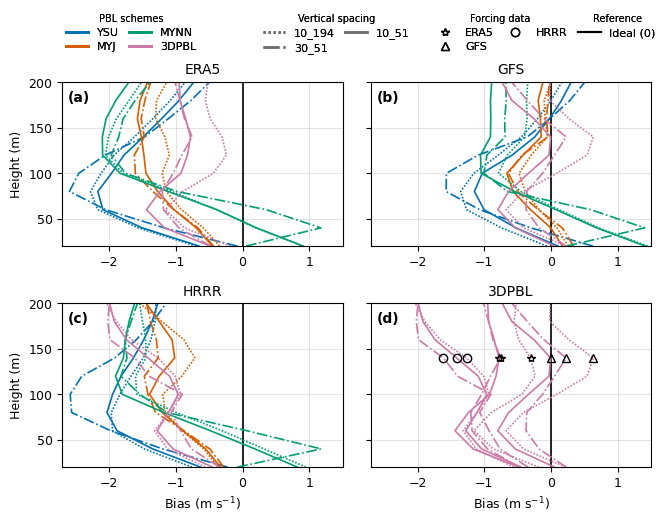

Saved: profiles_bias_ws/E05/bias_ws_2x2_E05.[pdf/png]


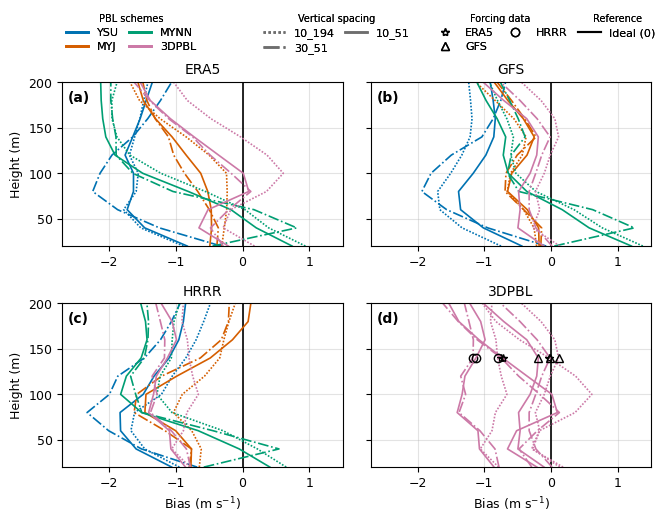

Saved: profiles_bias_ws/E06/bias_ws_2x2_E06.[pdf/png]
Done. Outputs in: profiles_bias_ws/E05 and profiles_bias_ws/E06


In [104]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT       = "errors_bias_ws"         # <-- folder in CURRENT directory
OUT_ROOT         = "profiles_bias_ws"       # <-- output folder

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
MARKER_HEIGHT_M = 140

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (6.85, 5.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# --- NEW vertical-resolution nomenclature ---
vert_to_label = {"54": "10_194", "80": "30_51", "93": "10_51"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}
vert_legend_color = "#6E6E6E"  # gray, not black

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """Parent dir like: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def load_profile(path):
    """
    Accepts:
      - (10,) already a vertical profile
      - (time,10) -> mean over time -> (10,)
    """
    arr = np.load(path)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)
    raise ValueError(f"Unexpected shape {arr.shape} in {path}")

def collect_bias_index():
    """
    Looks for bias files under errors_bias_ws recursively.
    Supports common names like:
      bias_E05.npy, BIAS_E05.npy, ws_bias_E05.npy, etc.
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")

    out = []
    for loc in LOCATIONS:
        patt = os.path.join(root, "**", f"*{loc}*.npy")
        for f in glob.glob(patt, recursive=True):
            base = os.path.basename(f).lower()
            if "bias" not in base:
                continue

            parsed = parse_parts_from_parent(f)
            if not parsed:
                continue
            icbc, pbl, vert = parsed
            out.append((f, icbc, pbl, vert, loc))

    return out

def compute_global_xlims(idx, pad=0.05):
    """
    Fixed x-axis limits across all comparable bias panels (both buoys, all configs).
    """
    vals = []
    for f, icbc, pbl, vert, loc in idx:
        try:
            prof = load_profile(f)
        except Exception:
            continue
        vals.extend(prof.ravel())
    vals = np.asarray(vals, dtype=float)
    xmin = np.nanmin(vals) - pad
    xmax = np.nanmax(vals) + pad
    xmin = np.floor(xmin*10)/10
    xmax = np.ceil(xmax*10)/10
    return (xmin, xmax)

def panel_label(ax, txt):
    ax.text(0.02, 0.95, txt, transform=ax.transAxes,
            ha="left", va="top", fontsize=10, fontweight="bold")

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

def add_grouped_top_legends(fig):
    """
    Top grouped legend blocks (PBL schemes, Vertical spacing, ICBC, Reference).
    Titles smaller; vertical-spacing lines gray; ideal line black.
    """
    title_fs = 7
    label_fs = 8

    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    vert_handles = [
        Line2D([0], [0], color=vert_legend_color, lw=1.8,
               linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ["54", "80", "93"]
    ]

    icbc_handles = [
        Line2D([0], [0], linestyle="None", color="black",
               marker=icbc_marker[i], markersize=6,
               markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
               label=i.upper())
        for i in ["era5", "gfs", "hrrr"]
    ]

    ref_handles = [
        Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")
    ]

    leg1 = fig.legend(
        handles=pbl_handles, loc="upper center", bbox_to_anchor=(0.22, 1.02),
        frameon=False, ncol=2, title="PBL schemes",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg2 = fig.legend(
        handles=vert_handles, loc="upper center", bbox_to_anchor=(0.52, 1.02),
        frameon=False, ncol=2, title="Vertical spacing",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg3 = fig.legend(
        handles=icbc_handles, loc="upper center", bbox_to_anchor=(0.76, 1.02),
        frameon=False, ncol=2, title="Forcing data",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg4 = fig.legend(
        handles=ref_handles, loc="upper center", bbox_to_anchor=(0.93, 1.02),
        frameon=False, ncol=1, title="Reference",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)
    fig.add_artist(leg4)

# ===================== Panel plotters =====================
def plot_panel_single_icbc(ax, loc, idx, icbc_fixed, xlim, panel_txt):
    """
    Panel for ERA5/GFS/HRRR:
      - lines: all PBLs × vertical levels
      - color=PBL, linestyle=vert
    """
    items = [(f, icbc, pbl, vert)
             for (f, icbc, pbl, vert, L) in idx
             if L == loc and icbc == icbc_fixed]

    items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99),
                              VERT_ORDER.get(x[3], 99),
                              os.path.basename(os.path.dirname(x[0]))))

    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            continue
        ax.plot(prof, z,
                color=pbl_color.get(pbl, "0.5"),
                linestyle=vert_to_ls.get(vert, "-"),
                linewidth=1.2)

    ax.set_xlim(xlim)
    ax.set_ylim([20, 200])
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"{icbc_fixed.upper()}")
    panel_label(ax, panel_txt)

def plot_panel_3dpbl(ax, loc, idx, xlim, panel_txt):
    """
    Panel for 3DPBL:
      - lines: ICBC × vert
      - color=3dpbl
      - linestyle=vert
      - marker=ICBC at 140 m
    """
    items = [(f, icbc, pbl, vert)
             for (f, icbc, pbl, vert, L) in idx
             if L == loc and pbl == "3dpbl"]

    items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99),
                              VERT_ORDER.get(x[3], 99),
                              os.path.basename(os.path.dirname(x[0]))))

    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            continue
        ax.plot(prof, z,
                color=pbl_color["3dpbl"],
                linestyle=vert_to_ls.get(vert, "-"),
                linewidth=1.2,
                marker=icbc_marker.get(icbc, "o"),
                markevery=[MARK_IDX],
                markersize=6,
                markeredgecolor="black",
                markerfacecolor="none",
                markeredgewidth=1.0)

    ax.set_xlim(xlim)
    ax.set_ylim([20, 200])
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title("3DPBL")
    panel_label(ax, panel_txt)

# ===================== 2×2 figure per buoy =====================
def plot_bias_2x2_per_buoy(loc, idx, xlim):
    outdir = ensure_outdir(loc)

    fig, axs = plt.subplots(2, 2, figsize=FIGSIZE, sharey=True)
    fig.subplots_adjust(left=0.12, right=0.98, top=0.88, bottom=0.14, wspace=0.1, hspace=0.35)

    plot_panel_single_icbc(axs[0, 0], loc, idx, "era5", xlim, "(a)")
    plot_panel_single_icbc(axs[0, 1], loc, idx, "gfs",  xlim, "(b)")
    plot_panel_single_icbc(axs[1, 0], loc, idx, "hrrr", xlim, "(c)")
    plot_panel_3dpbl      (axs[1, 1], loc, idx,        xlim, "(d)")

    axs[1, 0].set_xlabel("Bias (m s$^{-1}$)")
    axs[1, 1].set_xlabel("Bias (m s$^{-1}$)")
    axs[0, 0].set_ylabel("Height (m)")
    axs[1, 0].set_ylabel("Height (m)")

    add_grouped_top_legends(fig)

    base = f"bias_ws_2x2_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_bias_index()
    print("Indexed bias files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    # fixed x-axis limits across the whole comparable batch
    BIAS_XLIM = compute_global_xlims(idx, pad=0.05)
    print("Using fixed bias x-limits:", BIAS_XLIM)

    for loc in LOCATIONS:
        plot_bias_2x2_per_buoy(loc, idx, BIAS_XLIM)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed bias files: 72
Using fixed bias x-limits: (-2.7, 1.5)


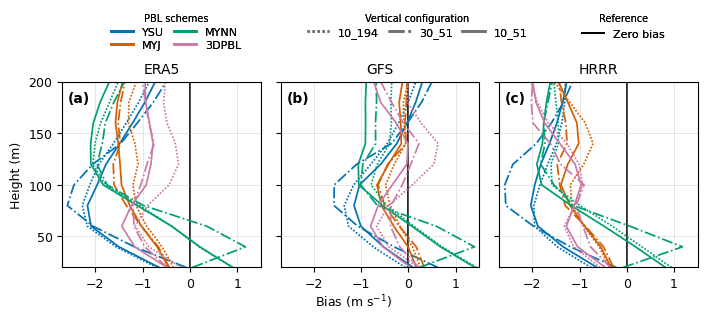

Saved: profiles_bias_ws_3panel/E05/bias_ws_3panel_E05.pdf
Saved: profiles_bias_ws_3panel/E05/bias_ws_3panel_E05.png


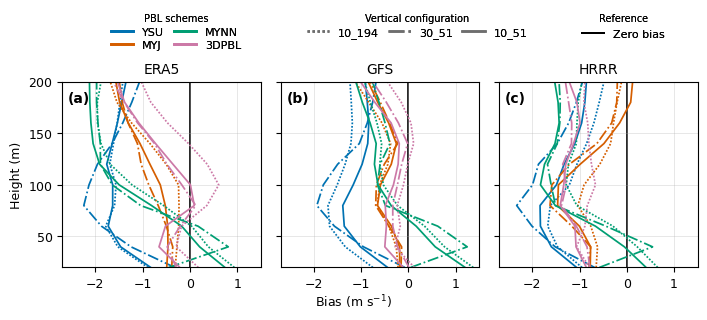

Saved: profiles_bias_ws_3panel/E06/bias_ws_3panel_E06.pdf
Saved: profiles_bias_ws_3panel/E06/bias_ws_3panel_E06.png
Done. Outputs in: profiles_bias_ws_3panel/E05 and profiles_bias_ws_3panel/E06


In [1]:
#################### 3panel Bias ##########################
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT = "errors_bias_ws"
OUT_ROOT   = "profiles_bias_ws_3panel"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Full-width, shallow 1x3 figure
FIGSIZE = (7.1, 3.15)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

vert_to_label = {
    "54": "10_194",
    "80": "30_51",
    "93": "10_51",
}

vert_to_ls = {
    "54": (0, (1, 1)),
    "80": "-.",
    "93": "-",
}

vert_legend_color = "#6E6E6E"

PBL_ORDER = {
    "ysu": 0,
    "myj": 1,
    "mynn": 2,
    "3dpbl": 3,
}

VERT_ORDER = {
    "54": 0,
    "80": 1,
    "93": 2,
}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_'
    r'(?P<pbl>ysu|myj|mynn|3dpbl)_'
    r'vert(?P<vert>54|80|93)$'
)


def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir


def parse_parts_from_parent(path):
    """
    Parent directory example:
        era5_ysu_vert80
    """
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)

    if not m:
        return None

    g = m.groupdict()

    return g["icbc"], g["pbl"], g["vert"]


def load_profile(path):
    """
    Accepts:
      - (10,)       : already a vertical profile
      - (time, 10) : mean over time -> (10,)
    """
    arr = np.load(path)

    if arr.ndim == 1:
        return arr

    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)

    raise ValueError(
        f"Unexpected shape {arr.shape} in {path}"
    )


def collect_bias_index():
    """
    Looks recursively for bias files below ERROR_ROOT.

    Supports filenames such as:
      bias_E05.npy
      BIAS_E05.npy
      ws_bias_E05.npy
      etc.
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)

    if not os.path.isdir(root):
        raise FileNotFoundError(
            f"Folder not found: {root}"
        )

    out = []

    for loc in LOCATIONS:

        patt = os.path.join(
            root,
            "**",
            f"*{loc}*.npy"
        )

        for f in glob.glob(patt, recursive=True):

            base = os.path.basename(f).lower()

            if "bias" not in base:
                continue

            parsed = parse_parts_from_parent(f)

            if not parsed:
                continue

            icbc, pbl, vert = parsed

            out.append(
                (f, icbc, pbl, vert, loc)
            )

    return out


def compute_global_xlims(idx, pad=0.05):
    """
    Use the same x-axis limits for all three forcing panels
    and both lidar locations.
    """
    vals = []

    for f, icbc, pbl, vert, loc in idx:

        try:
            prof = load_profile(f)
        except Exception:
            continue

        vals.extend(prof.ravel())

    vals = np.asarray(vals, dtype=float)

    xmin = np.nanmin(vals) - pad
    xmax = np.nanmax(vals) + pad

    xmin = np.floor(xmin * 10) / 10
    xmax = np.ceil(xmax * 10) / 10

    return xmin, xmax


def panel_label(ax, txt):
    ax.text(
        0.03,
        0.95,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )


# ===================== Legend =====================
def add_grouped_top_legends(fig):

    title_fs = 7
    label_fs = 8

    # ---------------- PBL schemes ----------------
    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=p.upper()
        )
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    # ---------------- Vertical configurations ----------------
    vert_handles = [
        Line2D(
            [0], [0],
            color=vert_legend_color,
            lw=1.8,
            linestyle=vert_to_ls[v],
            label=vert_to_label[v]
        )
        for v in ["54", "80", "93"]
    ]

    # ---------------- Reference ----------------
    ref_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=1.4,
            linestyle="-",
            label="Zero bias"
        )
    ]

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.25, 1.01),
        frameon=False,
        ncol=2,
        title="PBL schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    leg2 = fig.legend(
        handles=vert_handles,
        loc="upper center",
        bbox_to_anchor=(0.59, 1.01),
        frameon=False,
        ncol=3,
        title="Vertical configuration",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.8,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    leg3 = fig.legend(
        handles=ref_handles,
        loc="upper center",
        bbox_to_anchor=(0.88, 1.01),
        frameon=False,
        ncol=1,
        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        borderaxespad=0.0,
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)


# ===================== Panel plotting =====================
def plot_panel_single_icbc(
    ax,
    loc,
    idx,
    icbc_fixed,
    xlim,
    panel_txt,
):
    """
    One panel for one forcing dataset.

    Encoding:
      color     = PBL scheme
      linestyle = vertical configuration

    No markers are needed because forcing dataset is
    already identified by the panel title.
    """

    items = [
        (f, icbc, pbl, vert)
        for (f, icbc, pbl, vert, L) in idx
        if L == loc and icbc == icbc_fixed
    ]

    items.sort(
        key=lambda x: (
            PBL_ORDER.get(x[2], 99),
            VERT_ORDER.get(x[3], 99),
            os.path.basename(os.path.dirname(x[0])),
        )
    )

    # Zero-bias reference
    ax.axvline(
        0.0,
        color="black",
        linewidth=1.2,
        zorder=1,
    )

    for f, icbc, pbl, vert in items:

        prof = load_profile(f)

        if prof.shape[0] != len(z):
            print(
                f"Skipping {f}: expected {len(z)} heights, "
                f"got {prof.shape[0]}"
            )
            continue

        ax.plot(
            prof,
            z,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.25,
            zorder=2,
        )

    ax.set_xlim(xlim)
    ax.set_ylim(20, 200)

    ax.grid(
        True,
        alpha=0.30,
        linewidth=0.7,
    )

    ax.set_title(icbc_fixed.upper())

    panel_label(
        ax,
        panel_txt,
    )


# ===================== 1x3 figure per buoy =====================
def plot_bias_3panel_per_buoy(
    loc,
    idx,
    xlim,
):

    outdir = ensure_outdir(loc)

    fig, axs = plt.subplots(
        1,
        3,
        figsize=FIGSIZE,
        sharex=True,
        sharey=True,
    )

    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        top=0.78,
        bottom=0.19,
        wspace=0.10,
    )

    plot_panel_single_icbc(
        axs[0],
        loc,
        idx,
        "era5",
        xlim,
        "(a)",
    )

    plot_panel_single_icbc(
        axs[1],
        loc,
        idx,
        "gfs",
        xlim,
        "(b)",
    )

    plot_panel_single_icbc(
        axs[2],
        loc,
        idx,
        "hrrr",
        xlim,
        "(c)",
    )

    # Shared y-axis label only on left
    axs[0].set_ylabel(
        "Height (m)"
    )

    # Shared x-axis label
    fig.supxlabel(
        "Bias (m s$^{-1}$)",
        fontsize=9,
        y=0.055,
    )

    add_grouped_top_legends(fig)

    base = f"bias_ws_3panel_{loc}"

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        f"Saved: {pdf_path}"
    )

    print(
        f"Saved: {png_path}"
    )


# ===================== RUN =====================
if __name__ == "__main__":

    idx = collect_bias_index()

    print(
        "Indexed bias files:",
        len(idx)
    )

    os.makedirs(
        OUT_ROOT,
        exist_ok=True
    )

    # Same bias limits across E05/E06 and all forcing datasets
    BIAS_XLIM = compute_global_xlims(
        idx,
        pad=0.05,
    )

    print(
        "Using fixed bias x-limits:",
        BIAS_XLIM
    )

    for loc in LOCATIONS:

        plot_bias_3panel_per_buoy(
            loc,
            idx,
            BIAS_XLIM,
        )

    print(
        f"Done. Outputs in: "
        f"{OUT_ROOT}/E05 and "
        f"{OUT_ROOT}/E06"
    )

In [25]:
# ######## It is for cRMSE single plots, so making it commented out. 2x2 panel is done in the next cell. Use this one (with updated legend and axis) if single panel is requested)
# import os, glob, re
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# # ===================== USER SETTINGS =====================
# ERROR_ROOT       = "errors_crmse_ws"        # <-- folder in CURRENT directory
# OUT_ROOT         = "profiles_crmse_ws"      # <-- output folder

# # file names like this: CRMSE_WS_E05.npy
# LOCATIONS = ["E05", "E06"]
# ICBCS     = ["era5", "gfs", "hrrr"]
# PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# MARKER_HEIGHT_M = 140

# # ===================== Styling =====================
# plt.rcParams.update({
#     "font.family": "DejaVu Sans",
#     "mathtext.fontset": "dejavusans",
#     "font.size": 10,
#     "axes.titlesize": 10,
#     "axes.labelsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
#     "legend.fontsize": 9,
# })

# FIGSIZE = (6.85, 5.2)
# DPI_PNG = 300

# # ===================== Encodings =====================
# pbl_color = {
#     "ysu":   "#0072B2",
#     "myj":   "#D55E00",
#     "mynn":  "#009E73",
#     "3dpbl": "#C2185B",
# }

# vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
# vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}

# icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

# ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
# PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
# VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# # ===================== Helpers =====================
# run_dir_pat = re.compile(
#     r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
# )

# def ensure_outdir(loc):
#     outdir = os.path.join(OUT_ROOT, loc)
#     os.makedirs(outdir, exist_ok=True)
#     return outdir

# def parse_parts_from_parent(path):
#     """Parent dir like: era5_ysu_vert80"""
#     run_dir = os.path.basename(os.path.dirname(path))
#     m = run_dir_pat.match(run_dir)
#     if not m:
#         return None
#     g = m.groupdict()
#     return g["icbc"], g["pbl"], g["vert"]

# def load_profile(path):
#     """
#     Accepts:
#       - (10,) already a vertical profile
#       - (time,10) -> mean over time -> (10,)
#     """
#     arr = np.load(path)
#     if arr.ndim == 1:
#         return arr
#     if arr.ndim == 2 and arr.shape[1] == 10:
#         return np.nanmean(arr, axis=0)
#     raise ValueError(f"Unexpected shape {arr.shape} in {path}")

# def collect_crmse_index():
#     """
#     Looks for cRMSE files under errors_crmse_ws recursively.
#     Expects filenames like: CRMSE_WS_E05.npy
#     """
#     root = os.path.join(os.getcwd(), ERROR_ROOT)
#     if not os.path.isdir(root):
#         raise FileNotFoundError(f"Folder not found: {root}")

#     out = []
#     for loc in LOCATIONS:
#         patt = os.path.join(root, "**", f"*{loc}*.npy")
#         for f in glob.glob(patt, recursive=True):
#             base = os.path.basename(f).lower()
#             if "crmse" not in base:
#                 continue
#             if "_ws_" not in base:
#                 continue

#             parsed = parse_parts_from_parent(f)
#             if not parsed:
#                 continue
#             icbc, pbl, vert = parsed
#             out.append((f, icbc, pbl, vert, loc))

#     return out

# # fixed marker index at 140 m
# if MARKER_HEIGHT_M not in z:
#     raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
# MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# # ===================== Plot functions =====================
# def plot_crmse_single_icbc(loc, idx, icbc_fixed):
#     """
#     One figure per buoy per ICBC:
#       - cRMSE profile: x=cRMSE, y=height
#       - lines: all PBLs × vertical levels (available)
#       - color=PBL, linestyle=vert
#       - ideal line: x=0 (black)
#     """
#     outdir = ensure_outdir(loc)

#     items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
#     if not items:
#         print(f"[{loc}] No cRMSE files for {icbc_fixed}.")
#         return

#     items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

#     fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

#     # Ideal line (cRMSE=0)
#     ax.axvline(0.0, color="black", linewidth=1.2)

#     for f, icbc, pbl, vert in items:
#         prof = load_profile(f)
#         if prof.shape[0] != 10:
#             print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
#             continue

#         ax.plot(
#             prof, z,
#             color=pbl_color.get(pbl, "0.5"),
#             linestyle=vert_to_ls.get(vert, "-"),
#             linewidth=1.2
#         )

#     ax.set_ylim([20, 200])
#     ax.set_xlabel("cRMSE (m s$^{-1}$)")
#     ax.set_ylabel("Height (m)")
#     ax.grid(True, alpha=0.35, linewidth=0.8)
#     ax.set_title(f"Wind Speed cRMSE profiles with {icbc_fixed.upper()} Buoy {loc}", loc="center")

#     # Legend (PBL + vert + ideal)
#     pbl_handles = [Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper()) for p in PBLS]
#     vert_handles = [Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
#                     for v in ["54", "80", "93"] if v in vert_to_ls]
#     ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

#     ax.legend(handles=pbl_handles + vert_handles + ideal_handle,
#               loc="upper left", frameon=False, ncol=2,
#               handlelength=2.4, columnspacing=1.2, labelspacing=0.5)

#     base = f"crmse_ws_{icbc_fixed}_{loc}"
#     fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
#     fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
#     plt.close(fig)
#     print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# def plot_crmse_3dpbl_all_icbc(loc, idx):
#     """
#     One figure per buoy for 3DPBL:
#       - lines: ICBC × vertical levels (available)
#       - color=3dpbl
#       - linestyle=vert
#       - marker=ICBC (black hollow) fixed at 140 m
#       - ideal line: x=0
#     """
#     outdir = ensure_outdir(loc)

#     items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
#     if not items:
#         print(f"[{loc}] No 3DPBL cRMSE files.")
#         return

#     items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

#     fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

#     ax.axvline(0.0, color="black", linewidth=1.2)

#     for f, icbc, pbl, vert in items:
#         prof = load_profile(f)
#         if prof.shape[0] != 10:
#             print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
#             continue

#         ax.plot(
#             prof, z,
#             color=pbl_color["3dpbl"],
#             linestyle=vert_to_ls.get(vert, "-"),
#             linewidth=1.2,
#             marker=icbc_marker.get(icbc, "o"),
#             markevery=[MARK_IDX],
#             markersize=6,
#             markeredgecolor="black",
#             markerfacecolor="none",
#             markeredgewidth=1.0,
#         )

#     ax.set_ylim([20, 200])
#     ax.set_xlabel("cRMSE (m s$^{-1}$)")
#     ax.set_ylabel("Height (m)")
#     ax.grid(True, alpha=0.35, linewidth=0.8)
#     ax.set_title(f"Wind Speed cRMSE profiles with 3DPBL at Buoy {loc}", loc="center")

#     icbc_handles = [
#         Line2D([0], [0], linestyle="None", color="black",
#                marker=icbc_marker[i], markersize=7,
#                markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
#                label=i.upper())
#         for i in ICBCS
#     ]
#     vert_handles = [Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
#                     for v in ["54", "80", "93"] if v in vert_to_ls]
#     ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal cRMSE")]

#     ax.legend(handles=icbc_handles + ideal_handle + vert_handles,
#               loc="upper left", frameon=False, ncol=2,
#               handlelength=2.2, columnspacing=1.2, labelspacing=0.5)

#     base = f"crmse_ws_3dpbl_allICBC_{loc}"
#     fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
#     fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
#     plt.close(fig)
#     print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# # ===================== RUN =====================
# if __name__ == "__main__":
#     idx = collect_crmse_index()
#     print("Indexed cRMSE files:", len(idx))
#     os.makedirs(OUT_ROOT, exist_ok=True)

#     for loc in LOCATIONS:
#         plot_crmse_single_icbc(loc, idx, "era5")
#         plot_crmse_single_icbc(loc, idx, "gfs")
#         plot_crmse_single_icbc(loc, idx, "hrrr")
#         plot_crmse_3dpbl_all_icbc(loc, idx)

#     print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed cRMSE files: 72
Saved: profiles_crmse_ws/E05/crmse_ws_era5_E05.[pdf/png]
Saved: profiles_crmse_ws/E05/crmse_ws_gfs_E05.[pdf/png]
Saved: profiles_crmse_ws/E05/crmse_ws_hrrr_E05.[pdf/png]
Saved: profiles_crmse_ws/E05/crmse_ws_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_crmse_ws/E06/crmse_ws_era5_E06.[pdf/png]
Saved: profiles_crmse_ws/E06/crmse_ws_gfs_E06.[pdf/png]
Saved: profiles_crmse_ws/E06/crmse_ws_hrrr_E06.[pdf/png]
Saved: profiles_crmse_ws/E06/crmse_ws_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_crmse_ws/E05 and profiles_crmse_ws/E06


Indexed cRMSE files: 72
Using fixed cRMSE x-limits: (-0.1, 2.2)


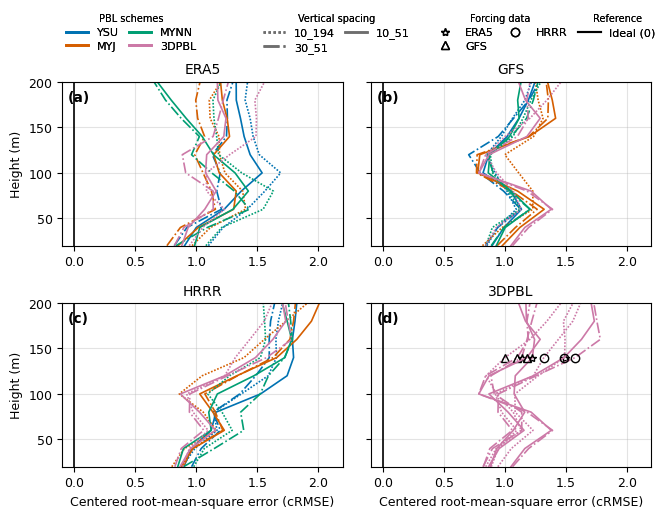

Saved: profiles_crmse_ws/E05/crmse_ws_2x2_E05.[pdf/png]


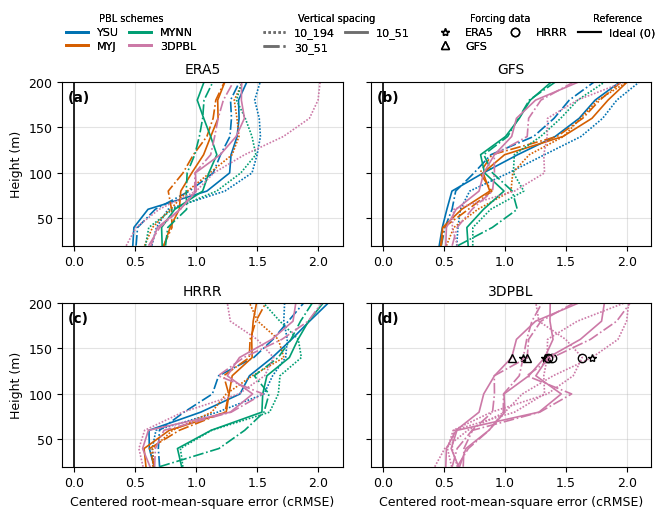

Saved: profiles_crmse_ws/E06/crmse_ws_2x2_E06.[pdf/png]
Done. Outputs in: profiles_crmse_ws/E05 and profiles_crmse_ws/E06


In [93]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT       = "errors_crmse_ws"        # <-- folder in CURRENT directory
OUT_ROOT         = "profiles_crmse_ws"      # <-- output folder

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
MARKER_HEIGHT_M = 140

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (6.85, 5.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# --- NEW vertical-resolution nomenclature ---
vert_to_label = {"54": "10_194", "80": "30_51", "93": "10_51"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}
vert_legend_color = "#6E6E6E"  # gray, not black

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black hollow in plots

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """Parent dir like: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def load_profile(path):
    """
    Accepts:
      - (10,) already a vertical profile
      - (time,10) -> mean over time -> (10,)
    """
    arr = np.load(path)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)
    raise ValueError(f"Unexpected shape {arr.shape} in {path}")

def collect_crmse_index():
    """
    Looks for cRMSE files under errors_crmse_ws recursively.
    Expects filenames like: CRMSE_WS_E05.npy (or containing crmse and _ws_)
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")

    out = []
    for loc in LOCATIONS:
        patt = os.path.join(root, "**", f"*{loc}*.npy")
        for f in glob.glob(patt, recursive=True):
            base = os.path.basename(f).lower()
            if "crmse" not in base:
                continue
            if "_ws_" not in base and "ws" not in base:
                continue

            parsed = parse_parts_from_parent(f)
            if not parsed:
                continue
            icbc, pbl, vert = parsed
            out.append((f, icbc, pbl, vert, loc))
    return out

def compute_global_xlims(idx, pad=0.05):
    """
    Fixed x-axis limits across all comparable cRMSE panels (both buoys, all configs).
    """
    vals = []
    for f, icbc, pbl, vert, loc in idx:
        try:
            prof = load_profile(f)
        except Exception:
            continue
        vals.extend(prof.ravel())
    vals = np.asarray(vals, dtype=float)
    xmin = min(-0.05, np.nanmin(vals) - pad)
    xmax = np.nanmax(vals) + pad
    # cRMSE is nonnegative typically, but keep robust:
    xmin = np.floor(xmin*10)/10
    xmax = np.ceil(xmax*10)/10
    return (xmin, xmax)

def panel_label(ax, txt):
    ax.text(0.02, 0.95, txt, transform=ax.transAxes,
            ha="left", va="top", fontsize=10, fontweight="bold")

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

def add_grouped_top_legends(fig):
    """
    Top grouped legend blocks (PBL schemes, Vertical spacing, ICBC, Reference).
    Titles smaller; vert spacing lines gray.
    """
    title_fs = 7
    label_fs = 8

    # PBL schemes (colors)
    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    # Vertical spacing (linestyles) — gray
    vert_handles = [
        Line2D([0], [0], color=vert_legend_color, lw=1.8,
               linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ["54", "80", "93"]
    ]

    # ICBC markers (black hollow)
    icbc_handles = [
        Line2D([0], [0], linestyle="None", color="black",
               marker=icbc_marker[i], markersize=6,
               markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
               label=i.upper())
        for i in ["era5", "gfs", "hrrr"]
    ]

    # Reference: Ideal line (0)
    ref_handles = [
        Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")
    ]

    leg1 = fig.legend(
        handles=pbl_handles, loc="upper center", bbox_to_anchor=(0.22, 1.02),
        frameon=False, ncol=2, title="PBL schemes",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg2 = fig.legend(
        handles=vert_handles, loc="upper center", bbox_to_anchor=(0.52, 1.02),
        frameon=False, ncol=2, title="Vertical spacing",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg3 = fig.legend(
        handles=icbc_handles, loc="upper center", bbox_to_anchor=(0.76, 1.02),
        frameon=False, ncol=2, title="Forcing data",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg4 = fig.legend(
        handles=ref_handles, loc="upper center", bbox_to_anchor=(0.93, 1.02),
        frameon=False, ncol=1, title="Reference",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)
    fig.add_artist(leg4)

# ===================== Panel plotters =====================
def plot_panel_single_icbc(ax, loc, idx, icbc_fixed, xlim, panel_txt):
    """
    Panel for ERA5/GFS/HRRR:
      - lines: all PBLs × vertical levels
      - color=PBL, linestyle=vert
    """
    items = [(f, icbc, pbl, vert)
             for (f, icbc, pbl, vert, L) in idx
             if L == loc and icbc == icbc_fixed]

    items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99),
                              VERT_ORDER.get(x[3], 99),
                              os.path.basename(os.path.dirname(x[0]))))

    ax.axvline(0.0, color="black", linewidth=1.2)
    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            continue
        ax.plot(prof, z,
                color=pbl_color.get(pbl, "0.5"),
                linestyle=vert_to_ls.get(vert, "-"),
                linewidth=1.2)

    ax.set_xlim(xlim)
    ax.set_ylim([20, 200])
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"{icbc_fixed.upper()}")
    panel_label(ax, panel_txt)

def plot_panel_3dpbl(ax, loc, idx, xlim, panel_txt):
    """
    Panel for 3DPBL:
      - lines: ICBC × vert
      - color=3dpbl
      - linestyle=vert
      - marker=ICBC at 140 m
    """
    items = [(f, icbc, pbl, vert)
             for (f, icbc, pbl, vert, L) in idx
             if L == loc and pbl == "3dpbl"]

    items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99),
                              VERT_ORDER.get(x[3], 99),
                              os.path.basename(os.path.dirname(x[0]))))

    ax.axvline(0.0, color="black", linewidth=1.2)
    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            continue
        ax.plot(prof, z,
                color=pbl_color["3dpbl"],
                linestyle=vert_to_ls.get(vert, "-"),
                linewidth=1.2,
                marker=icbc_marker.get(icbc, "o"),
                markevery=[MARK_IDX],
                markersize=6,
                markeredgecolor="black",
                markerfacecolor="none",
                markeredgewidth=1.0)

    ax.set_xlim(xlim)
    ax.set_ylim([20, 200])
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title("3DPBL")
    panel_label(ax, panel_txt)

# ===================== 2×2 figure per buoy =====================
def plot_crmse_2x2_per_buoy(loc, idx, xlim):
    outdir = ensure_outdir(loc)

    fig, axs = plt.subplots(2, 2, figsize=FIGSIZE, sharey=True)
    fig.subplots_adjust(left=0.12, right=0.98, top=0.88, bottom=0.14, wspace=0.1, hspace=0.35)

    plot_panel_single_icbc(axs[0, 0], loc, idx, "era5", xlim, "(a)")
    plot_panel_single_icbc(axs[0, 1], loc, idx, "gfs",  xlim, "(b)")
    plot_panel_single_icbc(axs[1, 0], loc, idx, "hrrr", xlim, "(c)")
    plot_panel_3dpbl      (axs[1, 1], loc, idx,        xlim, "(d)")

    axs[1, 0].set_xlabel("Centered root-mean-square error (cRMSE)")
    axs[1, 1].set_xlabel("Centered root-mean-square error (cRMSE)")
    axs[0, 0].set_ylabel("Height (m)")
    axs[1, 0].set_ylabel("Height (m)")

    # no suptitle (Copernicus); keep buoy id subtle via filename only
    add_grouped_top_legends(fig)

    base = f"crmse_ws_2x2_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    # optional PNG
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.show() 
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_crmse_index()
    print("Indexed cRMSE files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    # fixed x-axis limits across the whole comparable batch
    CRMSE_XLIM = compute_global_xlims(idx, pad=0.05)
    print("Using fixed cRMSE x-limits:", CRMSE_XLIM)

    for loc in LOCATIONS:
        plot_crmse_2x2_per_buoy(loc, idx, CRMSE_XLIM)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed cRMSE files: 72
Using fixed cRMSE x-limits: (0.0, 2.2)


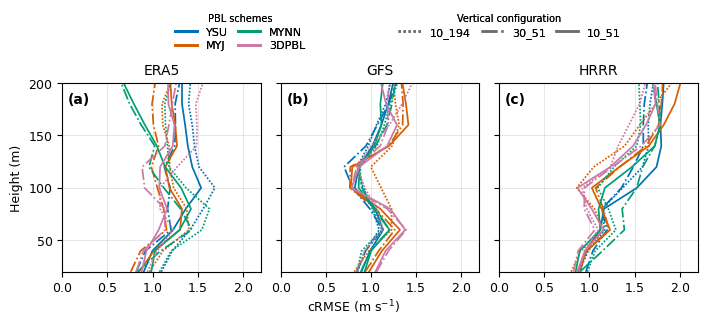

Saved: profiles_crmse_ws_3panel/E05/crmse_ws_3panel_E05.pdf
Saved: profiles_crmse_ws_3panel/E05/crmse_ws_3panel_E05.png


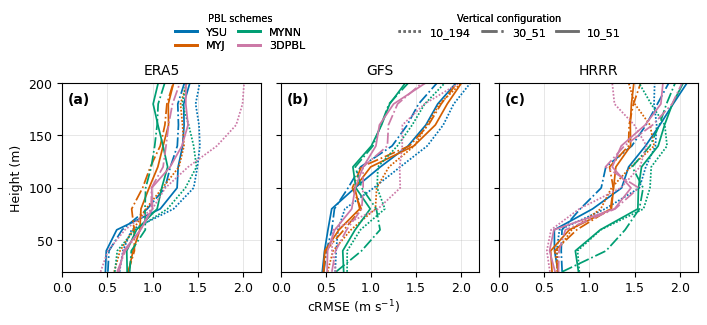

Saved: profiles_crmse_ws_3panel/E06/crmse_ws_3panel_E06.pdf
Saved: profiles_crmse_ws_3panel/E06/crmse_ws_3panel_E06.png
Done. Outputs in: profiles_crmse_ws_3panel/E05 and profiles_crmse_ws_3panel/E06


In [3]:
############################### 3 panel cRMSE

import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT = "errors_crmse_ws"
OUT_ROOT   = "profiles_crmse_ws_3panel"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Full-width 1x3 layout
FIGSIZE = (7.1, 3.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

vert_to_label = {
    "54": "10_194",
    "80": "30_51",
    "93": "10_51",
}

vert_to_ls = {
    "54": (0, (1, 1)),
    "80": "-.",
    "93": "-",
}

vert_legend_color = "#6E6E6E"

PBL_ORDER = {
    "ysu": 0,
    "myj": 1,
    "mynn": 2,
    "3dpbl": 3,
}

VERT_ORDER = {
    "54": 0,
    "80": 1,
    "93": 2,
}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_'
    r'(?P<pbl>ysu|myj|mynn|3dpbl)_'
    r'vert(?P<vert>54|80|93)$'
)


def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir


def parse_parts_from_parent(path):
    """
    Parent directory example:
        era5_ysu_vert80
    """
    run_dir = os.path.basename(os.path.dirname(path))

    m = run_dir_pat.match(run_dir)

    if not m:
        return None

    g = m.groupdict()

    return g["icbc"], g["pbl"], g["vert"]


def load_profile(path):
    """
    Accepts:
      - (10,)       : already a vertical profile
      - (time, 10) : mean over time -> (10,)
    """
    arr = np.load(path)

    if arr.ndim == 1:
        return arr

    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)

    raise ValueError(
        f"Unexpected shape {arr.shape} in {path}"
    )


def collect_crmse_index():
    """
    Recursively searches ERROR_ROOT for cRMSE wind-speed files.
    """

    root = os.path.join(
        os.getcwd(),
        ERROR_ROOT
    )

    if not os.path.isdir(root):
        raise FileNotFoundError(
            f"Folder not found: {root}"
        )

    out = []

    for loc in LOCATIONS:

        patt = os.path.join(
            root,
            "**",
            f"*{loc}*.npy"
        )

        for f in glob.glob(
            patt,
            recursive=True
        ):

            base = os.path.basename(f).lower()

            if "crmse" not in base:
                continue

            if "_ws_" not in base and "ws" not in base:
                continue

            parsed = parse_parts_from_parent(f)

            if not parsed:
                continue

            icbc, pbl, vert = parsed

            out.append(
                (f, icbc, pbl, vert, loc)
            )

    return out


def compute_global_xlims(idx, pad=0.05):
    """
    Fixed cRMSE x-axis limits across:
      - ERA5/GFS/HRRR panels
      - E05/E06

    cRMSE is nonnegative, so lower limit is fixed at 0.
    """

    vals = []

    for f, icbc, pbl, vert, loc in idx:

        try:
            prof = load_profile(f)
        except Exception:
            continue

        vals.extend(
            prof.ravel()
        )

    vals = np.asarray(
        vals,
        dtype=float
    )

    xmax = np.nanmax(vals) + pad

    # Round upward to nearest 0.1
    xmax = np.ceil(
        xmax * 10
    ) / 10

    return (0.0, xmax)


def panel_label(ax, txt):

    ax.text(
        0.03,
        0.95,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )


# ===================== Legends =====================
def add_grouped_top_legends(fig):
    """
    Only two encodings remain:

      color     = PBL scheme
      linestyle = vertical configuration

    Forcing dataset is represented by panel.
    """

    title_fs = 7
    label_fs = 8

    # ---------------- PBL schemes ----------------
    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=p.upper()
        )
        for p in [
            "ysu",
            "myj",
            "mynn",
            "3dpbl"
        ]
    ]

    # ---------------- Vertical configurations ----------------
    vert_handles = [
        Line2D(
            [0], [0],
            color=vert_legend_color,
            lw=1.8,
            linestyle=vert_to_ls[v],
            label=vert_to_label[v]
        )
        for v in [
            "54",
            "80",
            "93"
        ]
    ]

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.34, 1.01),
        frameon=False,
        ncol=2,
        title="PBL schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    leg2 = fig.legend(
        handles=vert_handles,
        loc="upper center",
        bbox_to_anchor=(0.72, 1.01),
        frameon=False,
        ncol=3,
        title="Vertical configuration",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)


# ===================== Panel plotting =====================
def plot_panel_single_icbc(
    ax,
    loc,
    idx,
    icbc_fixed,
    xlim,
    panel_txt,
):
    """
    One panel for one forcing dataset.

    Encoding:
      color     = PBL scheme
      linestyle = vertical configuration
    """

    items = [
        (f, icbc, pbl, vert)
        for (
            f,
            icbc,
            pbl,
            vert,
            L
        ) in idx
        if L == loc
        and icbc == icbc_fixed
    ]

    items.sort(
        key=lambda x: (
            PBL_ORDER.get(
                x[2],
                99
            ),
            VERT_ORDER.get(
                x[3],
                99
            ),
            os.path.basename(
                os.path.dirname(
                    x[0]
                )
            ),
        )
    )

    for f, icbc, pbl, vert in items:

        prof = load_profile(f)

        if prof.shape[0] != len(z):

            print(
                f"Skipping {f}: "
                f"expected {len(z)} heights, "
                f"got {prof.shape[0]}"
            )

            continue

        ax.plot(
            prof,
            z,
            color=pbl_color.get(
                pbl,
                "0.5"
            ),
            linestyle=vert_to_ls.get(
                vert,
                "-"
            ),
            linewidth=1.25,
        )

    ax.set_xlim(
        xlim
    )

    ax.set_ylim(
        20,
        200
    )

    ax.grid(
        True,
        alpha=0.30,
        linewidth=0.7,
    )

    ax.set_title(
        icbc_fixed.upper()
    )

    panel_label(
        ax,
        panel_txt
    )


# ===================== 1x3 figure per buoy =====================
def plot_crmse_3panel_per_buoy(
    loc,
    idx,
    xlim,
):

    outdir = ensure_outdir(
        loc
    )

    fig, axs = plt.subplots(
        1,
        3,
        figsize=FIGSIZE,
        sharex=True,
        sharey=True,
    )

    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        top=0.78,
        bottom=0.19,
        wspace=0.10,
    )

    # ---------------- ERA5 ----------------
    plot_panel_single_icbc(
        axs[0],
        loc,
        idx,
        "era5",
        xlim,
        "(a)",
    )

    # ---------------- GFS ----------------
    plot_panel_single_icbc(
        axs[1],
        loc,
        idx,
        "gfs",
        xlim,
        "(b)",
    )

    # ---------------- HRRR ----------------
    plot_panel_single_icbc(
        axs[2],
        loc,
        idx,
        "hrrr",
        xlim,
        "(c)",
    )

    # Shared y label
    axs[0].set_ylabel(
        "Height (m)"
    )

    # Shared x label
    fig.supxlabel(
        "cRMSE (m s$^{-1}$)",
        fontsize=9,
        y=0.055,
    )

    add_grouped_top_legends(
        fig
    )

    base = (
        f"crmse_ws_3panel_{loc}"
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(
        f"Saved: {pdf_path}"
    )

    print(
        f"Saved: {png_path}"
    )


# ===================== RUN =====================
if __name__ == "__main__":

    idx = collect_crmse_index()

    print(
        "Indexed cRMSE files:",
        len(idx)
    )

    os.makedirs(
        OUT_ROOT,
        exist_ok=True
    )

    # Fixed x-axis limits across all comparable plots
    CRMSE_XLIM = compute_global_xlims(
        idx,
        pad=0.05,
    )

    print(
        "Using fixed cRMSE x-limits:",
        CRMSE_XLIM
    )

    for loc in LOCATIONS:

        plot_crmse_3panel_per_buoy(
            loc,
            idx,
            CRMSE_XLIM,
        )

    print(
        f"Done. Outputs in: "
        f"{OUT_ROOT}/E05 and "
        f"{OUT_ROOT}/E06"
    )

In [29]:
# # ######## It is for r2 single plots, so making it commented out. 2x2 panel is done in the next cell. Use this one (with updated legend and axis) if single panel is requested)
# # import os, glob, re
# import os, glob, re
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# # ===================== USER SETTINGS =====================
# ERROR_ROOT       = "errors_r2_ws"           # <-- folder in CURRENT directory
# OUT_ROOT         = "profiles_r2_ws"         # <-- output folder

# # file names like this: R2_WS_E05.npy  (or r2_ws_e05.npy)
# LOCATIONS = ["E05", "E06"]
# ICBCS     = ["era5", "gfs", "hrrr"]
# PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# MARKER_HEIGHT_M = 140

# # ===================== Styling =====================
# plt.rcParams.update({
#     "font.family": "DejaVu Sans",
#     "mathtext.fontset": "dejavusans",
#     "font.size": 10,
#     "axes.titlesize": 10,
#     "axes.labelsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
#     "legend.fontsize": 9,
# })

# FIGSIZE = (6.85, 5.2)
# DPI_PNG = 300

# # ===================== Encodings =====================
# pbl_color = {
#     "ysu":   "#0072B2",
#     "myj":   "#D55E00",
#     "mynn":  "#009E73",
#     "3dpbl": "#C2185B",
# }

# vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
# vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}

# icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

# ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
# PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
# VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# # ===================== Helpers =====================
# run_dir_pat = re.compile(
#     r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
# )

# def ensure_outdir(loc):
#     outdir = os.path.join(OUT_ROOT, loc)
#     os.makedirs(outdir, exist_ok=True)
#     return outdir

# def parse_parts_from_parent(path):
#     """Parent dir like: era5_ysu_vert80"""
#     run_dir = os.path.basename(os.path.dirname(path))
#     m = run_dir_pat.match(run_dir)
#     if not m:
#         return None
#     g = m.groupdict()
#     return g["icbc"], g["pbl"], g["vert"]

# def load_profile(path):
#     """
#     Accepts:
#       - (10,) already a vertical profile
#       - (time,10) -> mean over time -> (10,)
#     """
#     arr = np.load(path)
#     if arr.ndim == 1:
#         return arr
#     if arr.ndim == 2 and arr.shape[1] == 10:
#         return np.nanmean(arr, axis=0)
#     raise ValueError(f"Unexpected shape {arr.shape} in {path}")

# def collect_r2_index():
#     """
#     Looks for R2 files under errors_r2_ws recursively.
#     Expects filenames like: R2_WS_E05.npy (case-insensitive).
#     """
#     root = os.path.join(os.getcwd(), ERROR_ROOT)
#     if not os.path.isdir(root):
#         raise FileNotFoundError(f"Folder not found: {root}")

#     out = []
#     for loc in LOCATIONS:
#         patt = os.path.join(root, "**", f"*{loc}*.npy")
#         for f in glob.glob(patt, recursive=True):
#             base = os.path.basename(f).lower()

#             # accept 'r2' anywhere (e.g., r2_ws_e05.npy)
#             if "r2" not in base:
#                 continue
#             if "_ws_" not in base:
#                 continue

#             parsed = parse_parts_from_parent(f)
#             if not parsed:
#                 continue
#             icbc, pbl, vert = parsed
#             out.append((f, icbc, pbl, vert, loc))

#     return out

# # fixed marker index at 140 m
# if MARKER_HEIGHT_M not in z:
#     raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
# MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# # ===================== Plot functions =====================
# def plot_r2_single_icbc(loc, idx, icbc_fixed):
#     """
#     One figure per buoy per ICBC:
#       - R^2 profile: x=R^2, y=height
#       - lines: all PBLs × vertical levels (available)
#       - color=PBL, linestyle=vert
#       - ideal line: x=1 (black)
#     """
#     outdir = ensure_outdir(loc)

#     items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
#     if not items:
#         print(f"[{loc}] No R2 files for {icbc_fixed}.")
#         return

#     items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

#     fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

#     # Ideal line (R^2=1)
#     ax.axvline(1.0, color="black", linewidth=1.2)

#     for f, icbc, pbl, vert in items:
#         prof = load_profile(f)
#         if prof.shape[0] != 10:
#             print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
#             continue

#         ax.plot(
#             prof, z,
#             color=pbl_color.get(pbl, "0.5"),
#             linestyle=vert_to_ls.get(vert, "-"),
#             linewidth=1.2
#         )

#     ax.set_ylim([20, 200])
#     ax.set_xlabel("R$^2$")
#     ax.set_ylabel("Height (m)")
#     ax.grid(True, alpha=0.35, linewidth=0.8)
#     ax.set_title(f"Wind Speed R$^2$ profiles with {icbc_fixed.upper()} Buoy {loc}", loc="center")

#     # Legend (PBL + vert + ideal)
#     pbl_handles = [Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper()) for p in PBLS]
#     vert_handles = [Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
#                     for v in ["54", "80", "93"] if v in vert_to_ls]
#     ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (1)")]

#     ax.legend(handles=pbl_handles + vert_handles + ideal_handle,
#               loc="lower left", frameon=False, ncol=2,
#               handlelength=2.4, columnspacing=1.2, labelspacing=0.5)

#     base = f"r2_ws_{icbc_fixed}_{loc}"
#     fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
#     fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
#     plt.close(fig)
#     print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# def plot_r2_3dpbl_all_icbc(loc, idx):
#     """
#     One figure per buoy for 3DPBL:
#       - lines: ICBC × vertical levels (available)
#       - color=3dpbl
#       - linestyle=vert
#       - marker=ICBC (black hollow) fixed at 140 m
#       - ideal line: x=1
#     """
#     outdir = ensure_outdir(loc)

#     items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
#     if not items:
#         print(f"[{loc}] No 3DPBL R2 files.")
#         return

#     items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

#     fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

#     ax.axvline(1.0, color="black", linewidth=1.2)

#     for f, icbc, pbl, vert in items:
#         prof = load_profile(f)
#         if prof.shape[0] != 10:
#             print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
#             continue

#         ax.plot(
#             prof, z,
#             color=pbl_color["3dpbl"],
#             linestyle=vert_to_ls.get(vert, "-"),
#             linewidth=1.2,
#             marker=icbc_marker.get(icbc, "o"),
#             markevery=[MARK_IDX],
#             markersize=6,
#             markeredgecolor="black",
#             markerfacecolor="none",
#             markeredgewidth=1.0,
#         )

#     ax.set_ylim([20, 200])
#     ax.set_xlabel("R$^2$")
#     ax.set_ylabel("Height (m)")
#     ax.grid(True, alpha=0.35, linewidth=0.8)
#     ax.set_title(f"Wind Speed R$^2$ profiles with 3DPBL at Buoy {loc}", loc="center")

#     icbc_handles = [
#         Line2D([0], [0], linestyle="None", color="black",
#                marker=icbc_marker[i], markersize=7,
#                markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
#                label=i.upper())
#         for i in ICBCS
#     ]
#     vert_handles = [Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
#                     for v in ["54", "80", "93"] if v in vert_to_ls]
#     ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (1)")]

#     ax.legend(handles=icbc_handles + ideal_handle + vert_handles,
#               loc="lower left", frameon=False, ncol=2,
#               handlelength=2.2, columnspacing=1.2, labelspacing=0.5)

#     base = f"r2_ws_3dpbl_allICBC_{loc}"
#     fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
#     fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
#     plt.close(fig)
#     print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# # ===================== RUN =====================
# if __name__ == "__main__":
#     idx = collect_r2_index()
#     print("Indexed R2 files:", len(idx))
#     os.makedirs(OUT_ROOT, exist_ok=True)

#     for loc in LOCATIONS:
#         plot_r2_single_icbc(loc, idx, "era5")
#         plot_r2_single_icbc(loc, idx, "gfs")
#         plot_r2_single_icbc(loc, idx, "hrrr")
#         plot_r2_3dpbl_all_icbc(loc, idx)

#     print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed R2 files: 72
Saved: profiles_r2_ws/E05/r2_ws_era5_E05.[pdf/png]
Saved: profiles_r2_ws/E05/r2_ws_gfs_E05.[pdf/png]
Saved: profiles_r2_ws/E05/r2_ws_hrrr_E05.[pdf/png]
Saved: profiles_r2_ws/E05/r2_ws_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_r2_ws/E06/r2_ws_era5_E06.[pdf/png]
Saved: profiles_r2_ws/E06/r2_ws_gfs_E06.[pdf/png]
Saved: profiles_r2_ws/E06/r2_ws_hrrr_E06.[pdf/png]
Saved: profiles_r2_ws/E06/r2_ws_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_r2_ws/E05 and profiles_r2_ws/E06


Indexed R2 files: 72
Using fixed R2 x-limits: (0.1, 1.02)


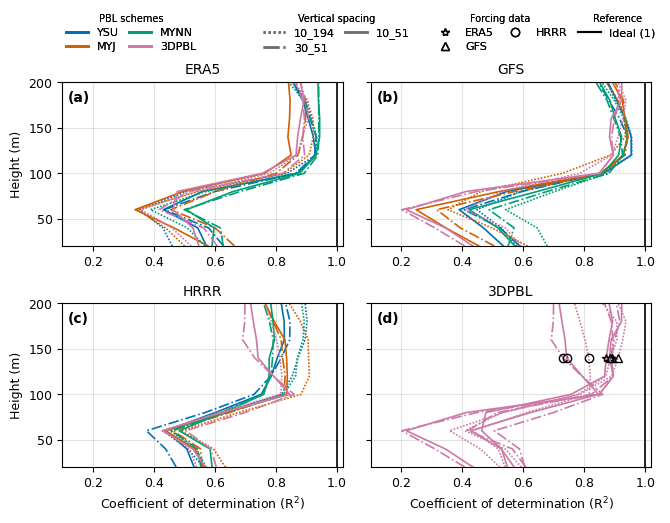

Saved: profiles_r2_ws/E05/r2_ws_2x2_E05.[pdf/png]


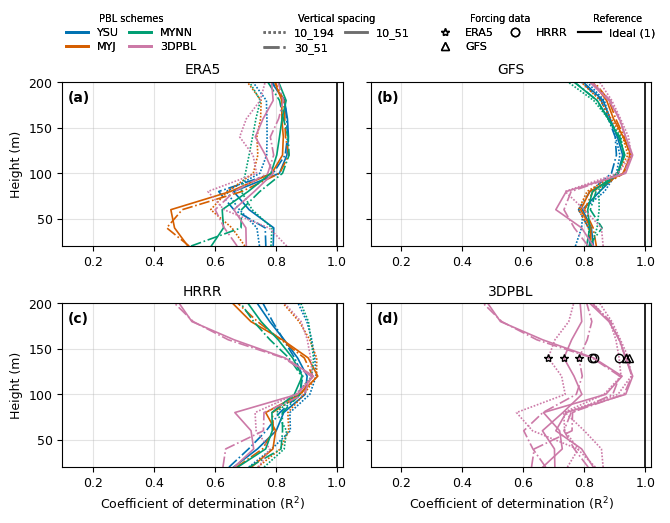

Saved: profiles_r2_ws/E06/r2_ws_2x2_E06.[pdf/png]
Done. Outputs in: profiles_r2_ws/E05 and profiles_r2_ws/E06


In [103]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT       = "errors_r2_ws"           # <-- folder in CURRENT directory
OUT_ROOT         = "profiles_r2_ws"         # <-- output folder

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
MARKER_HEIGHT_M = 140

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (6.85, 5.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# --- updated vertical nomenclature ---
vert_to_label = {"54": "10_194", "80": "30_51", "93": "10_51"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}
vert_legend_color = "#6E6E6E"  # gray, not black

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """Parent dir like: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def load_profile(path):
    """
    Accepts:
      - (10,) already a vertical profile
      - (time,10) -> mean over time -> (10,)
    """
    arr = np.load(path)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)
    raise ValueError(f"Unexpected shape {arr.shape} in {path}")

def collect_r2_index():
    """
    Looks for R2 files under errors_r2_ws recursively.
    Expects filenames like: R2_WS_E05.npy (case-insensitive).
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")

    out = []
    for loc in LOCATIONS:
        patt = os.path.join(root, "**", f"*{loc}*.npy")
        for f in glob.glob(patt, recursive=True):
            base = os.path.basename(f).lower()

            if "r2" not in base:
                continue
            if "_ws_" not in base and "ws" not in base:
                continue

            parsed = parse_parts_from_parent(f)
            if not parsed:
                continue
            icbc, pbl, vert = parsed
            out.append((f, icbc, pbl, vert, loc))

    return out

def compute_global_xlims(idx, xmin_fixed=0.10, xmax_fixed=1.02):
    """
    Fixed x-axis limits across all comparable R² panels.
    Keeps a small margin beyond 1 so the ideal line at 1 is visible.
    """
    return (xmin_fixed, xmax_fixed)

def panel_label(ax, txt):
    ax.text(
        0.02, 0.95, txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10, fontweight="bold"
    )

def add_grouped_top_legends(fig):
    """
    Top grouped legend blocks (PBL schemes, Vertical spacing, ICBC, Reference).
    """
    title_fs = 7
    label_fs = 8

    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    vert_handles = [
        Line2D([0], [0], color=vert_legend_color, lw=1.8,
               linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ["54", "80", "93"]
    ]

    icbc_handles = [
        Line2D([0], [0], linestyle="None", color="black",
               marker=icbc_marker[i], markersize=6,
               markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
               label=i.upper())
        for i in ["era5", "gfs", "hrrr"]
    ]

    ref_handles = [
        Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (1)")
    ]

    leg1 = fig.legend(
        handles=pbl_handles, loc="upper center", bbox_to_anchor=(0.22, 1.02),
        frameon=False, ncol=2, title="PBL schemes",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg2 = fig.legend(
        handles=vert_handles, loc="upper center", bbox_to_anchor=(0.52, 1.02),
        frameon=False, ncol=2, title="Vertical spacing",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg3 = fig.legend(
        handles=icbc_handles, loc="upper center", bbox_to_anchor=(0.76, 1.02),
        frameon=False, ncol=2, title="Forcing data",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg4 = fig.legend(
        handles=ref_handles, loc="upper center", bbox_to_anchor=(0.93, 1.02),
        frameon=False, ncol=1, title="Reference",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)
    fig.add_artist(leg4)

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# ===================== Panel plotters =====================
def plot_panel_single_icbc(ax, loc, idx, icbc_fixed, xlim, panel_txt):
    """
    Panel for ERA5/GFS/HRRR:
      - lines: all PBLs × vertical levels
      - color=PBL, linestyle=vert
    """
    items = [(f, icbc, pbl, vert)
             for (f, icbc, pbl, vert, L) in idx
             if L == loc and icbc == icbc_fixed]

    items.sort(key=lambda x: (
        PBL_ORDER.get(x[2], 99),
        VERT_ORDER.get(x[3], 99),
        os.path.basename(os.path.dirname(x[0]))
    ))

    ax.axvline(1.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            continue

        ax.plot(
            prof, z,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2
        )

    ax.set_xlim(xlim)
    ax.set_ylim([20, 200])
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"{icbc_fixed.upper()}")
    panel_label(ax, panel_txt)

def plot_panel_3dpbl(ax, loc, idx, xlim, panel_txt):
    """
    Panel for 3DPBL:
      - lines: ICBC × vertical levels
      - color=3dpbl
      - linestyle=vert
      - marker=ICBC at 140 m
    """
    items = [(f, icbc, pbl, vert)
             for (f, icbc, pbl, vert, L) in idx
             if L == loc and pbl == "3dpbl"]

    items.sort(key=lambda x: (
        ICBC_ORDER.get(x[1], 99),
        VERT_ORDER.get(x[3], 99),
        os.path.basename(os.path.dirname(x[0]))
    ))

    ax.axvline(1.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            continue

        ax.plot(
            prof, z,
            color=pbl_color["3dpbl"],
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            marker=icbc_marker.get(icbc, "o"),
            markevery=[MARK_IDX],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
        )

    ax.set_xlim(xlim)
    ax.set_ylim([20, 200])
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title("3DPBL")
    panel_label(ax, panel_txt)

# ===================== 2×2 figure per buoy =====================
def plot_r2_2x2_per_buoy(loc, idx, xlim):
    outdir = ensure_outdir(loc)

    fig, axs = plt.subplots(2, 2, figsize=FIGSIZE, sharey=True)
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.88,
        bottom=0.14,
        wspace=0.1,
        hspace=0.35
    )

    plot_panel_single_icbc(axs[0, 0], loc, idx, "era5", xlim, "(a)")
    plot_panel_single_icbc(axs[0, 1], loc, idx, "gfs",  xlim, "(b)")
    plot_panel_single_icbc(axs[1, 0], loc, idx, "hrrr", xlim, "(c)")
    plot_panel_3dpbl      (axs[1, 1], loc, idx,        xlim, "(d)")

    axs[1, 0].set_xlabel("Coefficient of determination (R$^2$)")
    axs[1, 1].set_xlabel("Coefficient of determination (R$^2$)")
    axs[0, 0].set_ylabel("Height (m)")
    axs[1, 0].set_ylabel("Height (m)")

    add_grouped_top_legends(fig)

    base = f"r2_ws_2x2_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_r2_index()
    print("Indexed R2 files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    # fixed x-axis limits across the whole comparable batch
    R2_XLIM = compute_global_xlims(idx, xmin_fixed=0.10, xmax_fixed=1.02)
    print("Using fixed R2 x-limits:", R2_XLIM)

    for loc in LOCATIONS:
        plot_r2_2x2_per_buoy(loc, idx, R2_XLIM)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed R2 files: 72
Using fixed R2 x-limits: (0.0, 1.02)


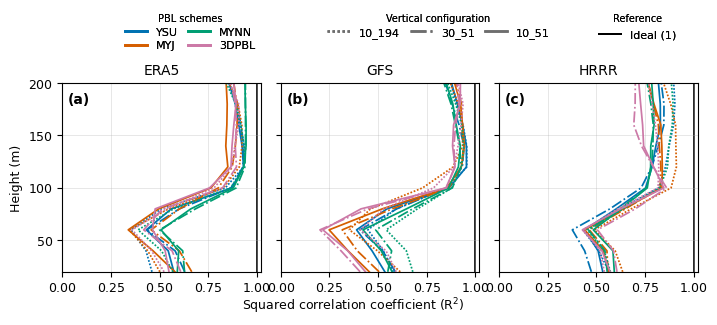

Saved: profiles_r2_ws_3panel/E05/r2_ws_3panel_E05.pdf
Saved: profiles_r2_ws_3panel/E05/r2_ws_3panel_E05.png


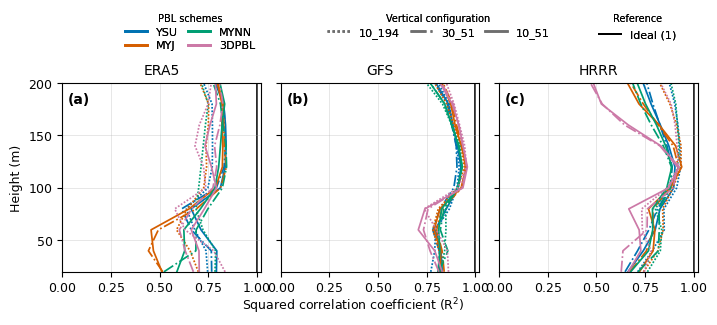

Saved: profiles_r2_ws_3panel/E06/r2_ws_3panel_E06.pdf
Saved: profiles_r2_ws_3panel/E06/r2_ws_3panel_E06.png
Done. Outputs in: profiles_r2_ws_3panel/E05 and profiles_r2_ws_3panel/E06


In [4]:
####################### 3 panel r2 #########################
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT = "errors_r2_ws"
OUT_ROOT   = "profiles_r2_ws_3panel"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Full-width 1x3 figure
FIGSIZE = (7.1, 3.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

vert_to_label = {
    "54": "10_194",
    "80": "30_51",
    "93": "10_51",
}

vert_to_ls = {
    "54": (0, (1, 1)),
    "80": "-.",
    "93": "-",
}

vert_legend_color = "#6E6E6E"

PBL_ORDER = {
    "ysu": 0,
    "myj": 1,
    "mynn": 2,
    "3dpbl": 3,
}

VERT_ORDER = {
    "54": 0,
    "80": 1,
    "93": 2,
}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_'
    r'(?P<pbl>ysu|myj|mynn|3dpbl)_'
    r'vert(?P<vert>54|80|93)$'
)


def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir


def parse_parts_from_parent(path):
    """
    Parent directory example:
        era5_ysu_vert80
    """
    run_dir = os.path.basename(os.path.dirname(path))

    m = run_dir_pat.match(run_dir)

    if not m:
        return None

    g = m.groupdict()

    return g["icbc"], g["pbl"], g["vert"]


def load_profile(path):
    """
    Accepts:
      - (10,)       : already a vertical profile
      - (time, 10) : mean over time -> (10,)
    """
    arr = np.load(path)

    if arr.ndim == 1:
        return arr

    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)

    raise ValueError(
        f"Unexpected shape {arr.shape} in {path}"
    )


def collect_r2_index():
    """
    Recursively searches ERROR_ROOT for R2 wind-speed files.

    Expected filenames include examples such as:
        R2_WS_E05.npy
    """
    root = os.path.join(
        os.getcwd(),
        ERROR_ROOT
    )

    if not os.path.isdir(root):
        raise FileNotFoundError(
            f"Folder not found: {root}"
        )

    out = []

    for loc in LOCATIONS:

        patt = os.path.join(
            root,
            "**",
            f"*{loc}*.npy"
        )

        for f in glob.glob(
            patt,
            recursive=True
        ):

            base = os.path.basename(f).lower()

            if "r2" not in base:
                continue

            if "_ws_" not in base and "ws" not in base:
                continue

            parsed = parse_parts_from_parent(f)

            if not parsed:
                continue

            icbc, pbl, vert = parsed

            out.append(
                (f, icbc, pbl, vert, loc)
            )

    return out


def compute_global_xlims():
    """
    R² is bounded between 0 and 1.
    Small extension beyond 1 keeps the reference line visible.
    """
    return (0.0, 1.02)


def panel_label(ax, txt):

    ax.text(
        0.03,
        0.95,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )


# ===================== Legends =====================
def add_grouped_top_legends(fig):
    """
    Encoding:
      color     = PBL scheme
      linestyle = vertical configuration

    Forcing dataset is encoded by panel.
    """

    title_fs = 7
    label_fs = 8

    # ---------------- PBL schemes ----------------
    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=p.upper()
        )
        for p in [
            "ysu",
            "myj",
            "mynn",
            "3dpbl"
        ]
    ]

    # ---------------- Vertical configurations ----------------
    vert_handles = [
        Line2D(
            [0], [0],
            color=vert_legend_color,
            lw=1.8,
            linestyle=vert_to_ls[v],
            label=vert_to_label[v]
        )
        for v in [
            "54",
            "80",
            "93"
        ]
    ]

    # ---------------- Reference ----------------
    ref_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=1.4,
            linestyle="-",
            label="Ideal (1)"
        )
    ]

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.27, 1.01),
        frameon=False,
        ncol=2,
        title="PBL schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    leg2 = fig.legend(
        handles=vert_handles,
        loc="upper center",
        bbox_to_anchor=(0.62, 1.01),
        frameon=False,
        ncol=3,
        title="Vertical configuration",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    leg3 = fig.legend(
        handles=ref_handles,
        loc="upper center",
        bbox_to_anchor=(0.90, 1.01),
        frameon=False,
        ncol=1,
        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        borderaxespad=0.0,
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)


# ===================== Panel plotting =====================
def plot_panel_single_icbc(
    ax,
    loc,
    idx,
    icbc_fixed,
    xlim,
    panel_txt,
):
    """
    One panel for one forcing dataset.

    Encoding:
      color     = PBL scheme
      linestyle = vertical configuration
    """

    items = [
        (f, icbc, pbl, vert)
        for (
            f,
            icbc,
            pbl,
            vert,
            L
        ) in idx
        if L == loc
        and icbc == icbc_fixed
    ]

    items.sort(
        key=lambda x: (
            PBL_ORDER.get(x[2], 99),
            VERT_ORDER.get(x[3], 99),
            os.path.basename(
                os.path.dirname(x[0])
            ),
        )
    )

    # Ideal R² reference
    ax.axvline(
        1.0,
        color="black",
        linewidth=1.2,
        zorder=1,
    )

    for f, icbc, pbl, vert in items:

        prof = load_profile(f)

        if prof.shape[0] != len(z):

            print(
                f"Skipping {f}: "
                f"expected {len(z)} heights, "
                f"got {prof.shape[0]}"
            )

            continue

        ax.plot(
            prof,
            z,
            color=pbl_color.get(
                pbl,
                "0.5"
            ),
            linestyle=vert_to_ls.get(
                vert,
                "-"
            ),
            linewidth=1.25,
            zorder=2,
        )

    ax.set_xlim(
        xlim
    )

    ax.set_ylim(
        20,
        200
    )

    ax.grid(
        True,
        alpha=0.30,
        linewidth=0.7,
    )

    ax.set_title(
        icbc_fixed.upper()
    )

    panel_label(
        ax,
        panel_txt
    )


# ===================== 1x3 figure per buoy =====================
def plot_r2_3panel_per_buoy(
    loc,
    idx,
    xlim,
):

    outdir = ensure_outdir(
        loc
    )

    fig, axs = plt.subplots(
        1,
        3,
        figsize=FIGSIZE,
        sharex=True,
        sharey=True,
    )

    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        top=0.78,
        bottom=0.19,
        wspace=0.10,
    )

    # ---------------- ERA5 ----------------
    plot_panel_single_icbc(
        axs[0],
        loc,
        idx,
        "era5",
        xlim,
        "(a)",
    )

    # ---------------- GFS ----------------
    plot_panel_single_icbc(
        axs[1],
        loc,
        idx,
        "gfs",
        xlim,
        "(b)",
    )

    # ---------------- HRRR ----------------
    plot_panel_single_icbc(
        axs[2],
        loc,
        idx,
        "hrrr",
        xlim,
        "(c)",
    )

    # Shared y-axis label
    axs[0].set_ylabel(
        "Height (m)"
    )

    # Shared x-axis label
    fig.supxlabel(
        "Squared correlation coefficient (R$^2$)",
        fontsize=9,
        y=0.055,
    )

    add_grouped_top_legends(
        fig
    )

    base = (
        f"r2_ws_3panel_{loc}"
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(
        f"Saved: {pdf_path}"
    )

    print(
        f"Saved: {png_path}"
    )


# ===================== RUN =====================
if __name__ == "__main__":

    idx = collect_r2_index()

    print(
        "Indexed R2 files:",
        len(idx)
    )

    os.makedirs(
        OUT_ROOT,
        exist_ok=True
    )

    # R² has a natural range from 0 to 1
    R2_XLIM = compute_global_xlims()

    print(
        "Using fixed R2 x-limits:",
        R2_XLIM
    )

    for loc in LOCATIONS:

        plot_r2_3panel_per_buoy(
            loc,
            idx,
            R2_XLIM,
        )

    print(
        f"Done. Outputs in: "
        f"{OUT_ROOT}/E05 and "
        f"{OUT_ROOT}/E06"
    )

In [30]:
# # # ######## It is for emd single plots, so making it commented out. 2x2 panel is done in the next cell. Use this one (with updated legend and axis) if single panel is requested)
# import os, glob, re
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# #
# # ===================== USER SETTINGS =====================
# ERROR_ROOT       = "errors_emd_ws"          # <-- folder in CURRENT directory
# OUT_ROOT         = "profiles_emd_ws"        # <-- output folder

# # file names like this: EMD_WS_E05.npy
# LOCATIONS = ["E05", "E06"]
# ICBCS     = ["era5", "gfs", "hrrr"]
# PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# MARKER_HEIGHT_M = 140

# # ===================== Styling =====================
# plt.rcParams.update({
#     "font.family": "DejaVu Sans",
#     "mathtext.fontset": "dejavusans",
#     "font.size": 10,
#     "axes.titlesize": 10,
#     "axes.labelsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
#     "legend.fontsize": 9,
# })

# FIGSIZE = (6.85, 5.2)
# DPI_PNG = 300

# # ===================== Encodings =====================
# pbl_color = {
#     "ysu":   "#0072B2",
#     "myj":   "#D55E00",
#     "mynn":  "#009E73",
#     "3dpbl": "#C2185B",
# }

# vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
# vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}

# icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

# ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
# PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
# VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# # ===================== Helpers =====================
# run_dir_pat = re.compile(
#     r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
# )

# def ensure_outdir(loc):
#     outdir = os.path.join(OUT_ROOT, loc)
#     os.makedirs(outdir, exist_ok=True)
#     return outdir

# def parse_parts_from_parent(path):
#     """Parent dir like: era5_ysu_vert80"""
#     run_dir = os.path.basename(os.path.dirname(path))
#     m = run_dir_pat.match(run_dir)
#     if not m:
#         return None
#     g = m.groupdict()
#     return g["icbc"], g["pbl"], g["vert"]

# def load_profile(path):
#     """
#     Accepts:
#       - (10,) already a vertical profile
#       - (time,10) -> mean over time -> (10,)
#     """
#     arr = np.load(path)
#     if arr.ndim == 1:
#         return arr
#     if arr.ndim == 2 and arr.shape[1] == 10:
#         return np.nanmean(arr, axis=0)
#     raise ValueError(f"Unexpected shape {arr.shape} in {path}")

# def collect_emd_index():
#     """
#     Looks for EMD files under errors_emd_ws recursively.
#     Expects filenames like: EMD_WS_E05.npy
#     """
#     root = os.path.join(os.getcwd(), ERROR_ROOT)
#     if not os.path.isdir(root):
#         raise FileNotFoundError(f"Folder not found: {root}")

#     out = []
#     for loc in LOCATIONS:
#         patt = os.path.join(root, "**", f"*{loc}*.npy")
#         for f in glob.glob(patt, recursive=True):
#             base = os.path.basename(f).lower()
#             if "emd" not in base:
#                 continue
#             if "_ws_" not in base:
#                 continue

#             parsed = parse_parts_from_parent(f)
#             if not parsed:
#                 continue
#             icbc, pbl, vert = parsed
#             out.append((f, icbc, pbl, vert, loc))

#     return out

# # fixed marker index at 140 m
# if MARKER_HEIGHT_M not in z:
#     raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
# MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# # ===================== Plot functions =====================
# def plot_emd_single_icbc(loc, idx, icbc_fixed):
#     """
#     One figure per buoy per ICBC:
#       - EMD profile: x=EMD, y=height
#       - lines: all PBLs × vertical levels (available)
#       - color=PBL, linestyle=vert
#       - ideal line: x=0 (black)
#     """
#     outdir = ensure_outdir(loc)

#     items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
#     if not items:
#         print(f"[{loc}] No EMD files for {icbc_fixed}.")
#         return

#     items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

#     fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

#     # Ideal line (EMD=0)
#     ax.axvline(0.0, color="black", linewidth=1.2)

#     for f, icbc, pbl, vert in items:
#         prof = load_profile(f)
#         if prof.shape[0] != 10:
#             print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
#             continue

#         ax.plot(
#             prof, z,
#             color=pbl_color.get(pbl, "0.5"),
#             linestyle=vert_to_ls.get(vert, "-"),
#             linewidth=1.2
#         )

#     ax.set_ylim([20, 200])
#     ax.set_xlabel("EMD")
#     ax.set_ylabel("Height (m)")
#     ax.grid(True, alpha=0.35, linewidth=0.8)
#     ax.set_title(f"Wind Speed EMD profiles with {icbc_fixed.upper()} Buoy {loc}", loc="center")

#     # Legend (PBL + vert + ideal)
#     pbl_handles = [Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper()) for p in PBLS]
#     vert_handles = [Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
#                     for v in ["54", "80", "93"] if v in vert_to_ls]
#     ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

#     ax.legend(handles=pbl_handles + vert_handles + ideal_handle,
#               loc="upper left", frameon=False, ncol=2,
#               handlelength=2.4, columnspacing=1.2, labelspacing=0.5)

#     base = f"emd_ws_{icbc_fixed}_{loc}"
#     fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
#     fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
#     plt.close(fig)
#     print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# def plot_emd_3dpbl_all_icbc(loc, idx):
#     """
#     One figure per buoy for 3DPBL:
#       - lines: ICBC × vertical levels (available)
#       - color=3dpbl
#       - linestyle=vert
#       - marker=ICBC (black hollow) fixed at 140 m
#       - ideal line: x=0
#     """
#     outdir = ensure_outdir(loc)

#     items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
#     if not items:
#         print(f"[{loc}] No 3DPBL EMD files.")
#         return

#     items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

#     fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

#     ax.axvline(0.0, color="black", linewidth=1.2)

#     for f, icbc, pbl, vert in items:
#         prof = load_profile(f)
#         if prof.shape[0] != 10:
#             print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
#             continue

#         ax.plot(
#             prof, z,
#             color=pbl_color["3dpbl"],
#             linestyle=vert_to_ls.get(vert, "-"),
#             linewidth=1.2,
#             marker=icbc_marker.get(icbc, "o"),
#             markevery=[MARK_IDX],
#             markersize=6,
#             markeredgecolor="black",
#             markerfacecolor="none",
#             markeredgewidth=1.0,
#         )

#     ax.set_ylim([20, 200])
#     ax.set_xlabel("EMD")
#     ax.set_ylabel("Height (m)")
#     ax.grid(True, alpha=0.35, linewidth=0.8)
#     ax.set_title(f"Wind Speed EMD profiles with 3DPBL at Buoy {loc}", loc="center")

#     icbc_handles = [
#         Line2D([0], [0], linestyle="None", color="black",
#                marker=icbc_marker[i], markersize=7,
#                markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
#                label=i.upper())
#         for i in ICBCS
#     ]
#     vert_handles = [Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
#                     for v in ["54", "80", "93"] if v in vert_to_ls]
#     ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

#     ax.legend(handles=icbc_handles + ideal_handle + vert_handles,
#               loc="upper left", frameon=False, ncol=2,
#               handlelength=2.2, columnspacing=1.2, labelspacing=0.5)

#     base = f"emd_ws_3dpbl_allICBC_{loc}"
#     fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
#     fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
#     plt.close(fig)
#     print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# # ===================== RUN =====================
# if __name__ == "__main__":
#     idx = collect_emd_index()
#     print("Indexed EMD files:", len(idx))
#     os.makedirs(OUT_ROOT, exist_ok=True)

#     for loc in LOCATIONS:
#         plot_emd_single_icbc(loc, idx, "era5")
#         plot_emd_single_icbc(loc, idx, "gfs")
#         plot_emd_single_icbc(loc, idx, "hrrr")
#         plot_emd_3dpbl_all_icbc(loc, idx)

#     print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed EMD files: 72
Saved: profiles_emd_ws/E05/emd_ws_era5_E05.[pdf/png]
Saved: profiles_emd_ws/E05/emd_ws_gfs_E05.[pdf/png]
Saved: profiles_emd_ws/E05/emd_ws_hrrr_E05.[pdf/png]
Saved: profiles_emd_ws/E05/emd_ws_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_emd_ws/E06/emd_ws_era5_E06.[pdf/png]
Saved: profiles_emd_ws/E06/emd_ws_gfs_E06.[pdf/png]
Saved: profiles_emd_ws/E06/emd_ws_hrrr_E06.[pdf/png]
Saved: profiles_emd_ws/E06/emd_ws_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_emd_ws/E05 and profiles_emd_ws/E06


Indexed EMD files: 72
Using fixed EMD x-limits: (-0.05, 2.62)


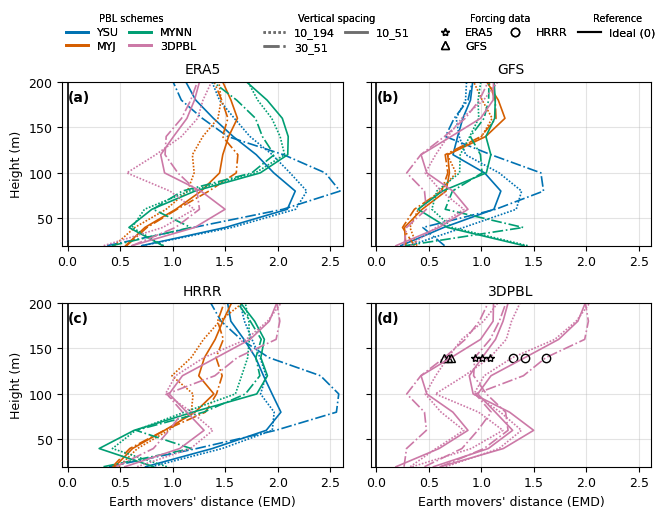

Saved: profiles_emd_ws/E05/emd_ws_2x2_E05.[pdf/png]


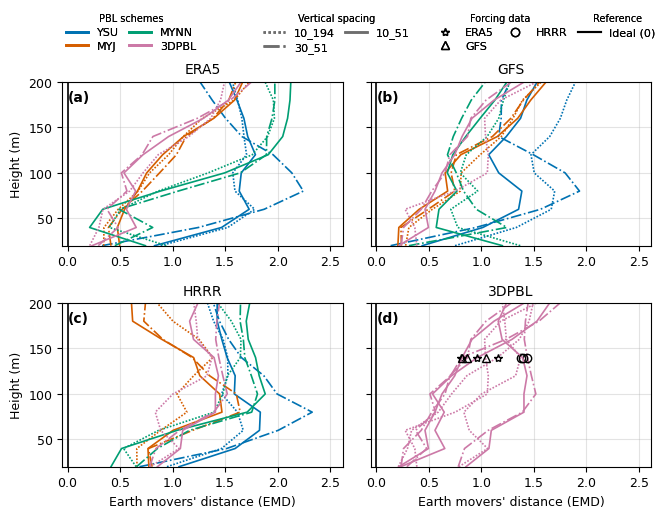

Saved: profiles_emd_ws/E06/emd_ws_2x2_E06.[pdf/png]
Done. Outputs in: profiles_emd_ws/E05 and profiles_emd_ws/E06


In [102]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT       = "errors_emd_ws"          # <-- folder in CURRENT directory
OUT_ROOT         = "profiles_emd_ws"        # <-- output folder

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
MARKER_HEIGHT_M = 140

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (6.85, 5.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# --- updated vertical nomenclature ---
vert_to_label = {"54": "10_194", "80": "30_51", "93": "10_51"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}
vert_legend_color = "#6E6E6E"  # gray, not black

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """Parent dir like: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def load_profile(path):
    """
    Accepts:
      - (10,) already a vertical profile
      - (time,10) -> mean over time -> (10,)
    """
    arr = np.load(path)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)
    raise ValueError(f"Unexpected shape {arr.shape} in {path}")

def collect_emd_index():
    """
    Looks for EMD files under errors_emd_ws recursively.
    Expects filenames like: EMD_WS_E05.npy
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")

    out = []
    for loc in LOCATIONS:
        patt = os.path.join(root, "**", f"*{loc}*.npy")
        for f in glob.glob(patt, recursive=True):
            base = os.path.basename(f).lower()
            if "emd" not in base:
                continue
            if "_ws_" not in base and "ws" not in base:
                continue

            parsed = parse_parts_from_parent(f)
            if not parsed:
                continue
            icbc, pbl, vert = parsed
            out.append((f, icbc, pbl, vert, loc))

    return out

def compute_global_xlims(idx, pad=0.02, left_pad=0.05):
    """
    Fixed x-axis limits across all comparable EMD panels.
    Keeps a small negative left margin so the ideal line at 0 is visible.
    """
    vals = []
    for f, icbc, pbl, vert, loc in idx:
        try:
            prof = load_profile(f)
        except Exception:
            continue
        vals.extend(prof.ravel())

    vals = np.asarray(vals, dtype=float)

    xmin = -left_pad
    xmax = np.nanmax(vals) + pad

    xmin = np.floor(xmin * 100) / 100
    xmax = np.ceil(xmax * 100) / 100
    return (xmin, xmax)
def panel_label(ax, txt):
    ax.text(
        0.02, 0.95, txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10, fontweight="bold"
    )

def add_grouped_top_legends(fig):
    """
    Top grouped legend blocks (PBL schemes, Vertical spacing, ICBC, Reference).
    """
    title_fs = 7
    label_fs = 8

    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    vert_handles = [
        Line2D([0], [0], color=vert_legend_color, lw=1.8,
               linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ["54", "80", "93"]
    ]

    icbc_handles = [
        Line2D([0], [0], linestyle="None", color="black",
               marker=icbc_marker[i], markersize=6,
               markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
               label=i.upper())
        for i in ["era5", "gfs", "hrrr"]
    ]

    ref_handles = [
        Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")
    ]

    leg1 = fig.legend(
        handles=pbl_handles, loc="upper center", bbox_to_anchor=(0.22, 1.02),
        frameon=False, ncol=2, title="PBL schemes",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg2 = fig.legend(
        handles=vert_handles, loc="upper center", bbox_to_anchor=(0.52, 1.02),
        frameon=False, ncol=2, title="Vertical spacing",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg3 = fig.legend(
        handles=icbc_handles, loc="upper center", bbox_to_anchor=(0.76, 1.02),
        frameon=False, ncol=2, title="Forcing data",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg4 = fig.legend(
        handles=ref_handles, loc="upper center", bbox_to_anchor=(0.93, 1.02),
        frameon=False, ncol=1, title="Reference",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)
    fig.add_artist(leg4)

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# ===================== Panel plotters =====================
def plot_panel_single_icbc(ax, loc, idx, icbc_fixed, xlim, panel_txt):
    """
    Panel for ERA5/GFS/HRRR:
      - lines: all PBLs × vertical levels
      - color=PBL, linestyle=vert
    """
    items = [(f, icbc, pbl, vert)
             for (f, icbc, pbl, vert, L) in idx
             if L == loc and icbc == icbc_fixed]

    items.sort(key=lambda x: (
        PBL_ORDER.get(x[2], 99),
        VERT_ORDER.get(x[3], 99),
        os.path.basename(os.path.dirname(x[0]))
    ))

    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            continue

        ax.plot(
            prof, z,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2
        )

    ax.set_xlim(xlim)
    ax.set_ylim([20, 200])
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"{icbc_fixed.upper()}")
    panel_label(ax, panel_txt)

def plot_panel_3dpbl(ax, loc, idx, xlim, panel_txt):
    """
    Panel for 3DPBL:
      - lines: ICBC × vertical levels
      - color=3dpbl
      - linestyle=vert
      - marker=ICBC at 140 m
    """
    items = [(f, icbc, pbl, vert)
             for (f, icbc, pbl, vert, L) in idx
             if L == loc and pbl == "3dpbl"]

    items.sort(key=lambda x: (
        ICBC_ORDER.get(x[1], 99),
        VERT_ORDER.get(x[3], 99),
        os.path.basename(os.path.dirname(x[0]))
    ))

    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            continue

        ax.plot(
            prof, z,
            color=pbl_color["3dpbl"],
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            marker=icbc_marker.get(icbc, "o"),
            markevery=[MARK_IDX],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
        )

    ax.set_xlim(xlim)
    ax.set_ylim([20, 200])
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title("3DPBL")
    panel_label(ax, panel_txt)

# ===================== 2×2 figure per buoy =====================
def plot_emd_2x2_per_buoy(loc, idx, xlim):
    outdir = ensure_outdir(loc)

    fig, axs = plt.subplots(2, 2, figsize=FIGSIZE, sharey=True)
    fig.subplots_adjust(
        left=0.12,
        right=.98,
        top=0.88,
        bottom=0.14,
        wspace=0.1,
        hspace=0.35
    )

    plot_panel_single_icbc(axs[0, 0], loc, idx, "era5", xlim, "(a)")
    plot_panel_single_icbc(axs[0, 1], loc, idx, "gfs",  xlim, "(b)")
    plot_panel_single_icbc(axs[1, 0], loc, idx, "hrrr", xlim, "(c)")
    plot_panel_3dpbl      (axs[1, 1], loc, idx,        xlim, "(d)")

    axs[1, 0].set_xlabel("Earth movers' distance (EMD)")
    axs[1, 1].set_xlabel("Earth movers' distance (EMD)")
    axs[0, 0].set_ylabel("Height (m)")
    axs[1, 0].set_ylabel("Height (m)")

    add_grouped_top_legends(fig)

    base = f"emd_ws_2x2_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_emd_index()
    print("Indexed EMD files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    # fixed x-axis limits across the whole comparable batch
    EMD_XLIM = compute_global_xlims(idx, pad=0.02, left_pad=0.05)
    print("Using fixed EMD x-limits:", EMD_XLIM)

    for loc in LOCATIONS:
        plot_emd_2x2_per_buoy(loc, idx, EMD_XLIM)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed EMD files: 72
Using fixed EMD x-limits: (0.0, 2.7)


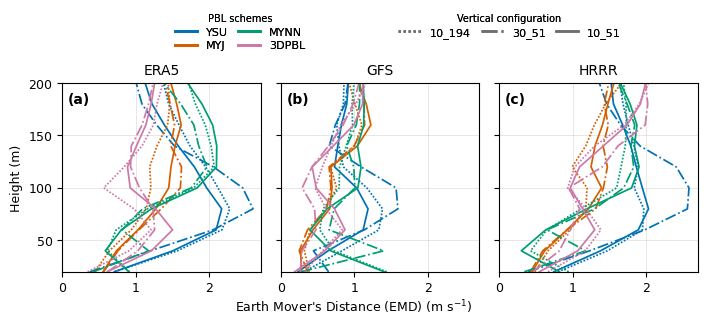

Saved: profiles_emd_ws_3panel/E05/emd_ws_3panel_E05.pdf
Saved: profiles_emd_ws_3panel/E05/emd_ws_3panel_E05.png


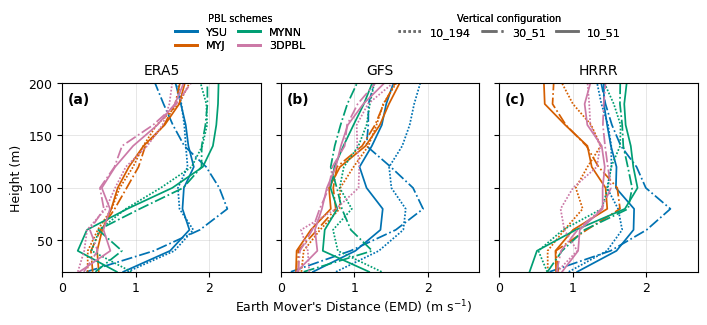

Saved: profiles_emd_ws_3panel/E06/emd_ws_3panel_E06.pdf
Saved: profiles_emd_ws_3panel/E06/emd_ws_3panel_E06.png
Done. Outputs in: profiles_emd_ws_3panel/E05 and profiles_emd_ws_3panel/E06


In [7]:
########### 3 panel EMD ################
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT = "errors_emd_ws"
OUT_ROOT   = "profiles_emd_ws_3panel"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (7.1, 3.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

vert_to_label = {
    "54": "10_194",
    "80": "30_51",
    "93": "10_51",
}

vert_to_ls = {
    "54": (0, (1, 1)),
    "80": "-.",
    "93": "-",
}

vert_legend_color = "#6E6E6E"

PBL_ORDER = {
    "ysu": 0,
    "myj": 1,
    "mynn": 2,
    "3dpbl": 3,
}

VERT_ORDER = {
    "54": 0,
    "80": 1,
    "93": 2,
}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_'
    r'(?P<pbl>ysu|myj|mynn|3dpbl)_'
    r'vert(?P<vert>54|80|93)$'
)


def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir


def parse_parts_from_parent(path):
    """Parent directory example: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))

    m = run_dir_pat.match(run_dir)

    if not m:
        return None

    g = m.groupdict()

    return g["icbc"], g["pbl"], g["vert"]


def load_profile(path):
    """
    Accepts:
      - (10,)       : already a vertical profile
      - (time, 10) : mean over time -> (10,)
    """
    arr = np.load(path)

    if arr.ndim == 1:
        return arr

    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)

    raise ValueError(
        f"Unexpected shape {arr.shape} in {path}"
    )


def collect_emd_index():
    """
    Recursively searches ERROR_ROOT for EMD wind-speed files.

    Example:
        EMD_WS_E05.npy
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)

    if not os.path.isdir(root):
        raise FileNotFoundError(
            f"Folder not found: {root}"
        )

    out = []

    for loc in LOCATIONS:

        patt = os.path.join(
            root,
            "**",
            f"*{loc}*.npy"
        )

        for f in glob.glob(patt, recursive=True):

            base = os.path.basename(f).lower()

            if "emd" not in base:
                continue

            if "_ws_" not in base and "ws" not in base:
                continue

            parsed = parse_parts_from_parent(f)

            if not parsed:
                continue

            icbc, pbl, vert = parsed

            out.append(
                (f, icbc, pbl, vert, loc)
            )

    return out


def compute_global_xlims(idx, pad=0.02):
    """
    Common EMD x-axis limits across:
      - ERA5/GFS/HRRR
      - E05/E06

    EMD is nonnegative, so x-axis begins at 0.
    """
    vals = []

    for f, icbc, pbl, vert, loc in idx:

        try:
            prof = load_profile(f)
        except Exception:
            continue

        vals.extend(prof.ravel())

    vals = np.asarray(vals, dtype=float)

    xmax = np.nanmax(vals) + pad

    # Round upward to nearest 0.1
    xmax = np.ceil(xmax * 10) / 10

    return (0.0, xmax)


def panel_label(ax, txt):
    ax.text(
        0.03,
        0.95,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )


# ===================== Legends =====================
def add_grouped_top_legends(fig):
    """
    Encoding:
      color     = PBL scheme
      linestyle = vertical configuration

    Forcing dataset is represented by panel.
    """

    title_fs = 7
    label_fs = 8

    # PBL schemes
    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=p.upper()
        )
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    # Vertical configurations
    vert_handles = [
        Line2D(
            [0], [0],
            color=vert_legend_color,
            lw=1.8,
            linestyle=vert_to_ls[v],
            label=vert_to_label[v]
        )
        for v in ["54", "80", "93"]
    ]

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.34, 1.01),
        frameon=False,
        ncol=2,
        title="PBL schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    leg2 = fig.legend(
        handles=vert_handles,
        loc="upper center",
        bbox_to_anchor=(0.72, 1.01),
        frameon=False,
        ncol=3,
        title="Vertical configuration",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)


# ===================== Panel plotting =====================
def plot_panel_single_icbc(
    ax,
    loc,
    idx,
    icbc_fixed,
    xlim,
    panel_txt,
):
    """
    One panel for one forcing dataset.

    Encoding:
      color     = PBL scheme
      linestyle = vertical configuration
    """

    items = [
        (f, icbc, pbl, vert)
        for (f, icbc, pbl, vert, L) in idx
        if L == loc and icbc == icbc_fixed
    ]

    items.sort(
        key=lambda x: (
            PBL_ORDER.get(x[2], 99),
            VERT_ORDER.get(x[3], 99),
            os.path.basename(os.path.dirname(x[0])),
        )
    )

    for f, icbc, pbl, vert in items:

        prof = load_profile(f)

        if prof.shape[0] != len(z):
            print(
                f"Skipping {f}: "
                f"expected {len(z)} heights, "
                f"got {prof.shape[0]}"
            )
            continue

        ax.plot(
            prof,
            z,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.25,
        )

    ax.set_xlim(xlim)
    ax.set_ylim(20, 200)

    ax.grid(
        True,
        alpha=0.30,
        linewidth=0.7,
    )

    ax.set_title(
        icbc_fixed.upper()
    )

    panel_label(
        ax,
        panel_txt
    )


# ===================== 1x3 figure per buoy =====================
def plot_emd_3panel_per_buoy(
    loc,
    idx,
    xlim,
):

    outdir = ensure_outdir(loc)

    fig, axs = plt.subplots(
        1,
        3,
        figsize=FIGSIZE,
        sharex=True,
        sharey=True,
    )

    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        top=0.78,
        bottom=0.19,
        wspace=0.10,
    )

    plot_panel_single_icbc(
        axs[0],
        loc,
        idx,
        "era5",
        xlim,
        "(a)",
    )

    plot_panel_single_icbc(
        axs[1],
        loc,
        idx,
        "gfs",
        xlim,
        "(b)",
    )

    plot_panel_single_icbc(
        axs[2],
        loc,
        idx,
        "hrrr",
        xlim,
        "(c)",
    )

    # Shared y-axis label
    axs[0].set_ylabel(
        "Height (m)"
    )

    # Shared x-axis label
    fig.supxlabel(
        "Earth Mover's Distance (EMD) (m s$^{-1}$)",
        fontsize=9,
        y=0.055,
    )

    add_grouped_top_legends(fig)

    base = f"emd_ws_3panel_{loc}"

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


# ===================== RUN =====================
if __name__ == "__main__":

    idx = collect_emd_index()

    print(
        "Indexed EMD files:",
        len(idx)
    )

    os.makedirs(
        OUT_ROOT,
        exist_ok=True
    )

    EMD_XLIM = compute_global_xlims(
        idx,
        pad=0.02,
    )

    print(
        "Using fixed EMD x-limits:",
        EMD_XLIM
    )

    for loc in LOCATIONS:

        plot_emd_3panel_per_buoy(
            loc,
            idx,
            EMD_XLIM,
        )

    print(
        f"Done. Outputs in: "
        f"{OUT_ROOT}/E05 and "
        f"{OUT_ROOT}/E06"
    )

In [6]:
# # ######## It is for sd single plots, so making it commented out. 2x2 panel is done in the next cell. Use this one (with updated legend and axis) if single panel is requested)
# import os, glob, re
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# # ===================== USER SETTINGS =====================
# ERROR_ROOT       = "errors_sd_ws"           # <-- folder in CURRENT directory
# OUT_ROOT         = "profiles_sd_ws"         # <-- output folder

# # file names like this: SD_WS_E05.npy
# LOCATIONS = ["E05", "E06"]
# ICBCS     = ["era5", "gfs", "hrrr"]
# PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# MARKER_HEIGHT_M = 140

# # ===================== Styling =====================
# plt.rcParams.update({
#     "font.family": "DejaVu Sans",
#     "mathtext.fontset": "dejavusans",
#     "font.size": 10,
#     "axes.titlesize": 10,
#     "axes.labelsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
#     "legend.fontsize": 9,
# })

# FIGSIZE = (6.85, 5.2)
# DPI_PNG = 300

# # ===================== Encodings =====================
# pbl_color = {
#     "ysu":   "#0072B2",
#     "myj":   "#D55E00",
#     "mynn":  "#009E73",
#     "3dpbl": "#C2185B",
# }

# vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
# vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}

# icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

# ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
# PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
# VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# # ===================== Helpers =====================
# run_dir_pat = re.compile(
#     r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
# )

# def ensure_outdir(loc):
#     outdir = os.path.join(OUT_ROOT, loc)
#     os.makedirs(outdir, exist_ok=True)
#     return outdir

# def parse_parts_from_parent(path):
#     """Parent dir like: era5_ysu_vert80"""
#     run_dir = os.path.basename(os.path.dirname(path))
#     m = run_dir_pat.match(run_dir)
#     if not m:
#         return None
#     g = m.groupdict()
#     return g["icbc"], g["pbl"], g["vert"]

# def load_profile(path):
#     """
#     Accepts:
#       - (10,) already a vertical profile
#       - (time,10) -> mean over time -> (10,)
#     """
#     arr = np.load(path)
#     if arr.ndim == 1:
#         return arr
#     if arr.ndim == 2 and arr.shape[1] == 10:
#         return np.nanmean(arr, axis=0)
#     raise ValueError(f"Unexpected shape {arr.shape} in {path}")

# def collect_sd_index():
#     """
#     Looks for SD files under errors_sd_ws recursively.
#     Expects filenames like: SD_WS_E05.npy (case-insensitive).
#     """
#     root = os.path.join(os.getcwd(), ERROR_ROOT)
#     if not os.path.isdir(root):
#         raise FileNotFoundError(f"Folder not found: {root}")

#     out = []
#     for loc in LOCATIONS:
#         patt = os.path.join(root, "**", f"*{loc}*.npy")
#         for f in glob.glob(patt, recursive=True):
#             base = os.path.basename(f).lower()
#             if "sd" not in base:
#                 continue
#             if "_ws_" not in base:
#                 continue

#             parsed = parse_parts_from_parent(f)
#             if not parsed:
#                 continue
#             icbc, pbl, vert = parsed
#             out.append((f, icbc, pbl, vert, loc))

#     return out

# # fixed marker index at 140 m
# if MARKER_HEIGHT_M not in z:
#     raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
# MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# # ===================== Plot functions =====================
# def plot_sd_single_icbc(loc, idx, icbc_fixed):
#     """
#     One figure per buoy per ICBC:
#       - SD error profile: x=SD error, y=height
#       - lines: all PBLs × vertical levels (available)
#       - color=PBL, linestyle=vert
#       - ideal line: x=0 (black)
#     """
#     outdir = ensure_outdir(loc)

#     items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
#     if not items:
#         print(f"[{loc}] No SD files for {icbc_fixed}.")
#         return

#     items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

#     fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

#     # Ideal line (SD error=0)
#     ax.axvline(0.0, color="black", linewidth=1.2)

#     for f, icbc, pbl, vert in items:
#         prof = load_profile(f)
#         if prof.shape[0] != 10:
#             print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
#             continue

#         ax.plot(
#             prof, z,
#             color=pbl_color.get(pbl, "0.5"),
#             linestyle=vert_to_ls.get(vert, "-"),
#             linewidth=1.2
#         )

#     ax.set_ylim([20, 200])
#     ax.set_xlabel("SD")
#     ax.set_ylabel("Height (m)")
#     ax.grid(True, alpha=0.35, linewidth=0.8)
#     ax.set_title(f"Wind Speed SD profiles with {icbc_fixed.upper()} Buoy {loc}", loc="center")

#     # Legend (PBL + vert + ideal)
#     pbl_handles = [Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper()) for p in PBLS]
#     vert_handles = [Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
#                     for v in ["54", "80", "93"] if v in vert_to_ls]
#     ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

#     ax.legend(handles=pbl_handles + vert_handles + ideal_handle,
#               loc="upper left", frameon=False, ncol=2,
#               handlelength=2.4, columnspacing=1.2, labelspacing=0.5)

#     base = f"sd_ws_{icbc_fixed}_{loc}"
#     fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
#     fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
#     plt.close(fig)
#     print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# def plot_sd_3dpbl_all_icbc(loc, idx):
#     """
#     One figure per buoy for 3DPBL:
#       - lines: ICBC × vertical levels (available)
#       - color=3dpbl
#       - linestyle=vert
#       - marker=ICBC (black hollow) fixed at 140 m
#       - ideal line: x=0
#     """
#     outdir = ensure_outdir(loc)

#     items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
#     if not items:
#         print(f"[{loc}] No 3DPBL SD files.")
#         return

#     items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

#     fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

#     ax.axvline(0.0, color="black", linewidth=1.2)

#     for f, icbc, pbl, vert in items:
#         prof = load_profile(f)
#         if prof.shape[0] != 10:
#             print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
#             continue

#         ax.plot(
#             prof, z,
#             color=pbl_color["3dpbl"],
#             linestyle=vert_to_ls.get(vert, "-"),
#             linewidth=1.2,
#             marker=icbc_marker.get(icbc, "o"),
#             markevery=[MARK_IDX],
#             markersize=6,
#             markeredgecolor="black",
#             markerfacecolor="none",
#             markeredgewidth=1.0,
#         )

#     ax.set_ylim([20, 200])
#     ax.set_xlabel("SD")
#     ax.set_ylabel("Height (m)")
#     ax.grid(True, alpha=0.35, linewidth=0.8)
#     ax.set_title(f"Wind Speed SD profiles with 3DPBL at Buoy {loc}", loc="center")

#     icbc_handles = [
#         Line2D([0], [0], linestyle="None", color="black",
#                marker=icbc_marker[i], markersize=7,
#                markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
#                label=i.upper())
#         for i in ICBCS
#     ]
#     vert_handles = [Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
#                     for v in ["54", "80", "93"] if v in vert_to_ls]
#     ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

#     ax.legend(handles=icbc_handles + ideal_handle + vert_handles,
#               loc="upper left", frameon=False, ncol=2,
#               handlelength=2.2, columnspacing=1.2, labelspacing=0.5)

#     base = f"sd_ws_3dpbl_allICBC_{loc}"
#     fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
#     fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
#     plt.close(fig)
#     print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# # ===================== RUN =====================
# if __name__ == "__main__":
#     idx = collect_sd_index()
#     print("Indexed SD files:", len(idx))
#     os.makedirs(OUT_ROOT, exist_ok=True)

#     for loc in LOCATIONS:
#         plot_sd_single_icbc(loc, idx, "era5")
#         plot_sd_single_icbc(loc, idx, "gfs")
#         plot_sd_single_icbc(loc, idx, "hrrr")
#         plot_sd_3dpbl_all_icbc(loc, idx)

#     print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed SD files: 72
Observed SD loaded for E05: shape (10,)
Observed SD loaded for E06: shape (10,)
Using fixed SD x-limits: (0.67, 4.0)


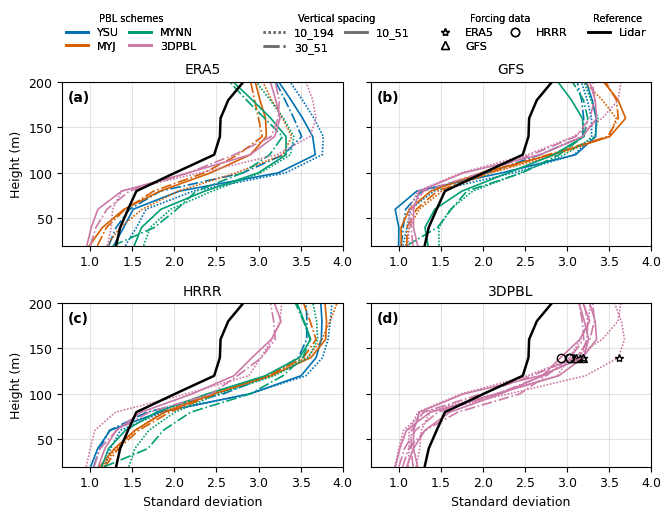

Saved: profiles_sd_ws/E05/sd_ws_2x2_E05.[pdf/png]


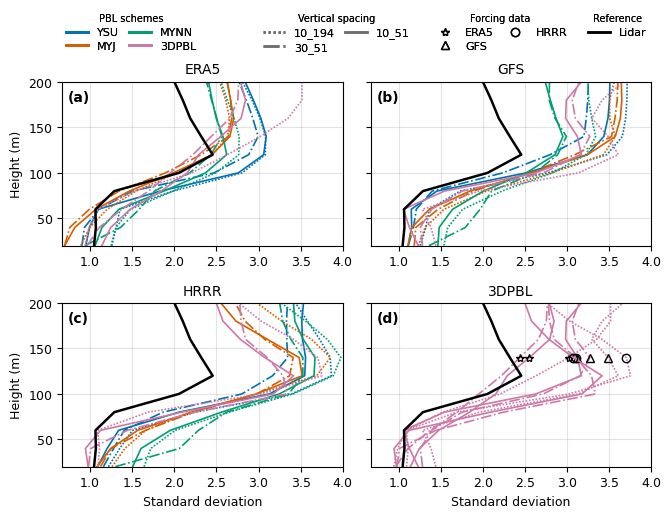

Saved: profiles_sd_ws/E06/sd_ws_2x2_E06.[pdf/png]
Done. Outputs in: profiles_sd_ws/E05 and profiles_sd_ws/E06


In [106]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT       = "errors_sd_ws"           # <-- folder in CURRENT directory
OUT_ROOT         = "profiles_sd_ws"         # <-- output folder

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# observed WS files in CURRENT directory
OBS_FILES = {
    "E05": "WS_E05_OBS.npy",
    "E06": "WS_E06_OBS.npy",
}

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
MARKER_HEIGHT_M = 140

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (6.85, 5.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# --- updated vertical nomenclature ---
vert_to_label = {"54": "10_194", "80": "30_51", "93": "10_51"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}
vert_legend_color = "#6E6E6E"  # gray, not black

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """Parent dir like: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def load_profile(path):
    """
    Accepts:
      - (10,) already a vertical profile
      - (time,10) -> mean over time -> (10,)
    """
    arr = np.load(path)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)
    raise ValueError(f"Unexpected shape {arr.shape} in {path}")

def load_obs_sd_profile(loc):
    """
    Compute observed SD profile from WS_E05_OBS.npy / WS_E06_OBS.npy.
    Expected shape: (time, 10)
    """
    obs_file = OBS_FILES[loc]
    obs_path = os.path.join(os.getcwd(), obs_file)

    if not os.path.isfile(obs_path):
        raise FileNotFoundError(f"Observed file not found: {obs_path}")

    arr = np.load(obs_path)

    if arr.ndim != 2 or arr.shape[1] != 10:
        raise ValueError(f"Expected observed array shape (time,10), got {arr.shape} in {obs_path}")

    obs_sd = np.nanstd(arr, axis=0)
    return obs_sd

def collect_sd_index():
    """
    Looks for SD files under errors_sd_ws recursively.
    Expects filenames like: SD_WS_E05.npy (case-insensitive).
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")

    out = []
    for loc in LOCATIONS:
        patt = os.path.join(root, "**", f"*{loc}*.npy")
        for f in glob.glob(patt, recursive=True):
            base = os.path.basename(f).lower()
            if "sd" not in base:
                continue
            if "_ws_" not in base and "ws" not in base:
                continue

            parsed = parse_parts_from_parent(f)
            if not parsed:
                continue
            icbc, pbl, vert = parsed
            out.append((f, icbc, pbl, vert, loc))

    return out

def compute_global_xlims(idx, obs_sd_dict, pad=0.02):
    """
    Fixed x-axis limits across all comparable SD panels,
    including observed SD profiles.
    """
    vals = []
    for f, icbc, pbl, vert, loc in idx:
        try:
            prof = load_profile(f)
        except Exception:
            continue
        vals.extend(prof.ravel())

    for loc in LOCATIONS:
        if loc in obs_sd_dict:
            vals.extend(np.asarray(obs_sd_dict[loc]).ravel())

    vals = np.asarray(vals, dtype=float)
    xmin = np.nanmin(vals) - pad
    xmax = np.nanmax(vals) + pad
    xmin = np.floor(xmin * 100) / 100
    xmax = np.ceil(xmax * 100) / 100
    return (xmin, xmax)

def panel_label(ax, txt):
    ax.text(
        0.02, 0.95, txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10, fontweight="bold"
    )

def add_grouped_top_legends(fig):
    """
    Top grouped legend blocks (PBL schemes, Vertical spacing, ICBC, Reference).
    """
    title_fs = 7
    label_fs = 8

    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    vert_handles = [
        Line2D([0], [0], color=vert_legend_color, lw=1.8,
               linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ["54", "80", "93"]
    ]

    icbc_handles = [
        Line2D([0], [0], linestyle="None", color="black",
               marker=icbc_marker[i], markersize=6,
               markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
               label=i.upper())
        for i in ["era5", "gfs", "hrrr"]
    ]

    ref_handles = [
        Line2D([0], [0], color="black", lw=1.8, linestyle="-", label="Lidar")
    ]

    leg1 = fig.legend(
        handles=pbl_handles, loc="upper center", bbox_to_anchor=(0.22, 1.02),
        frameon=False, ncol=2, title="PBL schemes",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg2 = fig.legend(
        handles=vert_handles, loc="upper center", bbox_to_anchor=(0.52, 1.02),
        frameon=False, ncol=2, title="Vertical spacing",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg3 = fig.legend(
        handles=icbc_handles, loc="upper center", bbox_to_anchor=(0.76, 1.02),
        frameon=False, ncol=2, title="Forcing data",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )
    leg4 = fig.legend(
        handles=ref_handles, loc="upper center", bbox_to_anchor=(0.93, 1.02),
        frameon=False, ncol=1, title="Reference",
        title_fontsize=title_fs, fontsize=label_fs,
        handlelength=2.0, columnspacing=0.9, labelspacing=0.35, borderaxespad=0.0
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)
    fig.add_artist(leg4)

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# ===================== Panel plotters =====================
def plot_panel_single_icbc(ax, loc, idx, icbc_fixed, xlim, panel_txt, obs_sd):
    """
    Panel for ERA5/GFS/HRRR:
      - lines: all PBLs × vertical levels
      - color=PBL, linestyle=vert
      - black line: observed SD
    """
    items = [(f, icbc, pbl, vert)
             for (f, icbc, pbl, vert, L) in idx
             if L == loc and icbc == icbc_fixed]

    items.sort(key=lambda x: (
        PBL_ORDER.get(x[2], 99),
        VERT_ORDER.get(x[3], 99),
        os.path.basename(os.path.dirname(x[0]))
    ))

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            continue

        ax.plot(
            prof, z,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2
        )

    ax.plot(
        obs_sd, z,
        color="black",
        linestyle="-",
        linewidth=1.8,
        zorder=5
    )

    ax.set_xlim(xlim)
    ax.set_ylim([20, 200])
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"{icbc_fixed.upper()}")
    panel_label(ax, panel_txt)

def plot_panel_3dpbl(ax, loc, idx, xlim, panel_txt, obs_sd):
    """
    Panel for 3DPBL:
      - lines: ICBC × vertical levels
      - color=3dpbl
      - linestyle=vert
      - marker=ICBC at 140 m
      - black line: observed SD
    """
    items = [(f, icbc, pbl, vert)
             for (f, icbc, pbl, vert, L) in idx
             if L == loc and pbl == "3dpbl"]

    items.sort(key=lambda x: (
        ICBC_ORDER.get(x[1], 99),
        VERT_ORDER.get(x[3], 99),
        os.path.basename(os.path.dirname(x[0]))
    ))

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            continue

        ax.plot(
            prof, z,
            color=pbl_color["3dpbl"],
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            marker=icbc_marker.get(icbc, "o"),
            markevery=[MARK_IDX],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
        )

    ax.plot(
        obs_sd, z,
        color="black",
        linestyle="-",
        linewidth=1.8,
        zorder=5
    )

    ax.set_xlim(xlim)
    ax.set_ylim([20, 200])
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title("3DPBL")
    panel_label(ax, panel_txt)

# ===================== 2×2 figure per buoy =====================
def plot_sd_2x2_per_buoy(loc, idx, xlim, obs_sd):
    outdir = ensure_outdir(loc)

    fig, axs = plt.subplots(2, 2, figsize=FIGSIZE, sharey=True)
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.88,
        bottom=0.14,
        wspace=0.1,
        hspace=0.35
    )

    plot_panel_single_icbc(axs[0, 0], loc, idx, "era5", xlim, "(a)", obs_sd)
    plot_panel_single_icbc(axs[0, 1], loc, idx, "gfs",  xlim, "(b)", obs_sd)
    plot_panel_single_icbc(axs[1, 0], loc, idx, "hrrr", xlim, "(c)", obs_sd)
    plot_panel_3dpbl      (axs[1, 1], loc, idx,        xlim, "(d)", obs_sd)

    axs[1, 0].set_xlabel("Standard deviation")
    axs[1, 1].set_xlabel("Standard deviation")
    axs[0, 0].set_ylabel("Height (m)")
    axs[1, 0].set_ylabel("Height (m)")

    add_grouped_top_legends(fig)

    base = f"sd_ws_2x2_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_sd_index()
    print("Indexed SD files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    # observed SD profiles
    obs_sd_dict = {loc: load_obs_sd_profile(loc) for loc in LOCATIONS}
    for loc in LOCATIONS:
        print(f"Observed SD loaded for {loc}: shape {obs_sd_dict[loc].shape}")

    # fixed x-axis limits across the whole comparable batch
    SD_XLIM = compute_global_xlims(idx, obs_sd_dict, pad=0.02)
    print("Using fixed SD x-limits:", SD_XLIM)

    for loc in LOCATIONS:
        plot_sd_2x2_per_buoy(loc, idx, SD_XLIM, obs_sd_dict[loc])

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed SD files: 72
Observed SD loaded for E05: shape (10,)
Observed SD loaded for E06: shape (10,)
Using fixed SD x-limits: (0.0, 4.0)


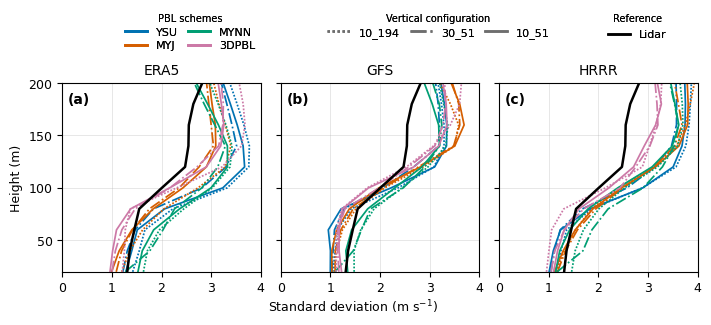

Saved: profiles_sd_ws_3panel/E05/sd_ws_3panel_E05.pdf
Saved: profiles_sd_ws_3panel/E05/sd_ws_3panel_E05.png


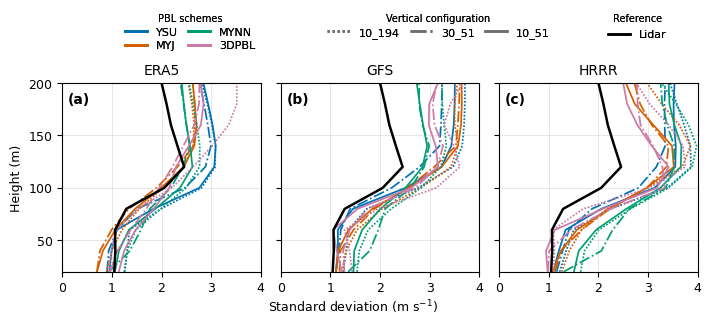

Saved: profiles_sd_ws_3panel/E06/sd_ws_3panel_E06.pdf
Saved: profiles_sd_ws_3panel/E06/sd_ws_3panel_E06.png
Done. Outputs in: profiles_sd_ws_3panel/E05 and profiles_sd_ws_3panel/E06


In [8]:
############### 3 panel SD ###################
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT = "errors_sd_ws"
OUT_ROOT   = "profiles_sd_ws_3panel"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# Observed WS files in CURRENT directory
OBS_FILES = {
    "E05": "WS_E05_OBS.npy",
    "E06": "WS_E06_OBS.npy",
}

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (7.1, 3.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

vert_to_label = {
    "54": "10_194",
    "80": "30_51",
    "93": "10_51",
}

vert_to_ls = {
    "54": (0, (1, 1)),
    "80": "-.",
    "93": "-",
}

vert_legend_color = "#6E6E6E"

PBL_ORDER = {
    "ysu": 0,
    "myj": 1,
    "mynn": 2,
    "3dpbl": 3,
}

VERT_ORDER = {
    "54": 0,
    "80": 1,
    "93": 2,
}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_'
    r'(?P<pbl>ysu|myj|mynn|3dpbl)_'
    r'vert(?P<vert>54|80|93)$'
)


def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir


def parse_parts_from_parent(path):
    """
    Parent directory example:
        era5_ysu_vert80
    """
    run_dir = os.path.basename(os.path.dirname(path))

    m = run_dir_pat.match(run_dir)

    if not m:
        return None

    g = m.groupdict()

    return g["icbc"], g["pbl"], g["vert"]


def load_profile(path):
    """
    Accepts:
      - (10,)       : already a vertical profile
      - (time, 10) : mean over time -> (10,)
    """
    arr = np.load(path)

    if arr.ndim == 1:
        return arr

    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)

    raise ValueError(
        f"Unexpected shape {arr.shape} in {path}"
    )


def load_obs_sd_profile(loc):
    """
    Compute observed temporal SD profile.

    Expected observed array shape:
        (time, 10)

    np.nanstd uses ddof=0, consistent with the SD
    definition used in the Methods.
    """
    obs_file = OBS_FILES[loc]
    obs_path = os.path.join(
        os.getcwd(),
        obs_file
    )

    if not os.path.isfile(obs_path):
        raise FileNotFoundError(
            f"Observed file not found: {obs_path}"
        )

    arr = np.load(obs_path)

    if arr.ndim != 2 or arr.shape[1] != len(z):
        raise ValueError(
            f"Expected observed array shape "
            f"(time,{len(z)}), got {arr.shape} "
            f"in {obs_path}"
        )

    return np.nanstd(
        arr,
        axis=0
    )


def collect_sd_index():
    """
    Recursively searches ERROR_ROOT for SD wind-speed files.

    Expected filenames include:
        SD_WS_E05.npy
    """
    root = os.path.join(
        os.getcwd(),
        ERROR_ROOT
    )

    if not os.path.isdir(root):
        raise FileNotFoundError(
            f"Folder not found: {root}"
        )

    out = []

    for loc in LOCATIONS:

        patt = os.path.join(
            root,
            "**",
            f"*{loc}*.npy"
        )

        for f in glob.glob(
            patt,
            recursive=True
        ):

            base = os.path.basename(f).lower()

            if "sd" not in base:
                continue

            if "_ws_" not in base and "ws" not in base:
                continue

            parsed = parse_parts_from_parent(f)

            if not parsed:
                continue

            icbc, pbl, vert = parsed

            out.append(
                (f, icbc, pbl, vert, loc)
            )

    return out


def compute_global_xlims(idx, obs_sd_dict, pad=0.02):
    """
    Common x-axis limits across:
      - ERA5/GFS/HRRR
      - E05/E06
      - simulated and observed SD profiles

    SD is nonnegative, so the lower limit is fixed at zero.
    """
    vals = []

    for f, icbc, pbl, vert, loc in idx:

        try:
            prof = load_profile(f)
        except Exception:
            continue

        vals.extend(
            prof.ravel()
        )

    for loc in LOCATIONS:
        vals.extend(
            np.asarray(
                obs_sd_dict[loc]
            ).ravel()
        )

    vals = np.asarray(
        vals,
        dtype=float
    )

    xmax = np.nanmax(vals) + pad

    # Round upward to nearest 0.1
    xmax = np.ceil(
        xmax * 10
    ) / 10

    return (0.0, xmax)


def panel_label(ax, txt):

    ax.text(
        0.03,
        0.95,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )


# ===================== Legends =====================
def add_grouped_top_legends(fig):
    """
    Encoding:
      color      = PBL scheme
      linestyle  = vertical configuration
      black line = lidar observations

    Forcing dataset is represented by panel.
    """

    title_fs = 7
    label_fs = 8

    # ---------------- PBL schemes ----------------
    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=p.upper()
        )
        for p in [
            "ysu",
            "myj",
            "mynn",
            "3dpbl"
        ]
    ]

    # ---------------- Vertical configurations ----------------
    vert_handles = [
        Line2D(
            [0], [0],
            color=vert_legend_color,
            lw=1.8,
            linestyle=vert_to_ls[v],
            label=vert_to_label[v]
        )
        for v in [
            "54",
            "80",
            "93"
        ]
    ]

    # ---------------- Observations ----------------
    obs_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=1.8,
            linestyle="-",
            label="Lidar"
        )
    ]

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.27, 1.01),
        frameon=False,
        ncol=2,
        title="PBL schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    leg2 = fig.legend(
        handles=vert_handles,
        loc="upper center",
        bbox_to_anchor=(0.62, 1.01),
        frameon=False,
        ncol=3,
        title="Vertical configuration",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    leg3 = fig.legend(
        handles=obs_handles,
        loc="upper center",
        bbox_to_anchor=(0.90, 1.01),
        frameon=False,
        ncol=1,
        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        borderaxespad=0.0,
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)


# ===================== Panel plotting =====================
def plot_panel_single_icbc(
    ax,
    loc,
    idx,
    icbc_fixed,
    xlim,
    panel_txt,
    obs_sd,
):
    """
    One panel for one forcing dataset.

    Encoding:
      color      = PBL scheme
      linestyle  = vertical configuration
      black line = observed temporal SD
    """

    items = [
        (f, icbc, pbl, vert)
        for (f, icbc, pbl, vert, L) in idx
        if L == loc and icbc == icbc_fixed
    ]

    items.sort(
        key=lambda x: (
            PBL_ORDER.get(x[2], 99),
            VERT_ORDER.get(x[3], 99),
            os.path.basename(
                os.path.dirname(x[0])
            ),
        )
    )

    for f, icbc, pbl, vert in items:

        prof = load_profile(f)

        if prof.shape[0] != len(z):

            print(
                f"Skipping {f}: "
                f"expected {len(z)} heights, "
                f"got {prof.shape[0]}"
            )

            continue

        ax.plot(
            prof,
            z,
            color=pbl_color.get(
                pbl,
                "0.5"
            ),
            linestyle=vert_to_ls.get(
                vert,
                "-"
            ),
            linewidth=1.25,
            zorder=2,
        )

    # Observed SD
    ax.plot(
        obs_sd,
        z,
        color="black",
        linestyle="-",
        linewidth=1.8,
        zorder=5,
    )

    ax.set_xlim(
        xlim
    )

    ax.set_ylim(
        20,
        200
    )

    ax.grid(
        True,
        alpha=0.30,
        linewidth=0.7,
    )

    ax.set_title(
        icbc_fixed.upper()
    )

    panel_label(
        ax,
        panel_txt
    )


# ===================== 1x3 figure per buoy =====================
def plot_sd_3panel_per_buoy(
    loc,
    idx,
    xlim,
    obs_sd,
):

    outdir = ensure_outdir(
        loc
    )

    fig, axs = plt.subplots(
        1,
        3,
        figsize=FIGSIZE,
        sharex=True,
        sharey=True,
    )

    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        top=0.78,
        bottom=0.19,
        wspace=0.10,
    )

    # ERA5
    plot_panel_single_icbc(
        axs[0],
        loc,
        idx,
        "era5",
        xlim,
        "(a)",
        obs_sd,
    )

    # GFS
    plot_panel_single_icbc(
        axs[1],
        loc,
        idx,
        "gfs",
        xlim,
        "(b)",
        obs_sd,
    )

    # HRRR
    plot_panel_single_icbc(
        axs[2],
        loc,
        idx,
        "hrrr",
        xlim,
        "(c)",
        obs_sd,
    )

    # Shared y-axis label
    axs[0].set_ylabel(
        "Height (m)"
    )

    # Shared x-axis label
    fig.supxlabel(
        "Standard deviation (m s$^{-1}$)",
        fontsize=9,
        y=0.055,
    )

    add_grouped_top_legends(
        fig
    )

    base = (
        f"sd_ws_3panel_{loc}"
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(
        f"Saved: {pdf_path}"
    )

    print(
        f"Saved: {png_path}"
    )


# ===================== RUN =====================
if __name__ == "__main__":

    idx = collect_sd_index()

    print(
        "Indexed SD files:",
        len(idx)
    )

    os.makedirs(
        OUT_ROOT,
        exist_ok=True
    )

    # Observed temporal SD profiles
    obs_sd_dict = {
        loc: load_obs_sd_profile(loc)
        for loc in LOCATIONS
    }

    for loc in LOCATIONS:
        print(
            f"Observed SD loaded for {loc}: "
            f"shape {obs_sd_dict[loc].shape}"
        )

    # Fixed x-axis across both locations and all forcing datasets
    SD_XLIM = compute_global_xlims(
        idx,
        obs_sd_dict,
        pad=0.02,
    )

    print(
        "Using fixed SD x-limits:",
        SD_XLIM
    )

    for loc in LOCATIONS:

        plot_sd_3panel_per_buoy(
            loc,
            idx,
            SD_XLIM,
            obs_sd_dict[loc],
        )

    print(
        f"Done. Outputs in: "
        f"{OUT_ROOT}/E05 and "
        f"{OUT_ROOT}/E06"
    )

In [32]:
################## not updated, as error metrics for wd is not being used atm
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT       = "errors_bias_wd"         # <-- folder in CURRENT directory
OUT_ROOT         = "profiles_bias_wd"       # <-- output folder

# file names like this: BIAS_WD_E05.npy
LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

MARKER_HEIGHT_M = 140

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

FIGSIZE = (6.85, 5.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#C2185B",
}

vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """Parent dir like: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def load_profile(path):
    """
    Accepts:
      - (10,) already a vertical profile
      - (time,10) -> mean over time -> (10,)
    """
    arr = np.load(path)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)
    raise ValueError(f"Unexpected shape {arr.shape} in {path}")

def collect_bias_index():
    """
    Looks for bias files under errors_bias_wd recursively.
    Expects filenames like: BIAS_WD_E05.npy (case-insensitive).
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")

    out = []
    for loc in LOCATIONS:
        patt = os.path.join(root, "**", f"*{loc}*.npy")
        for f in glob.glob(patt, recursive=True):
            base = os.path.basename(f).lower()
            if "bias" not in base:
                continue
            if "_wd_" not in base:
                continue

            parsed = parse_parts_from_parent(f)
            if not parsed:
                continue
            icbc, pbl, vert = parsed
            out.append((f, icbc, pbl, vert, loc))

    return out

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# ===================== Plot functions =====================
def plot_bias_single_icbc(loc, idx, icbc_fixed):
    """
    One figure per buoy per ICBC:
      - Bias profile: x=bias, y=height
      - lines: all PBLs × vertical levels (available)
      - color=PBL, linestyle=vert
      - ideal line: x=0 (black)
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
    if not items:
        print(f"[{loc}] No WD bias files for {icbc_fixed}.")
        return

    items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    # Ideal line (bias=0)
    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
            continue

        ax.plot(
            prof, z,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2
        )

    ax.set_ylim([20, 200])
    ax.set_xlabel("Bias (°)")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"Wind Direction bias profiles with {icbc_fixed.upper()} Buoy {loc}", loc="center")

    # Legend (PBL + vert + ideal)
    pbl_handles = [Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper()) for p in PBLS]
    vert_handles = [Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
                    for v in ["54", "80", "93"] if v in vert_to_ls]
    ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

    ax.legend(handles=pbl_handles + vert_handles + ideal_handle,
              loc="upper left", frameon=False, ncol=2,
              handlelength=2.4, columnspacing=1.2, labelspacing=0.5)

    base = f"bias_wd_{icbc_fixed}_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

def plot_bias_3dpbl_all_icbc(loc, idx):
    """
    One figure per buoy for 3DPBL:
      - lines: ICBC × vertical levels (available)
      - color=3dpbl
      - linestyle=vert
      - marker=ICBC (black hollow) fixed at 140 m
      - ideal line: x=0
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
    if not items:
        print(f"[{loc}] No 3DPBL WD bias files.")
        return

    items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
            continue

        ax.plot(
            prof, z,
            color=pbl_color["3dpbl"],
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            marker=icbc_marker.get(icbc, "o"),
            markevery=[MARK_IDX],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
        )

    ax.set_ylim([20, 200])
    ax.set_xlabel("Bias (°)")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"Wind Direction bias profiles with 3DPBL at Buoy {loc}", loc="center")

    icbc_handles = [
        Line2D([0], [0], linestyle="None", color="black",
               marker=icbc_marker[i], markersize=7,
               markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
               label=i.upper())
        for i in ICBCS
    ]
    vert_handles = [Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
                    for v in ["54", "80", "93"] if v in vert_to_ls]
    ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

    ax.legend(handles=icbc_handles + ideal_handle + vert_handles,
              loc="upper left", frameon=False, ncol=2,
              handlelength=2.2, columnspacing=1.2, labelspacing=0.5)

    base = f"bias_wd_3dpbl_allICBC_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_bias_index()
    print("Indexed WD bias files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    for loc in LOCATIONS:
        plot_bias_single_icbc(loc, idx, "era5")
        plot_bias_single_icbc(loc, idx, "gfs")
        plot_bias_single_icbc(loc, idx, "hrrr")
        plot_bias_3dpbl_all_icbc(loc, idx)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed WD bias files: 72
Saved: profiles_bias_wd/E05/bias_wd_era5_E05.[pdf/png]
Saved: profiles_bias_wd/E05/bias_wd_gfs_E05.[pdf/png]
Saved: profiles_bias_wd/E05/bias_wd_hrrr_E05.[pdf/png]
Saved: profiles_bias_wd/E05/bias_wd_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_bias_wd/E06/bias_wd_era5_E06.[pdf/png]
Saved: profiles_bias_wd/E06/bias_wd_gfs_E06.[pdf/png]
Saved: profiles_bias_wd/E06/bias_wd_hrrr_E06.[pdf/png]
Saved: profiles_bias_wd/E06/bias_wd_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_bias_wd/E05 and profiles_bias_wd/E06


In [33]:
################## not updated, as error metrics for wd is not being used atm
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT       = "errors_crmse_wd"        # <-- folder in CURRENT directory
OUT_ROOT         = "profiles_crmse_wd"      # <-- output folder

# file names like this: CRMSE_WD_E05.npy
LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
MARKER_HEIGHT_M = 140

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

FIGSIZE = (6.85, 5.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#C2185B",
}

vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """Parent dir like: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def load_profile(path):
    """
    Accepts:
      - (10,) already a vertical profile
      - (time,10) -> mean over time -> (10,)
    """
    arr = np.load(path)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)
    raise ValueError(f"Unexpected shape {arr.shape} in {path}")

def collect_crmse_index():
    """
    Looks for cRMSE files under errors_crmse_wd recursively.
    Expects filenames like: CRMSE_WD_E05.npy (case-insensitive).
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")

    out = []
    for loc in LOCATIONS:
        patt = os.path.join(root, "**", f"*{loc}*.npy")
        for f in glob.glob(patt, recursive=True):
            base = os.path.basename(f).lower()
            if "crmse" not in base:
                continue
            if "_wd_" not in base:
                continue

            parsed = parse_parts_from_parent(f)
            if not parsed:
                continue
            icbc, pbl, vert = parsed
            out.append((f, icbc, pbl, vert, loc))
    return out

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# ===================== Plot functions =====================
def plot_crmse_single_icbc(loc, idx, icbc_fixed):
    """
    One figure per buoy per ICBC:
      - cRMSE profile: x=cRMSE, y=height
      - lines: all PBLs × vertical levels (available)
      - color=PBL, linestyle=vert
      - ideal line: x=0 (black)
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
    if not items:
        print(f"[{loc}] No WD cRMSE files for {icbc_fixed}.")
        return

    items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    # Ideal line (cRMSE=0)
    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
            continue

        ax.plot(
            prof, z,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2
        )

    ax.set_ylim([20, 200])
    ax.set_xlabel("cRMSE (°)")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"Wind Direction cRMSE profiles with {icbc_fixed.upper()} Buoy {loc}", loc="center")

    pbl_handles  = [Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper()) for p in PBLS]
    vert_handles = [Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
                    for v in ["54", "80", "93"] if v in vert_to_ls]
    ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

    ax.legend(handles=pbl_handles + vert_handles + ideal_handle,
              loc="upper left", frameon=False, ncol=2,
              handlelength=2.4, columnspacing=1.2, labelspacing=0.5)

    base = f"crmse_wd_{icbc_fixed}_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

def plot_crmse_3dpbl_all_icbc(loc, idx):
    """
    One figure per buoy for 3DPBL:
      - lines: ICBC × vertical levels (available)
      - color=3dpbl
      - linestyle=vert
      - marker=ICBC (black hollow) fixed at 140 m
      - ideal line: x=0
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
    if not items:
        print(f"[{loc}] No 3DPBL WD cRMSE files.")
        return

    items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
            continue

        ax.plot(
            prof, z,
            color=pbl_color["3dpbl"],
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            marker=icbc_marker.get(icbc, "o"),
            markevery=[MARK_IDX],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
        )

    ax.set_ylim([20, 200])
    ax.set_xlabel("cRMSE (°)")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"Wind Direction cRMSE profiles with 3DPBL at Buoy {loc}", loc="center")

    icbc_handles = [
        Line2D([0], [0], linestyle="None", color="black",
               marker=icbc_marker[i], markersize=7,
               markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
               label=i.upper())
        for i in ICBCS
    ]
    vert_handles = [Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
                    for v in ["54", "80", "93"] if v in vert_to_ls]
    ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

    ax.legend(handles=icbc_handles + ideal_handle + vert_handles,
              loc="upper left", frameon=False, ncol=2,
              handlelength=2.2, columnspacing=1.2, labelspacing=0.5)

    base = f"crmse_wd_3dpbl_allICBC_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_crmse_index()
    print("Indexed WD cRMSE files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    for loc in LOCATIONS:
        plot_crmse_single_icbc(loc, idx, "era5")
        plot_crmse_single_icbc(loc, idx, "gfs")
        plot_crmse_single_icbc(loc, idx, "hrrr")
        plot_crmse_3dpbl_all_icbc(loc, idx)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed WD cRMSE files: 72
Saved: profiles_crmse_wd/E05/crmse_wd_era5_E05.[pdf/png]
Saved: profiles_crmse_wd/E05/crmse_wd_gfs_E05.[pdf/png]
Saved: profiles_crmse_wd/E05/crmse_wd_hrrr_E05.[pdf/png]
Saved: profiles_crmse_wd/E05/crmse_wd_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_crmse_wd/E06/crmse_wd_era5_E06.[pdf/png]
Saved: profiles_crmse_wd/E06/crmse_wd_gfs_E06.[pdf/png]
Saved: profiles_crmse_wd/E06/crmse_wd_hrrr_E06.[pdf/png]
Saved: profiles_crmse_wd/E06/crmse_wd_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_crmse_wd/E05 and profiles_crmse_wd/E06


In [34]:
################## not updated, as error metrics for wd is not being used atm
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT       = "errors_r2_wd"           # <-- folder in CURRENT directory
OUT_ROOT         = "profiles_r2_wd"         # <-- output folder

# file names like this: R2_WD_E05.npy
LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
MARKER_HEIGHT_M = 140

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

FIGSIZE = (6.85, 5.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#C2185B",
}

vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """Parent dir like: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def load_profile(path):
    """
    Accepts:
      - (10,) already a vertical profile
      - (time,10) -> mean over time -> (10,)
    """
    arr = np.load(path)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)
    raise ValueError(f"Unexpected shape {arr.shape} in {path}")

def collect_r2_index():
    """
    Looks for R2 files under errors_r2_wd recursively.
    Expects filenames like: R2_WD_E05.npy (case-insensitive).
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")

    out = []
    for loc in LOCATIONS:
        patt = os.path.join(root, "**", f"*{loc}*.npy")
        for f in glob.glob(patt, recursive=True):
            base = os.path.basename(f).lower()
            if "r2" not in base:
                continue
            if "_wd_" not in base:
                continue

            parsed = parse_parts_from_parent(f)
            if not parsed:
                continue
            icbc, pbl, vert = parsed
            out.append((f, icbc, pbl, vert, loc))
    return out

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# ===================== Plot functions =====================
def plot_r2_single_icbc(loc, idx, icbc_fixed):
    """
    One figure per buoy per ICBC:
      - R^2 profile: x=R^2, y=height
      - lines: all PBLs × vertical levels (available)
      - color=PBL, linestyle=vert
      - ideal line: x=1 (black)
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
    if not items:
        print(f"[{loc}] No WD R2 files for {icbc_fixed}.")
        return

    items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    ax.axvline(1.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
            continue

        ax.plot(
            prof, z,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2
        )

    ax.set_ylim([20, 200])
    ax.set_xlabel("R$^2$")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"Wind Direction R$^2$ profiles with {icbc_fixed.upper()} Buoy {loc}", loc="center")

    pbl_handles  = [Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper()) for p in PBLS]
    vert_handles = [Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
                    for v in ["54", "80", "93"] if v in vert_to_ls]
    ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (1)")]

    ax.legend(handles=pbl_handles + vert_handles + ideal_handle,
              loc="lower left", frameon=False, ncol=2,
              handlelength=2.4, columnspacing=1.2, labelspacing=0.5)

    base = f"r2_wd_{icbc_fixed}_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

def plot_r2_3dpbl_all_icbc(loc, idx):
    """
    One figure per buoy for 3DPBL:
      - lines: ICBC × vertical levels (available)
      - color=3dpbl
      - linestyle=vert
      - marker=ICBC (black hollow) fixed at 140 m
      - ideal line: x=1
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
    if not items:
        print(f"[{loc}] No 3DPBL WD R2 files.")
        return

    items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    ax.axvline(1.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
            continue

        ax.plot(
            prof, z,
            color=pbl_color["3dpbl"],
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            marker=icbc_marker.get(icbc, "o"),
            markevery=[MARK_IDX],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
        )

    ax.set_ylim([20, 200])
    ax.set_xlabel("R$^2$")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"Wind Direction R$^2$ profiles with 3DPBL at Buoy {loc}", loc="center")

    icbc_handles = [
        Line2D([0], [0], linestyle="None", color="black",
               marker=icbc_marker[i], markersize=7,
               markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
               label=i.upper())
        for i in ICBCS
    ]
    vert_handles = [Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
                    for v in ["54", "80", "93"] if v in vert_to_ls]
    ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (1)")]

    ax.legend(handles=icbc_handles + ideal_handle + vert_handles,
              loc="lower left", frameon=False, ncol=2,
              handlelength=2.2, columnspacing=1.2, labelspacing=0.5)

    base = f"r2_wd_3dpbl_allICBC_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_r2_index()
    print("Indexed WD R2 files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    for loc in LOCATIONS:
        plot_r2_single_icbc(loc, idx, "era5")
        plot_r2_single_icbc(loc, idx, "gfs")
        plot_r2_single_icbc(loc, idx, "hrrr")
        plot_r2_3dpbl_all_icbc(loc, idx)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed WD R2 files: 72
Saved: profiles_r2_wd/E05/r2_wd_era5_E05.[pdf/png]
Saved: profiles_r2_wd/E05/r2_wd_gfs_E05.[pdf/png]
Saved: profiles_r2_wd/E05/r2_wd_hrrr_E05.[pdf/png]
Saved: profiles_r2_wd/E05/r2_wd_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_r2_wd/E06/r2_wd_era5_E06.[pdf/png]
Saved: profiles_r2_wd/E06/r2_wd_gfs_E06.[pdf/png]
Saved: profiles_r2_wd/E06/r2_wd_hrrr_E06.[pdf/png]
Saved: profiles_r2_wd/E06/r2_wd_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_r2_wd/E05 and profiles_r2_wd/E06


In [35]:
################## not updated, as error metrics for wd is not being used atm
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT       = "errors_emd_wd"          # <-- folder in CURRENT directory
OUT_ROOT         = "profiles_emd_wd"        # <-- output folder

# file names like this: EMD_WD_E05.npy
LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
MARKER_HEIGHT_M = 140

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

FIGSIZE = (6.85, 5.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#C2185B",
}

vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """Parent dir like: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def load_profile(path):
    """
    Accepts:
      - (10,) already a vertical profile
      - (time,10) -> mean over time -> (10,)
    """
    arr = np.load(path)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)
    raise ValueError(f"Unexpected shape {arr.shape} in {path}")

def collect_emd_index():
    """
    Looks for EMD files under errors_emd_wd recursively.
    Expects filenames like: EMD_WD_E05.npy (case-insensitive).
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")

    out = []
    for loc in LOCATIONS:
        patt = os.path.join(root, "**", f"*{loc}*.npy")
        for f in glob.glob(patt, recursive=True):
            base = os.path.basename(f).lower()
            if "emd" not in base:
                continue
            if "_wd_" not in base:
                continue

            parsed = parse_parts_from_parent(f)
            if not parsed:
                continue
            icbc, pbl, vert = parsed
            out.append((f, icbc, pbl, vert, loc))
    return out

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# ===================== Plot functions =====================
def plot_emd_single_icbc(loc, idx, icbc_fixed):
    """
    One figure per buoy per ICBC:
      - EMD profile: x=EMD, y=height
      - lines: all PBLs × vertical levels (available)
      - color=PBL, linestyle=vert
      - ideal line: x=0 (black)
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
    if not items:
        print(f"[{loc}] No WD EMD files for {icbc_fixed}.")
        return

    items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
            continue

        ax.plot(
            prof, z,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2
        )

    ax.set_ylim([20, 200])
    ax.set_xlabel("EMD")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"Wind Direction EMD profiles with {icbc_fixed.upper()} Buoy {loc}", loc="center")

    pbl_handles  = [Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper()) for p in PBLS]
    vert_handles = [Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
                    for v in ["54", "80", "93"] if v in vert_to_ls]
    ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

    ax.legend(handles=pbl_handles + vert_handles + ideal_handle,
              loc="upper left", frameon=False, ncol=2,
              handlelength=2.4, columnspacing=1.2, labelspacing=0.5)

    base = f"emd_wd_{icbc_fixed}_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

def plot_emd_3dpbl_all_icbc(loc, idx):
    """
    One figure per buoy for 3DPBL:
      - lines: ICBC × vertical levels (available)
      - color=3dpbl
      - linestyle=vert
      - marker=ICBC (black hollow) fixed at 140 m
      - ideal line: x=0
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
    if not items:
        print(f"[{loc}] No 3DPBL WD EMD files.")
        return

    items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
            continue

        ax.plot(
            prof, z,
            color=pbl_color["3dpbl"],
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            marker=icbc_marker.get(icbc, "o"),
            markevery=[MARK_IDX],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
        )

    ax.set_ylim([20, 200])
    ax.set_xlabel("EMD")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"Wind Direction EMD profiles with 3DPBL at Buoy {loc}", loc="center")

    icbc_handles = [
        Line2D([0], [0], linestyle="None", color="black",
               marker=icbc_marker[i], markersize=7,
               markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
               label=i.upper())
        for i in ICBCS
    ]
    vert_handles = [Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
                    for v in ["54", "80", "93"] if v in vert_to_ls]
    ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

    ax.legend(handles=icbc_handles + ideal_handle + vert_handles,
              loc="upper left", frameon=False, ncol=2,
              handlelength=2.2, columnspacing=1.2, labelspacing=0.5)

    base = f"emd_wd_3dpbl_allICBC_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_emd_index()
    print("Indexed WD EMD files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    for loc in LOCATIONS:
        plot_emd_single_icbc(loc, idx, "era5")
        plot_emd_single_icbc(loc, idx, "gfs")
        plot_emd_single_icbc(loc, idx, "hrrr")
        plot_emd_3dpbl_all_icbc(loc, idx)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed WD EMD files: 72
Saved: profiles_emd_wd/E05/emd_wd_era5_E05.[pdf/png]
Saved: profiles_emd_wd/E05/emd_wd_gfs_E05.[pdf/png]
Saved: profiles_emd_wd/E05/emd_wd_hrrr_E05.[pdf/png]
Saved: profiles_emd_wd/E05/emd_wd_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_emd_wd/E06/emd_wd_era5_E06.[pdf/png]
Saved: profiles_emd_wd/E06/emd_wd_gfs_E06.[pdf/png]
Saved: profiles_emd_wd/E06/emd_wd_hrrr_E06.[pdf/png]
Saved: profiles_emd_wd/E06/emd_wd_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_emd_wd/E05 and profiles_emd_wd/E06


In [36]:
################## not updated, as error metrics for wd is not being used atm
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
ERROR_ROOT       = "errors_sd_wd"           # <-- folder in CURRENT directory
OUT_ROOT         = "profiles_sd_wd"         # <-- output folder

# file names like this: SD_WD_E05.npy
LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
MARKER_HEIGHT_M = 140

# ===================== Styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

FIGSIZE = (6.85, 5.2)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#C2185B",
}

vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # black, hollow

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ===================== Helpers =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def parse_parts_from_parent(path):
    """Parent dir like: era5_ysu_vert80"""
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def load_profile(path):
    """
    Accepts:
      - (10,) already a vertical profile
      - (time,10) -> mean over time -> (10,)
    """
    arr = np.load(path)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 10:
        return np.nanmean(arr, axis=0)
    raise ValueError(f"Unexpected shape {arr.shape} in {path}")

def collect_sd_index():
    """
    Looks for SD files under errors_sd_wd recursively.
    Expects filenames like: SD_WD_E05.npy (case-insensitive).
    """
    root = os.path.join(os.getcwd(), ERROR_ROOT)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")

    out = []
    for loc in LOCATIONS:
        patt = os.path.join(root, "**", f"*{loc}*.npy")
        for f in glob.glob(patt, recursive=True):
            base = os.path.basename(f).lower()
            if "sd" not in base:
                continue
            if "_wd_" not in base:
                continue

            parsed = parse_parts_from_parent(f)
            if not parsed:
                continue
            icbc, pbl, vert = parsed
            out.append((f, icbc, pbl, vert, loc))
    return out

# fixed marker index at 140 m
if MARKER_HEIGHT_M not in z:
    raise ValueError(f"MARKER_HEIGHT_M={MARKER_HEIGHT_M} not in heights={z.tolist()}")
MARK_IDX = int(np.where(z == MARKER_HEIGHT_M)[0][0])

# ===================== Plot functions =====================
def plot_sd_single_icbc(loc, idx, icbc_fixed):
    """
    One figure per buoy per ICBC:
      - SD profile: x=SD, y=height
      - lines: all PBLs × vertical levels (available)
      - color=PBL, linestyle=vert
      - ideal line: x=0 (black)
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
    if not items:
        print(f"[{loc}] No WD SD files for {icbc_fixed}.")
        return

    items.sort(key=lambda x: (PBL_ORDER.get(x[2], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
            continue

        ax.plot(
            prof, z,
            color=pbl_color.get(pbl, "0.5"),
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2
        )

    ax.set_ylim([20, 200])
    ax.set_xlabel("SD")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"Wind Direction SD profiles with {icbc_fixed.upper()} Buoy {loc}", loc="center")

    pbl_handles  = [Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper()) for p in PBLS]
    vert_handles = [Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
                    for v in ["54", "80", "93"] if v in vert_to_ls]
    ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

    ax.legend(handles=pbl_handles + vert_handles + ideal_handle,
              loc="upper left", frameon=False, ncol=2,
              handlelength=2.4, columnspacing=1.2, labelspacing=0.5)

    base = f"sd_wd_{icbc_fixed}_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

def plot_sd_3dpbl_all_icbc(loc, idx):
    """
    One figure per buoy for 3DPBL:
      - lines: ICBC × vertical levels (available)
      - color=3dpbl
      - linestyle=vert
      - marker=ICBC (black hollow) fixed at 140 m
      - ideal line: x=0
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
    if not items:
        print(f"[{loc}] No 3DPBL WD SD files.")
        return

    items.sort(key=lambda x: (ICBC_ORDER.get(x[1], 99), VERT_ORDER.get(x[3], 99), os.path.basename(os.path.dirname(x[0]))))

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    ax.axvline(0.0, color="black", linewidth=1.2)

    for f, icbc, pbl, vert in items:
        prof = load_profile(f)
        if prof.shape[0] != 10:
            print(f"Skipping {f}: expected 10 heights, got {prof.shape}")
            continue

        ax.plot(
            prof, z,
            color=pbl_color["3dpbl"],
            linestyle=vert_to_ls.get(vert, "-"),
            linewidth=1.2,
            marker=icbc_marker.get(icbc, "o"),
            markevery=[MARK_IDX],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
        )

    ax.set_ylim([20, 200])
    ax.set_xlabel("SD")
    ax.set_ylabel("Height (m)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.set_title(f"Wind Direction SD profiles with 3DPBL at Buoy {loc}", loc="center")

    icbc_handles = [
        Line2D([0], [0], linestyle="None", color="black",
               marker=icbc_marker[i], markersize=7,
               markeredgecolor="black", markerfacecolor="none", markeredgewidth=1.0,
               label=i.upper())
        for i in ICBCS
    ]
    vert_handles = [Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
                    for v in ["54", "80", "93"] if v in vert_to_ls]
    ideal_handle = [Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ideal (0)")]

    ax.legend(handles=icbc_handles + ideal_handle + vert_handles,
              loc="upper left", frameon=False, ncol=2,
              handlelength=2.2, columnspacing=1.2, labelspacing=0.5)

    base = f"sd_wd_3dpbl_allICBC_{loc}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_sd_index()
    print("Indexed WD SD files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    for loc in LOCATIONS:
        plot_sd_single_icbc(loc, idx, "era5")
        plot_sd_single_icbc(loc, idx, "gfs")
        plot_sd_single_icbc(loc, idx, "hrrr")
        plot_sd_3dpbl_all_icbc(loc, idx)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Indexed WD SD files: 72
Saved: profiles_sd_wd/E05/sd_wd_era5_E05.[pdf/png]
Saved: profiles_sd_wd/E05/sd_wd_gfs_E05.[pdf/png]
Saved: profiles_sd_wd/E05/sd_wd_hrrr_E05.[pdf/png]
Saved: profiles_sd_wd/E05/sd_wd_3dpbl_allICBC_E05.[pdf/png]
Saved: profiles_sd_wd/E06/sd_wd_era5_E06.[pdf/png]
Saved: profiles_sd_wd/E06/sd_wd_gfs_E06.[pdf/png]
Saved: profiles_sd_wd/E06/sd_wd_hrrr_E06.[pdf/png]
Saved: profiles_sd_wd/E06/sd_wd_3dpbl_allICBC_E06.[pdf/png]
Done. Outputs in: profiles_sd_wd/E05 and profiles_sd_wd/E06


Saved: obs_hourly_profiles_ws/obs_hourly_profiles_ws_E05_E06_panel.pdf
Saved: obs_hourly_profiles_ws/obs_hourly_profiles_ws_E05_E06_panel.png


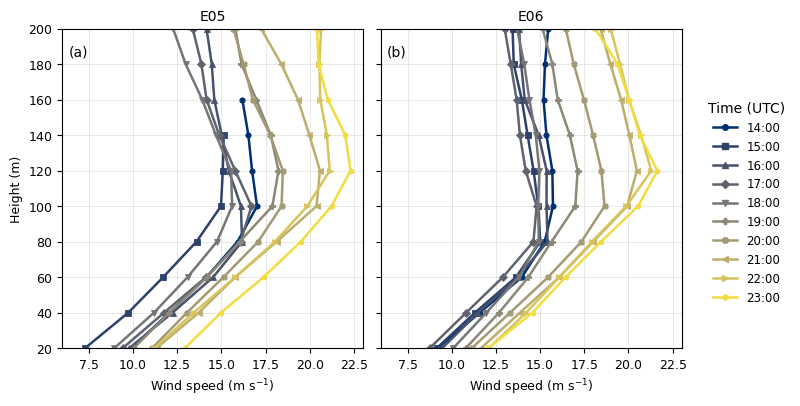

In [1]:
###################### OBS WS Profiles at every hour ##################################
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
CWD = os.getcwd()

z_OBS = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# Load OBS
WS_E05_OBS = np.load(os.path.join(CWD, "WS_E05_OBS.npy"))
WS_E06_OBS = np.load(os.path.join(CWD, "WS_E06_OBS.npy"))

# Time settings
START_TIME = datetime(2020, 5, 15, 14, 0, 0)
STEP_MIN = 10

OUTDIR = "obs_hourly_profiles_ws"
os.makedirs(OUTDIR, exist_ok=True)

# ===================== STYLING =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
})

FIGSIZE = (6.85, 3.95)
DPI = 300

# ===================== HELPERS =====================
def make_time_index(n, start_dt=START_TIME, step_min=STEP_MIN):
    return [start_dt + timedelta(minutes=i * step_min) for i in range(n)]

def get_hourly_indices(times):
    return [i for i, t in enumerate(times) if t.minute == 0]

def compute_fixed_xlim(*arrays, pad=0.5, round_to=1.0):
    """
    Compute a shared x-axis range across multiple comparable arrays.
    """
    xmin = min(np.nanmin(a) for a in arrays)
    xmax = max(np.nanmax(a) for a in arrays)

    xmin = np.floor((xmin - pad) / round_to) * round_to
    xmax = np.ceil((xmax + pad) / round_to) * round_to

    return xmin, xmax

# ===================== MAIN =====================
times = make_time_index(WS_E05_OBS.shape[0])
hourly_idx = get_hourly_indices(times)

# ------------------------------------------------------------------
# Gradual, color-blind-friendly colors
# Avoid very darkest/lightest ends of cividis
# ------------------------------------------------------------------
cmap = plt.get_cmap("cividis")
color_positions = np.linspace(0.08, 0.95, len(hourly_idx))
colors = [cmap(x) for x in color_positions]

# Optional: different marker styles to provide another visual cue
# Useful if the figure is printed in grayscale
marker_styles = [
    "o", "s", "^", "D", "v",
    "P", "X", "<", ">", "h"
]

# ---- fixed x-axis across both panels ----
xlim_min, xlim_max = compute_fixed_xlim(
    WS_E05_OBS,
    WS_E06_OBS,
    pad=0.5,
    round_to=1.0
)

fig, axs = plt.subplots(
    1, 2,
    figsize=FIGSIZE,
    constrained_layout=True,
    sharey=True
)

for ax, ws_obs, loc, panel in zip(
    axs,
    [WS_E05_OBS, WS_E06_OBS],
    ["E05", "E06"],
    ["(a)", "(b)"]
):
    for c, marker, idx in zip(colors, marker_styles, hourly_idx):
        ax.plot(
            ws_obs[idx, :],
            z_OBS,
            color=c,
            lw=1.8,
            marker=marker,
            ms=3.8,
            markeredgewidth=0.6,
        )

    ax.set_xlabel("Wind speed (m s$^{-1}$)")
    ax.set_xlim(xlim_min, xlim_max)

    ax.set_yticks(z_OBS)
    ax.set_ylim(z_OBS.min(), z_OBS.max())

    ax.grid(
        True,
        alpha=0.30,
        linewidth=0.7
    )

    ax.text(
        0.02, 0.95,
        panel,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10
    )

    ax.set_title(loc)

axs[0].set_ylabel("Height (m)")

# ===================== SHARED LEGEND =====================
handles = [
    Line2D(
        [0], [0],
        color=c,
        lw=1.8,
        marker=marker,
        ms=4,
        label=times[idx].strftime("%H:%M")
    )
    for c, marker, idx in zip(colors, marker_styles, hourly_idx)
]

fig.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    ncol=1,
    frameon=False,
    title="Time (UTC)"
)

# ===================== SAVE =====================
pdf_path = os.path.join(
    OUTDIR,
    "obs_hourly_profiles_ws_E05_E06_panel.pdf"
)

png_path = os.path.join(
    OUTDIR,
    "obs_hourly_profiles_ws_E05_E06_panel.png"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight"
)

print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

plt.show()

Saved: obs_hourly_profiles_wd/obs_hourly_profiles_wd_E05_E06_panel.pdf
Saved: obs_hourly_profiles_wd/obs_hourly_profiles_wd_E05_E06_panel.png


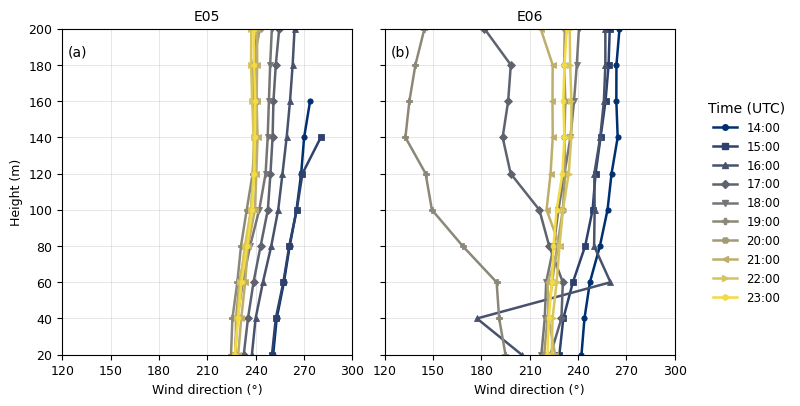

In [2]:
###################### OBS WD Profiles at every hour ##################################
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
CWD = os.getcwd()

z_OBS = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# Load OBS
WD_E05_OBS = np.load(os.path.join(CWD, "WD_E05_OBS.npy"))
WD_E06_OBS = np.load(os.path.join(CWD, "WD_E06_OBS.npy"))

# Time settings
START_TIME = datetime(2020, 5, 15, 14, 0, 0)
STEP_MIN = 10

OUTDIR = "obs_hourly_profiles_wd"
os.makedirs(OUTDIR, exist_ok=True)

# ===================== STYLING =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
})

FIGSIZE = (6.85, 3.95)
DPI = 300

# ===================== HELPERS =====================
def make_time_index(n, start_dt=START_TIME, step_min=STEP_MIN):
    return [start_dt + timedelta(minutes=i * step_min) for i in range(n)]

def get_hourly_indices(times):
    return [i for i, t in enumerate(times) if t.minute == 0]

def wrap_wd_360(arr):
    return np.mod(arr, 360.0)

# ===================== MAIN =====================
WD_E05_OBS = wrap_wd_360(WD_E05_OBS)
WD_E06_OBS = wrap_wd_360(WD_E06_OBS)

times = make_time_index(WD_E05_OBS.shape[0])
hourly_idx = get_hourly_indices(times)

# ---- Same gradual, color-blind-friendly palette as WS profiles ----
cmap = plt.get_cmap("cividis")
color_positions = np.linspace(0.08, 0.95, len(hourly_idx))
colors = [cmap(x) for x in color_positions]

# ---- Same distinct markers as WS profiles ----
marker_styles = [
    "o", "s", "^", "D", "v",
    "P", "X", "<", ">", "h"
]

# ---- fixed x-axis across both panels ----
xlim_min, xlim_max = 120, 300

fig, axs = plt.subplots(
    1, 2,
    figsize=FIGSIZE,
    constrained_layout=True,
    sharey=True
)

for ax, wd_obs, loc, panel in zip(
    axs,
    [WD_E05_OBS, WD_E06_OBS],
    ["E05", "E06"],
    ["(a)", "(b)"]
):
    for c, marker, idx in zip(colors, marker_styles, hourly_idx):
        ax.plot(
            wd_obs[idx, :],
            z_OBS,
            color=c,
            lw=1.8,
            marker=marker,
            ms=3.8,
            markeredgewidth=0.6,
        )

    ax.set_xlabel("Wind direction (°)")
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_xticks(np.arange(120, 301, 30))
    ax.set_yticks(z_OBS)
    ax.set_ylim(z_OBS.min(), z_OBS.max())

    ax.grid(
        True,
        alpha=0.30,
        linewidth=0.7
    )

    ax.text(
        0.02, 0.95, panel,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10
    )

    ax.set_title(loc)

axs[0].set_ylabel("Height (m)")

# ===================== SHARED LEGEND =====================
handles = [
    Line2D(
        [0], [0],
        color=c,
        lw=1.8,
        marker=marker,
        ms=4,
        label=times[idx].strftime("%H:%M")
    )
    for c, marker, idx in zip(colors, marker_styles, hourly_idx)
]

fig.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    ncol=1,
    frameon=False,
    title="Time (UTC)"
)

# ===================== SAVE =====================
pdf_path = os.path.join(
    OUTDIR,
    "obs_hourly_profiles_wd_E05_E06_panel.pdf"
)

png_path = os.path.join(
    OUTDIR,
    "obs_hourly_profiles_wd_E05_E06_panel.png"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight"
)

print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

plt.show()